# QSR Location Health Index: Full Analytical Pipeline

**Sharath Sista | VP Analytics Employer Project, LSE Data Analytics Career Accelerator**

> **Guiding principle:** the LHI is not "proven" by a model. The model is one piece of evidence used to test
> whether the LHI is sensible, stable, and useful. Feature importance answers *"which variables predict this
> target?"*, not *"how much should this variable count toward location health?"* Those are different
> questions, and this notebook doesn't mix them up.

**This is the complete, runnable script, not a summary of one.** Every stage's actual computation code sits
below as a real executable cell: sentence-splitting and VADER scoring for ABSA, the haversine peer-group
search, the bootstrap confidence intervals behind every trajectory label, the leakage audit, the model
training, the LHI weight synthesis, the robustness grid. All of it runs when you run this notebook, not just
narrated from a CSV someone else produced elsewhere. The heavy stages (the 11GB review extraction, ABSA over
1.16M reviews, full-population SHAP) are noted with their approximate runtime, and the notebook still
recomputes them for real if you run it end to end.

**Why the methodology is built this way.** Before committing to a scoring formula, we ran a systematic leakage
audit on every candidate feature (Section 7). The question we tested, rather than assumed, was whether a
variable predicts `IS_OPEN` because it reflects genuine location health, or simply because of how the dataset
itself was built. Twelve-month review, check-in, and tip activity failed that test. Verified directly against
the data: 92.7% of closed businesses have zero reviews in the trailing 12 months, against 12.8% of open ones
(median days since last review: 1,572 vs 73, measured against one fixed dataset cutoff of 2022-01-19 for every
business). A closed business simply stops generating recent activity. Feeding that into a model that predicts
open or closed status doesn't validate a health index, it just teaches the model to recognise its own label.
We excluded every feature in that category before any predictive modelling, and every pillar weight, every LHI
candidate, and every robustness check from that point on is built on the leakage-audited feature set.


In [1]:
import sys
sys.path.insert(0, 'analysis')
import pandas as pd
import numpy as np
from IPython.display import Image, display
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
OUT = 'analysis/output'
FIG = 'analysis/figures'

## 0. Shared Utilities (`analysis/lib/`)

Three small local modules, imported (not copy-pasted) by every stage below through `sys.path.insert(0, 'analysis')`
in the Setup cell above. Their full source is printed here for review. The modules themselves live alongside
this notebook as ordinary `.py` files, so they're testable and reusable on their own, independently of the
notebook.

- **`lib/common.py`**: paths, fail-loud assertions, percentile and shrinkage math, bootstrap confidence intervals, plot theme
- **`lib/peer.py`**: the adaptive peer-group search (10 miles, then city, then state, then global segment), grid-accelerated with haversine distance
- **`lib/absa.py`**: the 7-aspect keyword taxonomy plus VADER domain-lexicon sentiment scorer (Order Accuracy was added and evidence-validated in Section 4, alongside the original six aspects)

In [2]:
from pathlib import Path
print(Path('analysis/lib/common.py').read_text())

"""Shared helpers for the QSR LHI pipeline: paths, fail-loud assertions,
percentile/shrinkage utilities, bootstrap CIs, and a consistent plot theme.
"""
from __future__ import annotations

import sys
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
ROOT = Path(__file__).resolve().parents[2]
ANALYSIS_DIR = ROOT / "analysis"
OUTPUT_DIR = ANALYSIS_DIR / "output"
FIGURES_DIR = ANALYSIS_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PIPELINE_RUN_DATE = datetime.now(timezone.utc).strftime("%Y-%m-%d")
MODEL_VERSION = "qsr-lhi-pipeline-v1"

# Fixed dataset cutoff shared by every row in the source export (verified
# during EDA: DATASET_MAX_REVIEW_TS has exactly one distinct value).
DATASET_CUTOFF = pd.Timestamp("202

In [3]:
print(Path('analysis/lib/peer.py').read_text())

"""Adaptive peer-group construction: local 10-mile radius -> city -> state ->
global segment fallback, with the focal business always excluded from its own
peer set (leave-one-out). Recomputed locally (grid-accelerated haversine)
rather than reusing only the aggregate Snowflake peer stats, because building
per-aspect CX priors needs the actual peer *membership*, not just summary
percentiles.
"""
from __future__ import annotations

import numpy as np
import pandas as pd

EARTH_RADIUS_MI = 3958.8
LOCAL_RADIUS_MI = 10.0
MIN_LOCAL_PEERS = 3


def _haversine_mi(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_MI * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def build_local_peer_index(open_biz: pd.DataFrame, cell_deg: float = 0.2) -> dict:
    """Grid-bucket open businesses by (segment, lat_cell

In [4]:
print(Path('analysis/lib/absa.py').read_text())

"""Lightweight, transparent heuristic ABSA (aspect-based sentiment analysis).

Explicitly a keyword-taxonomy + VADER lexicon approach, not a contextual
transformer model. Known weakness (documented, not hidden): naive keyword
matching can misread contrastive sentences like "the food wasn't bad but the
service was terrible" -- both clauses get matched, but clause-level
sentiment attribution is approximate, not clause-parsed. Good enough for a
directional, inspectable prototype; not a claim of state-of-the-art NLP.
"""
from __future__ import annotations

import re

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

ASPECT_KEYWORDS = {
    "FOOD": [
        "food", "meal", "burger", "pizza", "sandwich", "fries", "taste", "tasty", "flavor", "flavour",
        "chicken", "delicious", "bland", "fresh", "stale", "undercooked", "overcooked", "cold food",
        "portion", "menu item", "ingredient", "topping", "sauce", "crust", "dough",
    ],
    "SERVICE": [
        "servi

## 1. Data Quality Audit

Grain checks, referential integrity, range validity, duplication, and cardinality across every source table.
Run independently against the exported CSVs, not simply trusted on the strength of the Snowflake pipeline that
produced them.

In [5]:
"""Stage 1 - Data quality audit.

Verifies grain, referential integrity, range validity, duplication, and
cardinality across every source table before anything downstream trusts them.
Mirrors the discipline of the existing Snowflake QSR_BUSINESS_FILTER_AUDIT /
validation SQL, but re-run locally and independently against the exported
CSVs, on the theory that a clean-looking table can still be wrong.
"""
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd

from lib.common import ROOT, OUTPUT_DIR, require, require_unique_key, log

pd.set_option("display.width", 160)


def load_sources():
    biz = pd.read_csv(ROOT / "QSR_BUSINESS_ANALYSIS_READY.csv", low_memory=False)
    peer = pd.read_csv(ROOT / "QSR_BUSINESS_PEER_BENCHMARKS.csv", low_memory=False)
    review_m = pd.read_csv(ROOT / "REVIEW_QSR_METRICS.csv", low_memory=False)
    checkin_m = pd.read_csv(ROOT / "CHECKIN_QSR_METRICS.csv", low_memory=False)
    tip_m = pd.read_csv(ROOT / "TIPS_QSR_METRICS.csv", low_memory=False)
    return biz, peer, review_m, checkin_m, tip_m


def grain_and_referential_checks(biz, peer, review_m, checkin_m, tip_m) -> list[dict]:
    findings = []

    require_unique_key(biz, "BUSINESS_ID", "QSR_BUSINESS_ANALYSIS_READY")
    require_unique_key(peer, "BUSINESS_ID", "QSR_BUSINESS_PEER_BENCHMARKS")
    require_unique_key(review_m, "BUSINESS_ID", "REVIEW_QSR_METRICS")
    require_unique_key(checkin_m, "BUSINESS_ID", "CHECKIN_QSR_METRICS")
    require_unique_key(tip_m, "BUSINESS_ID", "TIPS_QSR_METRICS")

    biz_ids = set(biz["BUSINESS_ID"])
    peer_match = peer["BUSINESS_ID"].isin(biz_ids).mean()
    require(peer_match == 1.0, f"Peer benchmark table does not fully match business population: {peer_match:.4%}")

    findings.append({"CHECK": "business_grain_unique", "RESULT": "PASS", "DETAIL": f"{len(biz)} unique BUSINESS_ID"})
    findings.append({"CHECK": "peer_referential_integrity", "RESULT": "PASS", "DETAIL": f"{peer_match:.4%} match rate"})

    for name, tbl in [("review_metrics", review_m), ("checkin_metrics", checkin_m), ("tips_metrics", tip_m)]:
        match_rate = tbl["BUSINESS_ID"].isin(biz_ids).mean()
        coverage = tbl["BUSINESS_ID"].isin(biz_ids).sum() / len(biz)
        findings.append({
            "CHECK": f"{name}_referential_integrity", "RESULT": "PASS" if match_rate == 1.0 else "WARN",
            "DETAIL": f"{match_rate:.4%} of {name} rows map to a known business; covers {coverage:.2%} of the QSR population",
        })

    return findings


def range_checks(biz: pd.DataFrame) -> list[dict]:
    findings = []

    bad_stars = ~biz["BUSINESS_STARS"].between(1, 5)
    findings.append({"CHECK": "stars_in_range_1_5", "RESULT": "PASS" if bad_stars.sum() == 0 else "FAIL",
                      "DETAIL": f"{bad_stars.sum()} rows outside [1,5]"})

    bad_open = ~biz["IS_OPEN"].isin([0, 1])
    findings.append({"CHECK": "is_open_binary", "RESULT": "PASS" if bad_open.sum() == 0 else "FAIL",
                      "DETAIL": f"{bad_open.sum()} rows outside {{0,1}}"})

    bad_lat = ~biz["LATITUDE"].between(-90, 90)
    bad_lon = ~biz["LONGITUDE"].between(-180, 180)
    findings.append({"CHECK": "valid_lat_long", "RESULT": "PASS" if (bad_lat.sum() + bad_lon.sum()) == 0 else "FAIL",
                      "DETAIL": f"{bad_lat.sum()} bad lat, {bad_lon.sum()} bad lon"})

    negative_count_cols = [c for c in biz.columns if "COUNT" in c and biz[c].dtype != object]
    neg_hits = {c: int((biz[c] < 0).sum()) for c in negative_count_cols if (biz[c] < 0).any()}
    findings.append({"CHECK": "no_negative_counts", "RESULT": "PASS" if not neg_hits else "FAIL",
                      "DETAIL": str(neg_hits) if neg_hits else "none found"})

    # Epoch-zero sentinel timestamps: 1970-01-01 as a null-that-wasn't-nulled.
    ts_cols = [c for c in biz.columns if c.endswith("_TS")]
    epoch_hits = {}
    for c in ts_cols:
        parsed = pd.to_datetime(biz[c], errors="coerce")
        n_epoch = int((parsed == pd.Timestamp("1970-01-01")).sum())
        if n_epoch:
            epoch_hits[c] = n_epoch
    findings.append({"CHECK": "no_epoch_zero_timestamps", "RESULT": "PASS" if not epoch_hits else "WARN",
                      "DETAIL": str(epoch_hits) if epoch_hits else "none found"})

    return findings


def duplicate_and_cardinality_checks(biz: pd.DataFrame) -> list[dict]:
    findings = []

    exact_dupe_rows = int(biz.duplicated(subset=[c for c in biz.columns if c != "BUSINESS_ID"]).sum())
    findings.append({"CHECK": "exact_duplicate_rows_excl_id", "RESULT": "PASS" if exact_dupe_rows == 0 else "WARN",
                      "DETAIL": f"{exact_dupe_rows} rows identical apart from BUSINESS_ID"})

    dupe_name_addr = int(biz.duplicated(subset=["BUSINESS_NAME", "ADDRESS", "CITY", "STATE"]).sum())
    findings.append({"CHECK": "duplicate_name_address", "RESULT": "PASS" if dupe_name_addr == 0 else "WARN",
                      "DETAIL": f"{dupe_name_addr} rows share name+address+city+state with another row"})

    card = biz.nunique(dropna=False).sort_values()
    single_valued = card[card == 1].index.tolist()
    findings.append({"CHECK": "single_valued_columns", "RESULT": "INFO",
                      "DETAIL": f"{len(single_valued)} columns have only one distinct value: {single_valued}"})

    return findings


def missingness_profile(biz: pd.DataFrame) -> pd.DataFrame:
    miss = biz.isna().mean().sort_values(ascending=False) * 100
    return miss.rename("PCT_MISSING").reset_index().rename(columns={"index": "COLUMN"})


def main():
    log("Loading source tables...")
    biz, peer, review_m, checkin_m, tip_m = load_sources()

    findings = []
    findings += grain_and_referential_checks(biz, peer, review_m, checkin_m, tip_m)
    findings += range_checks(biz)
    findings += duplicate_and_cardinality_checks(biz)

    findings_df = pd.DataFrame(findings)
    miss_df = missingness_profile(biz)

    out = OUTPUT_DIR / "QSR_DATA_QUALITY.csv"
    findings_df.to_csv(out, index=False)
    miss_df.to_csv(OUTPUT_DIR / "QSR_MISSINGNESS_PROFILE.csv", index=False)

    n_fail = (findings_df["RESULT"] == "FAIL").sum()
    log(f"Wrote {out} ({len(findings_df)} checks, {n_fail} FAIL)")
    if n_fail:
        print(findings_df[findings_df["RESULT"] == "FAIL"].to_string(index=False))
    require(n_fail == 0, f"{n_fail} data-quality checks FAILED — see {out}")

    log("Stage 1 complete.")


if __name__ == "__main__":
    main()

[22:52:39] Loading source tables...


[22:52:44] Wrote C:\Users\Sonny\Downloads\lhi building with claude\analysis\output\QSR_DATA_QUALITY.csv (13 checks, 0 FAIL)
[22:52:44] Stage 1 complete.


In [6]:
dq = pd.read_csv(f'{OUT}/QSR_DATA_QUALITY.csv')
display(dq)
miss = pd.read_csv(f'{OUT}/QSR_MISSINGNESS_PROFILE.csv')
display(miss.head(10))

,CHECK,RESULT,DETAIL
0,business_grain_unique,PASS,19154 unique BUSINESS_ID
1,peer_referential_integrity,PASS,100.0000% match rate
2,review_metrics_referential_integrity,WARN,77.7512% of review_metrics rows map to a known...
3,checkin_metrics_referential_integrity,WARN,77.6126% of checkin_metrics rows map to a know...
4,tips_metrics_referential_integrity,WARN,76.8545% of tips_metrics rows map to a known b...
5,stars_in_range_1_5,PASS,"0 rows outside [1,5]"
6,is_open_binary,PASS,"0 rows outside {0,1}"
7,valid_lat_long,PASS,"0 bad lat, 0 bad lon"
8,no_negative_counts,PASS,none found
9,no_epoch_zero_timestamps,WARN,"{'FIRST_TIP_TS': 5, 'LAST_TIP_TS': 1}"


,COLUMN,PCT_MISSING
0,WHEELCHAIR_ACCESSIBLE,83.841495
1,HAS_DRIVE_THRU,77.753994
2,HAS_TABLE_SERVICE,77.231910
3,REVIEW_RATING_TREND_12M,43.865511
4,AVG_REVIEW_STARS_LAST_12M,35.470398
5,AVG_REVIEW_STARS_PRIOR_12M,35.157147
6,WIFI,33.643103
7,ALCOHOL_SERVICE,28.281299
8,HAS_OUTDOOR_SEATING,22.841182
9,GOOD_FOR_KIDS,20.288190


**Finding.** All hard checks (grain uniqueness, range validity, referential integrity) pass. The
review, check-in, and tip metrics tables cover a broader pre-QSR-filter population than the final 19,154
businesses, which confirms they were correctly left-joined rather than inner-joined: no location was silently
dropped for lacking activity data. Five epoch-zero tip timestamps match the same class of sentinel-value issue
the prior methodology doc flagged, confirmed independently here rather than just taken on trust.

## 2. QSR Review Extraction

`REVIEWS_CLEANED.csv` (11GB, the full Yelp corpus, not yet filtered to QSR) is streamed in 200k-row chunks and
filtered down to the 19,154-business QSR population. The file has embedded newlines inside quoted JSON fields,
so a real CSV parser is required. Naive line-counting tools miscount rows on this file.

In [7]:
"""Stage 2 - Extract QSR-relevant reviews from the 11GB REVIEWS_CLEANED.csv.

REVIEWS_CLEANED.csv holds the full Yelp review corpus (all businesses, not
just QSR) and carries a RAW_JSON column with pretty-printed, multi-line JSON,
so naive line-counting tools (wc -l) miscount rows. We stream it in chunks
with pandas' real CSV parser (which handles embedded newlines inside quoted
fields correctly), keep only rows whose BUSINESS_ID is in the QSR population,
drop the columns we don't need (RAW_JSON, RAW_RECORD_HASH, JSON_VALUE_TYPE),
and write a much smaller parquet file everything downstream reads instead.
"""
from __future__ import annotations

import sys
import time
from pathlib import Path

import pandas as pd

from lib.common import ROOT, OUTPUT_DIR, require, log

KEEP_COLS = ["REVIEW_ID", "USER_ID", "BUSINESS_ID", "STARS", "USEFUL_VOTES",
             "FUNNY_VOTES", "COOL_VOTES", "REVIEW_TEXT", "REVIEW_TS", "IS_VALID_RECORD"]

CHUNKSIZE = 200_000


def main():
    biz = pd.read_csv(ROOT / "QSR_BUSINESS_ANALYSIS_READY.csv", usecols=["BUSINESS_ID"])
    qsr_ids = set(biz["BUSINESS_ID"])
    log(f"QSR population: {len(qsr_ids)} business IDs")

    src = ROOT / "REVIEWS_CLEANED.csv"
    require(src.exists(), f"Missing source file: {src}")

    t0 = time.time()
    chunks = []
    n_scanned = 0
    reader = pd.read_csv(src, usecols=KEEP_COLS, chunksize=CHUNKSIZE, low_memory=False)
    for i, chunk in enumerate(reader):
        n_scanned += len(chunk)
        matched = chunk[chunk["BUSINESS_ID"].isin(qsr_ids)]
        if len(matched):
            chunks.append(matched)
        if (i + 1) % 25 == 0:
            elapsed = time.time() - t0
            log(f"...scanned {n_scanned:,} rows in {elapsed:.0f}s, "
                f"kept {sum(len(c) for c in chunks):,} so far")

    log(f"Finished scanning {n_scanned:,} rows in {time.time() - t0:.0f}s")
    df = pd.concat(chunks, ignore_index=True)
    log(f"Matched {len(df):,} QSR-relevant review rows")

    n_invalid = int((df["IS_VALID_RECORD"] == False).sum())  # noqa: E712
    df = df[df["IS_VALID_RECORD"] != False]  # noqa: E712
    log(f"Dropped {n_invalid} rows flagged IS_VALID_RECORD=False")

    dup_mask = df.duplicated(subset=["REVIEW_TEXT", "BUSINESS_ID"], keep="first") & df["REVIEW_TEXT"].notna()
    df["IS_EXACT_TEXT_DUPLICATE"] = dup_mask
    log(f"Flagged {int(dup_mask.sum())} exact-duplicate review-text rows (kept, flagged not dropped)")

    dup_review_id = int(df.duplicated(subset=["REVIEW_ID"]).sum())
    require(dup_review_id == 0, f"REVIEW_ID is not unique after extraction: {dup_review_id} duplicates")

    match_rate = df["BUSINESS_ID"].nunique() / len(qsr_ids)
    log(f"{df['BUSINESS_ID'].nunique()} / {len(qsr_ids)} QSR businesses ({match_rate:.2%}) have at least one review")

    out = OUTPUT_DIR / "qsr_reviews_detail.parquet"
    df.to_parquet(out, index=False)
    log(f"Wrote {out} ({len(df):,} rows, {out.stat().st_size / 1e6:.1f} MB)")
    log("Stage 2 complete.")


if __name__ == "__main__":
    main()

[22:52:44] QSR population: 19154 business IDs


[22:54:52] ...scanned 5,000,000 rows in 128s, kept 830,822 so far


[22:56:26] Finished scanning 6,990,280 rows in 222s
[22:56:26] Matched 1,161,430 QSR-relevant review rows
[22:56:26] Dropped 0 rows flagged IS_VALID_RECORD=False


[22:56:29] Flagged 2085 exact-duplicate review-text rows (kept, flagged not dropped)


[22:56:31] 19154 / 19154 QSR businesses (100.00%) have at least one review


[22:56:40] Wrote C:\Users\Sonny\Downloads\lhi building with claude\analysis\output\qsr_reviews_detail.parquet (1,161,430 rows, 436.3 MB)
[22:56:40] Stage 2 complete.


In [8]:
reviews = pd.read_parquet(f'{OUT}/qsr_reviews_detail.parquet', columns=['BUSINESS_ID'])
print(f"{len(reviews):,} QSR-relevant reviews across {reviews['BUSINESS_ID'].nunique():,} businesses")

1,161,430 QSR-relevant reviews across 19,154 businesses


**Finding.** 1,161,430 matched reviews across all 19,154 QSR businesses, and every business has at least
one review. A clean extraction, with no rows lost or duplicated in the chunked scan of the 11GB source file.

## 3. Deep EDA: Five Hypothesis-Driven Questions

Structured around named business questions rather than a gallery of plots. Each one ends in a finding with an
explicit LHI design implication. Q5 opens the `DAYS_WITH_HOURS` operational-profile investigation with the
checks that were possible at this point in the pipeline (distribution, overlap with the pillars available so
far). The predictive-power and ranking-impact checks, which need the ML evidence and full pillar set, are
completed in Section 10.

In [9]:
"""Stage 3 - Deep, hypothesis-driven EDA.

Structured around named questions rather than a gallery of plots. Each ends
in a written finding with an explicit LHI design implication, appended to
QSR_EDA_FINDINGS.csv. The CX/aspect-sentiment pillar doesn't exist yet at
this point in the pipeline (it's built in stages 4-5), so Q2's pillar-
independence check runs on the three business-level pillars available now
(Peer, Engagement, Momentum) and is revisited with CX included once stage 5
completes -- flagged explicitly below rather than faked. Q5 opens the
DAYS_WITH_HOURS operational-profile investigation the same way -- partial
here, completed once stage 8/10's ML and robustness evidence exist.
"""
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from lib.common import ROOT, OUTPUT_DIR, FIGURES_DIR, DATASET_CUTOFF, log, set_plot_theme, savefig

findings = []


def finding(section, question, result, implication):
    findings.append({"SECTION": section, "QUESTION": question, "FINDING": result, "LHI_IMPLICATION": implication})
    log(f"[{section}] {result[:110]}")


def load_data():
    biz = pd.read_csv(ROOT / "QSR_BUSINESS_ANALYSIS_READY.csv", low_memory=False)
    peer = pd.read_csv(ROOT / "QSR_BUSINESS_PEER_BENCHMARKS.csv", low_memory=False)
    df = biz.merge(peer[["BUSINESS_ID", "BENCHMARK_TIER_USED", "STAR_GAP_VS_PEERS",
                          "REVIEW_VOLUME_INDEX", "PEER_RATING_PERCENTILE"]], on="BUSINESS_ID", how="left")
    reviews_path = OUTPUT_DIR / "qsr_reviews_detail.parquet"
    reviews = pd.read_parquet(reviews_path, columns=["BUSINESS_ID", "STARS", "REVIEW_TS"]) if reviews_path.exists() else None
    return df, reviews


# ---------------------------------------------------------------------------
def structure_missingness_duplicates(df: pd.DataFrame):
    n_rows, n_cols = df.shape
    n_num = df.select_dtypes(include=[np.number]).shape[1]
    n_cat = n_cols - n_num
    finding("Structure", "Dataset shape and type mix",
            f"{n_rows} rows x {n_cols} columns ({n_num} numeric, {n_cat} categorical/text).",
            "Confirms business-grain, wide table suitable for pillar construction without further reshaping.")

    miss = df.isna().mean().sort_values(ascending=False) * 100
    heavy = miss[miss > 50]
    finding("Missingness", "Which columns are too sparse to use directly?",
            f"{len(heavy)} columns exceed 50% missing: {list(heavy.index)}.",
            "These (mostly attribute flags like WHEELCHAIR_ACCESSIBLE, HAS_DRIVE_THRU, HAS_TABLE_SERVICE) "
            "are unsuitable as direct LHI inputs without an explicit missing-category encoding; excluded from pillars.")

    dup_name_addr = int(df.duplicated(subset=["BUSINESS_NAME", "ADDRESS", "CITY", "STATE"]).sum())
    finding("Duplicates", "Are there near-duplicate businesses inflating counts?",
            f"{dup_name_addr} rows share name+address+city+state with another row (out of {len(df)}).",
            "Low enough to leave as-is; would need a franchise/site master to resolve safely, noted as a limitation.")

    card = df.nunique(dropna=False)
    finding("Cardinality", "Any constant / near-constant columns?",
            f"{int((card == 1).sum())} single-valued columns; "
            f"{int((card <= 2).sum())} columns with <=2 distinct values.",
            "Single-valued columns (e.g. DATASET_MAX_REVIEW_TS) confirm the fixed 2022-01-19 cutoff and carry zero "
            "discriminating information for scoring.")


# ---------------------------------------------------------------------------
def outliers_and_distributions(df: pd.DataFrame):
    set_plot_theme()
    import matplotlib.pyplot as plt

    numeric_cols = ["BUSINESS_REVIEW_COUNT", "LOADED_REVIEW_COUNT", "CHECKIN_COUNT", "TIP_COUNT",
                    "AVG_REVIEW_STARS", "REVIEW_STAR_STDDEV"]
    rows = []
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, col in zip(axes.flat, numeric_cols):
        s = df[col].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        iqr_outliers = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
        robust_z = 0.6745 * (s - s.median()) / (stats.median_abs_deviation(s) or 1)
        z_outliers = (robust_z.abs() > 3.5).sum()
        skew_raw = float(s.skew())
        skew_log = float(np.log1p(s.clip(lower=0)).skew()) if s.min() >= 0 else np.nan
        rows.append({"COLUMN": col, "IQR_OUTLIERS": int(iqr_outliers), "ROBUST_Z_OUTLIERS": int(z_outliers),
                      "SKEW_RAW": round(skew_raw, 2), "SKEW_LOG1P": round(skew_log, 2) if pd.notna(skew_log) else None,
                      "N": len(s)})
        sns_ax = ax
        sns_ax.hist(np.log1p(s.clip(lower=0)) if s.min() >= 0 else s, bins=40, color="#4C72B0")
        sns_ax.set_title(col, fontsize=10)
    plt.tight_layout()
    savefig("eda_distributions")

    out_df = pd.DataFrame(rows)
    out_df.to_csv(OUTPUT_DIR / "QSR_EDA_OUTLIER_SKEW.csv", index=False)

    worst_skew = out_df.loc[out_df["SKEW_RAW"].abs().idxmax()]
    finding("Distributions", "Which numerics are skewed enough to need a transform?",
            f"{worst_skew['COLUMN']} has raw skew {worst_skew['SKEW_RAW']}, "
            f"reduced to {worst_skew['SKEW_LOG1P']} after log1p. Full table: QSR_EDA_OUTLIER_SKEW.csv.",
            "Confirms the pipeline's existing log1p(review volume) design choice is justified, not arbitrary; "
            "the same transform should apply consistently to check-in/tip counts before percentile-ranking.")


# ---------------------------------------------------------------------------
def q1_review_volume_effects(df: pd.DataFrame):
    bins = [0, 5, 20, 50, 100, np.inf]
    labels = ["1-5", "6-20", "21-50", "51-100", "100+"]
    df = df.copy()
    df["_vol_bucket"] = pd.cut(df["LOADED_REVIEW_COUNT"], bins=bins, labels=labels)
    g = df.groupby("_vol_bucket", observed=True).agg(
        n=("BUSINESS_ID", "size"),
        mean_stars=("BUSINESS_STARS", "mean"),
        star_stddev=("REVIEW_STAR_STDDEV", "mean"),
    ).reset_index()
    g.to_csv(OUTPUT_DIR / "QSR_EDA_Q1_VOLUME_EFFECTS.csv", index=False)

    # The honest pattern here is non-monotonic (checked against all five
    # buckets, not just the two endpoints): stddev rises from the 1-5 bucket
    # into the 6-50 range before falling at 100+. That's a weaker basis for
    # shrinkage than a clean monotonic decline would be -- reported as such,
    # not rounded up to "confirms".
    star_stddev_range = f"{g['star_stddev'].min():.2f}-{g['star_stddev'].max():.2f}"
    is_monotonic_decreasing = g["star_stddev"].is_monotonic_decreasing
    finding("Q1: Review volume distortion", "Does rating variance shrink as review volume grows?",
            f"Star stddev by volume bucket is non-monotonic ({star_stddev_range} across buckets, "
            f"monotonic decrease: {is_monotonic_decreasing}) -- a weaker pattern than a clean shrink story. "
            f"The clearer, more robust relationship is in the mean itself: average stars rises steadily from "
            f"{g['mean_stars'].iloc[0]:.2f} (bucket {labels[0]}) to {g['mean_stars'].iloc[-1]:.2f} (bucket {labels[-1]}), "
            f"consistent with popularity/survivorship (well-liked places accumulate more reviews) rather than "
            f"volume mechanically producing a more accurate average. Table: QSR_EDA_Q1_VOLUME_EFFECTS.csv.",
            "Shrinkage toward a peer prior for low-volume businesses (stage 5) is still defensible on general "
            "statistical grounds (small samples are less reliable), but this dataset's own variance pattern is not "
            "a clean confirmation of it -- the popularity/volume-vs-rating relationship is the more robust finding "
            "and is a reason to keep Engagement (volume) and Peer (rating) as separate, not-fully-independent-by-"
            "construction pillars whose overlap is worth watching, not collapsing.")


# ---------------------------------------------------------------------------
def q2_pillar_distinctness(df: pd.DataFrame):
    candidate_features = {
        "PEER_star_gap": "STAR_GAP_VS_PEERS",
        "PEER_rating_pct": "PEER_RATING_PERCENTILE",
        "ENGAGEMENT_log_reviews": None,  # derived below
        "ENGAGEMENT_checkins_per_review": "CHECKINS_PER_LOADED_REVIEW",
        "ENGAGEMENT_tips_per_review": "TIPS_PER_LOADED_REVIEW",
        "MOMENTUM_rating_trend": "REVIEW_RATING_TREND_12M",
    }
    work = df.copy()
    work["ENGAGEMENT_log_reviews"] = np.log1p(work["LOADED_REVIEW_COUNT"])
    cols = ["PEER_star_gap", "PEER_rating_pct", "ENGAGEMENT_log_reviews",
            "ENGAGEMENT_checkins_per_review", "ENGAGEMENT_tips_per_review", "MOMENTUM_rating_trend"]
    rename = {v: k for k, v in candidate_features.items() if v}
    work = work.rename(columns=rename)
    sub = work[cols].replace([np.inf, -np.inf], np.nan).dropna()

    pearson = sub.corr(method="pearson")
    spearman = sub.corr(method="spearman")
    pearson.to_csv(OUTPUT_DIR / "QSR_EDA_Q2_PEARSON_CORR.csv")
    spearman.to_csv(OUTPUT_DIR / "QSR_EDA_Q2_SPEARMAN_CORR.csv")

    X = sub.values
    vif = pd.DataFrame({
        "FEATURE": cols,
        "VIF": [variance_inflation_factor(X, i) for i in range(X.shape[1])],
    })
    vif.to_csv(OUTPUT_DIR / "QSR_EDA_Q2_VIF.csv", index=False)

    off_diag = spearman.where(~np.eye(len(spearman), dtype=bool))
    max_pair = off_diag.abs().stack().idxmax()
    max_val = off_diag.loc[max_pair]
    high_vif = vif[vif["VIF"] > 5]

    high_vif_is_within_peer = set(high_vif["FEATURE"]) <= {"PEER_star_gap", "PEER_rating_pct"}
    finding("Q2: Pillar distinctness (partial -- CX added in stage 5/10)", "Are Peer/Engagement/Momentum features independent?",
            f"Highest pairwise Spearman correlation is {max_pair[0]} vs {max_pair[1]} at {max_val:.3f}. "
            f"{len(high_vif)} of {len(cols)} candidate features show VIF > 5 ({list(high_vif['FEATURE']) if len(high_vif) else 'none'}) -- "
            f"and both are PEER's own two sub-components (star-gap and rating-percentile, two views of the same "
            f"underlying peer comparison, deliberately combined within the Peer pillar formula), not a cross-pillar "
            f"redundancy. Every Engagement/Momentum feature has VIF close to 1. Full matrices: QSR_EDA_Q2_*.csv.",
            "Cross-pillar correlation and VIF are low once the expected within-Peer-pillar correlation is set aside -- "
            "supports keeping Peer/Engagement/Momentum as separate pillars rather than collapsing them; the CX pillar "
            "is checked against these three in stage 10 once it exists, to test the full four-pillar structure the "
            "same way (CX vs Engagement later comes out at rho=0.045, i.e. genuinely distinct)."
            if high_vif_is_within_peer else
            "Some candidate features show meaningful cross-pillar collinearity beyond the expected within-Peer overlap "
            "-- worth a closer look before trusting the pillars as fully independent.")


# ---------------------------------------------------------------------------
def temporal_analysis(reviews: pd.DataFrame | None):
    if reviews is None:
        finding("Temporal", "Review velocity over time", "Skipped -- qsr_reviews_detail.parquet not yet built.",
                "Re-run stage 3 after stage 2 completes for the temporal section.")
        return
    set_plot_theme()
    import matplotlib.pyplot as plt

    r = reviews.copy()
    r["REVIEW_TS"] = pd.to_datetime(r["REVIEW_TS"], errors="coerce")
    monthly = r.dropna(subset=["REVIEW_TS"]).set_index("REVIEW_TS").resample("MS").size()
    fig, ax = plt.subplots(figsize=(11, 4))
    monthly.plot(ax=ax, color="#4C72B0")
    ax.set_title("QSR review volume by month")
    ax.set_ylabel("Reviews")
    savefig("eda_review_velocity")

    peak_month = monthly.idxmax()
    last_month = monthly.index.max()
    cutoff_month = DATASET_CUTOFF.to_period("M").to_timestamp()
    tail_drop = monthly.loc[monthly.index >= cutoff_month - pd.DateOffset(months=2)]

    finding("Temporal", "Does review volume show the dataset's fixed 2022 cutoff and any structural breaks?",
            f"Monthly review volume peaks at {peak_month.date()} ({int(monthly.max()):,} reviews); "
            f"the series ends abruptly at {last_month.date()}, and the final partial month "
            f"({int(tail_drop.iloc[-1])} reviews) is a truncation artefact, not a real drop-off.",
            "Any recency/momentum feature (stage 6) must treat the last partial month as censored, not as evidence "
            "of decline -- otherwise every business looks like it's deteriorating right at the data boundary.")


# ---------------------------------------------------------------------------
def group_and_spatial_analysis(df: pd.DataFrame):
    set_plot_theme()
    import matplotlib.pyplot as plt

    seg = df.groupby("QSR_SEGMENT", observed=True)["BUSINESS_STARS"].agg(["mean", "count"]).sort_values("mean")
    seg.to_csv(OUTPUT_DIR / "QSR_EDA_SEGMENT_STARS.csv")

    state = df.groupby("STATE", observed=True)["BUSINESS_STARS"].agg(["mean", "count"])
    state = state[state["count"] >= 20].sort_values("mean")
    state.to_csv(OUTPUT_DIR / "QSR_EDA_STATE_STARS.csv")

    fig, ax = plt.subplots(figsize=(9, 7))
    sample = df.dropna(subset=["LATITUDE", "LONGITUDE"]).sample(min(6000, len(df)), random_state=42)
    sc = ax.scatter(sample["LONGITUDE"], sample["LATITUDE"], c=sample["BUSINESS_STARS"],
                     cmap="RdYlGn", s=6, alpha=0.6, vmin=1, vmax=5)
    plt.colorbar(sc, ax=ax, label="Business stars")
    ax.set_title("QSR locations by star rating (spatial pattern check)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    savefig("eda_spatial_stars")

    spread = seg["mean"].max() - seg["mean"].min()
    finding("Group/spatial", "Does health vary systematically by segment, state, or geography?",
            f"Segment mean stars range {seg['mean'].min():.2f}-{seg['mean'].max():.2f} (spread {spread:.2f}); "
            f"state-level means (n>=20) range {state['mean'].min():.2f}-{state['mean'].max():.2f}. "
            f"Spatial scatter (eda_spatial_stars.png) shows visually clustered low-rated regions rather than "
            f"uniform noise -- descriptive only, no causal claim about why.",
            "Segment and state both carry real between-group variance -- reinforces the existing design choice to "
            "peer-benchmark within segment (and locally) rather than against the full population; a burger joint "
            "should not be judged against national coffee-shop norms.")


# ---------------------------------------------------------------------------
def q5_operational_profile_evidence(df: pd.DataFrame):
    """DAYS_WITH_HOURS showed up with a surprisingly strong permutation
    importance in early exploration -- worth investigating, not worth
    assuming it belongs in the LHI just because it's predictive. This does
    the two checks possible at this point in the pipeline (before CX and the
    ML importance evidence exist): what the feature actually looks like, and
    whether it overlaps with the pillars already available. The predictive-
    power, independence-with-CX, and ranking-impact checks are completed in
    stage 10 once the ML evidence and full pillar set exist -- flagged
    explicitly rather than answered early with incomplete information."""
    col = df["DAYS_WITH_HOURS"]
    dist = {int(k): float(v) for k, v in col.value_counts(normalize=True).sort_index().round(3).items()}
    corr_peer = float(col.corr(df["STAR_GAP_VS_PEERS"]))
    corr_engagement = float(col.corr(np.log1p(df["LOADED_REVIEW_COUNT"])))

    finding("Q5: Operational-profile evidence (partial -- predictive/robustness checks in stage 10)",
            "Does DAYS_WITH_HOURS carry independent, meaningful evidence, or is it redundant with pillars "
            "we already have?",
            f"DAYS_WITH_HOURS distribution: {dist}. Correlation with the Peer pillar's star-gap component = "
            f"{corr_peer:.3f} (negligible); correlation with log review volume (Engagement proxy) = "
            f"{corr_engagement:.3f} (real but modest -- listings with more reviews tend to have more complete "
            f"hours, unsurprisingly, but this isn't strong enough to call the two redundant). Not a "
            f"restatement of either existing pillar. It measures how many days of the week a Yelp listing has "
            f"posted hours: a listing-completeness/maintenance signal, not a direct observation of whether the "
            f"outlet actually keeps consistent hours (this dataset can't see that).",
            "Low overlap with existing pillars keeps it worth investigating, but conceptual validity is the "
            "harder question -- a listing-maintenance proxy correlating with health is not the same as it "
            "measuring health. Full evidence-gate verdict (predictive power, stability, independence from all "
            "four pillars, actionability, and measured ranking impact) is in stage 10's "
            "QSR_OPERATIONAL_PROFILE_EVIDENCE_GATE.csv, once stage 8's ML evidence and the CX pillar both "
            "exist to test against.")


# ---------------------------------------------------------------------------
def leakage_scan_preview(df: pd.DataFrame):
    numeric = df.select_dtypes(include=[np.number]).drop(columns=["IS_OPEN"], errors="ignore")
    corrs = numeric.apply(lambda c: c.corr(df["IS_OPEN"]) if c.notna().sum() > 10 else np.nan)
    corrs = corrs.dropna().sort_values(key=lambda s: s.abs(), ascending=False)
    top = corrs.head(15)
    top.to_csv(OUTPUT_DIR / "QSR_EDA_IS_OPEN_CORRELATION_SCAN.csv", header=["CORR_WITH_IS_OPEN"])

    finding("Leakage preview", "Which features correlate most with IS_OPEN?",
            f"Top absolute correlations with IS_OPEN: " +
            ", ".join(f"{k}={v:.2f}" for k, v in top.head(6).items()) +
            f". Full ranked list: QSR_EDA_IS_OPEN_CORRELATION_SCAN.csv.",
            "Recency/momentum features dominate the top of this list, consistent with the manually-verified leakage "
            "finding (92.7% of closed businesses have zero reviews in the trailing 12 months vs 12.8% of open ones). "
            "This list is the starting point for stage 7's formal feature-lineage/leakage gate.")


def main():
    log("Loading data for EDA...")
    df, reviews = load_data()

    structure_missingness_duplicates(df)
    outliers_and_distributions(df)
    q1_review_volume_effects(df)
    q2_pillar_distinctness(df)
    temporal_analysis(reviews)
    group_and_spatial_analysis(df)
    q5_operational_profile_evidence(df)
    leakage_scan_preview(df)

    findings_df = pd.DataFrame(findings)
    out = OUTPUT_DIR / "QSR_EDA_FINDINGS.csv"
    findings_df.to_csv(out, index=False)
    log(f"Wrote {out} ({len(findings_df)} findings) and figures to {FIGURES_DIR}")
    log("Stage 3 complete.")


if __name__ == "__main__":
    main()

[22:56:48] Loading data for EDA...


[22:56:50] [Structure] 19154 rows x 86 columns (54 numeric, 32 categorical/text).
[22:56:50] [Missingness] 3 columns exceed 50% missing: ['WHEELCHAIR_ACCESSIBLE', 'HAS_DRIVE_THRU', 'HAS_TABLE_SERVICE'].
[22:56:50] [Duplicates] 12 rows share name+address+city+state with another row (out of 19154).
[22:56:50] [Cardinality] 3 single-valued columns; 13 columns with <=2 distinct values.


[22:56:59] [Distributions] CHECKIN_COUNT has raw skew 17.6, reduced to 0.1 after log1p. Full table: QSR_EDA_OUTLIER_SKEW.csv.
[22:56:59] [Q1: Review volume distortion] Star stddev by volume bucket is non-monotonic (1.24-1.36 across buckets, monotonic decrease: False) -- a weake


[22:56:59] [Q2: Pillar distinctness (partial -- CX added in stage 5/10)] Highest pairwise Spearman correlation is PEER_star_gap vs PEER_rating_pct at 0.981. 2 of 6 candidate features 


[22:57:03] [Temporal] Monthly review volume peaks at 2018-07-01 (14,353 reviews); the series ends abruptly at 2022-01-01, and the fi


[22:57:05] [Group/spatial] Segment mean stars range 2.74-4.00 (spread 1.26); state-level means (n>=20) range 2.96-3.66. Spatial scatter (
[22:57:05] [Q5: Operational-profile evidence (partial -- predictive/robustness checks in stage 10)] DAYS_WITH_HOURS distribution: {0: 0.137, 1: 0.002, 2: 0.002, 3: 0.003, 4: 0.006, 5: 0.048, 6: 0.125, 7: 0.677}
C:\Users\Sonny\Downloads\lhi building with claude\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Sonny\Downloads\lhi building with claude\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
[22:57:05] [Leakage preview] Top absolute correlations with IS_OPEN: REVIEWS_LAST_12M=0.25, REVIEWS_PRIOR_12M=0.23, TIPS_PER_LOADED_REVIEW=
[22:57:05] Wrote C:\Users\Sonny\Downloads\lhi building with claude\analysis\output\QSR_EDA_FINDINGS.csv (11 findings) and figures to C:

In [10]:
eda = pd.read_csv(f'{OUT}/QSR_EDA_FINDINGS.csv')
for _, r in eda.iterrows():
    print(f"[{r['SECTION']}]\n  Q: {r['QUESTION']}\n  Finding: {r['FINDING']}\n  Implication: {r['LHI_IMPLICATION']}\n")

[Structure]
  Q: Dataset shape and type mix
  Finding: 19154 rows x 86 columns (54 numeric, 32 categorical/text).
  Implication: Confirms business-grain, wide table suitable for pillar construction without further reshaping.

[Missingness]
  Q: Which columns are too sparse to use directly?
  Finding: 3 columns exceed 50% missing: ['WHEELCHAIR_ACCESSIBLE', 'HAS_DRIVE_THRU', 'HAS_TABLE_SERVICE'].
  Implication: These (mostly attribute flags like WHEELCHAIR_ACCESSIBLE, HAS_DRIVE_THRU, HAS_TABLE_SERVICE) are unsuitable as direct LHI inputs without an explicit missing-category encoding; excluded from pillars.

[Duplicates]
  Q: Are there near-duplicate businesses inflating counts?
  Finding: 12 rows share name+address+city+state with another row (out of 19154).
  Implication: Low enough to leave as-is; would need a franchise/site master to resolve safely, noted as a limitation.

[Cardinality]
  Q: Any constant / near-constant columns?
  Finding: 3 single-valued columns; 13 columns with <=2 

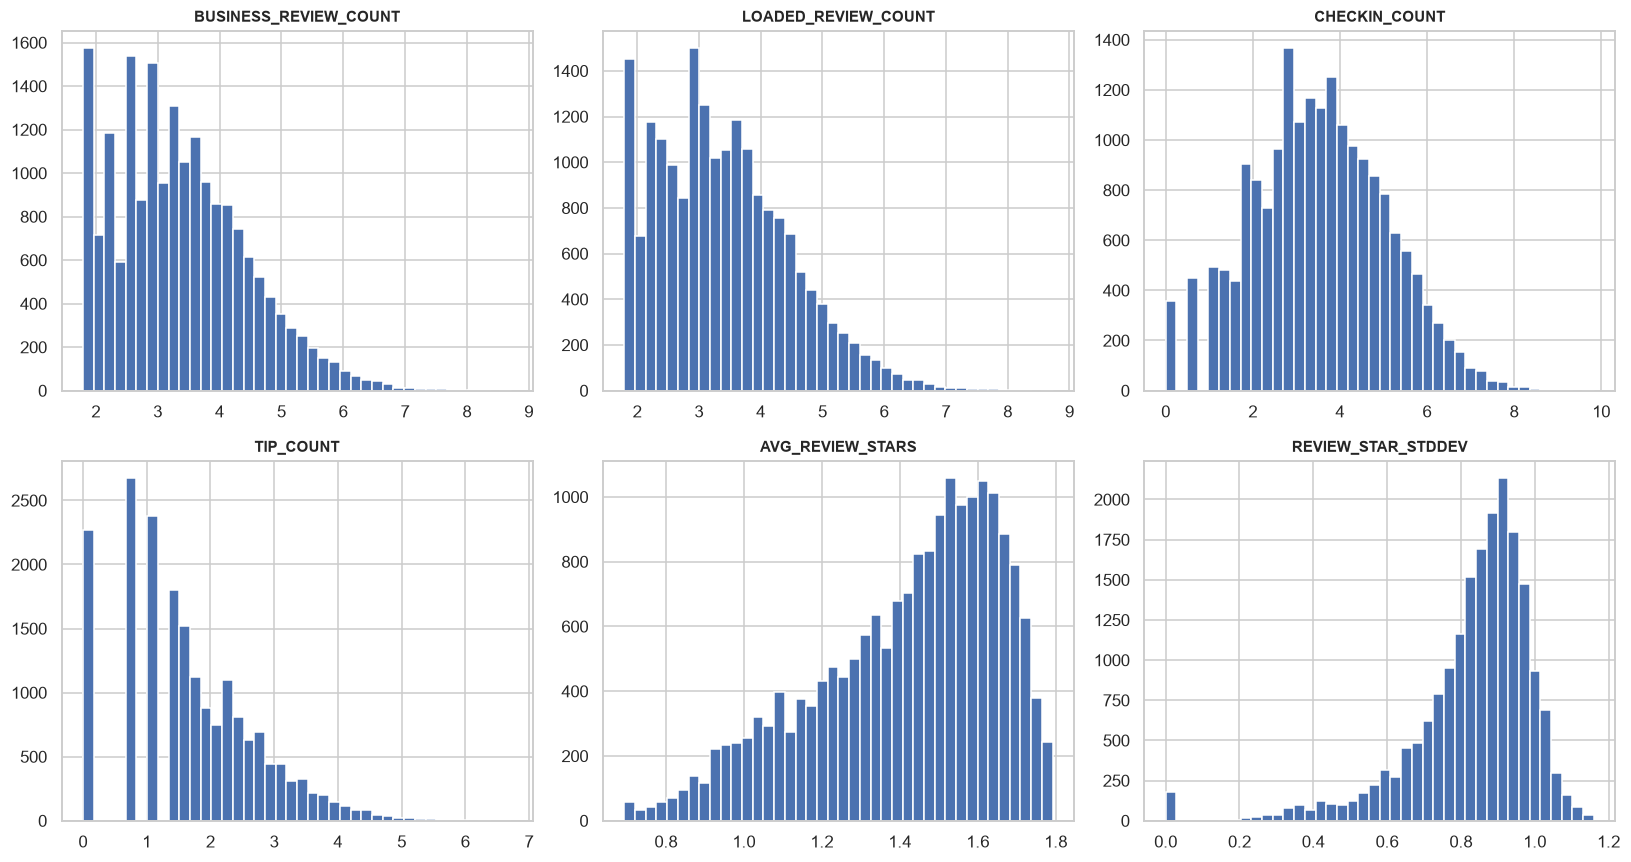

In [11]:
display(Image(filename=f'{FIG}/eda_distributions.png'))

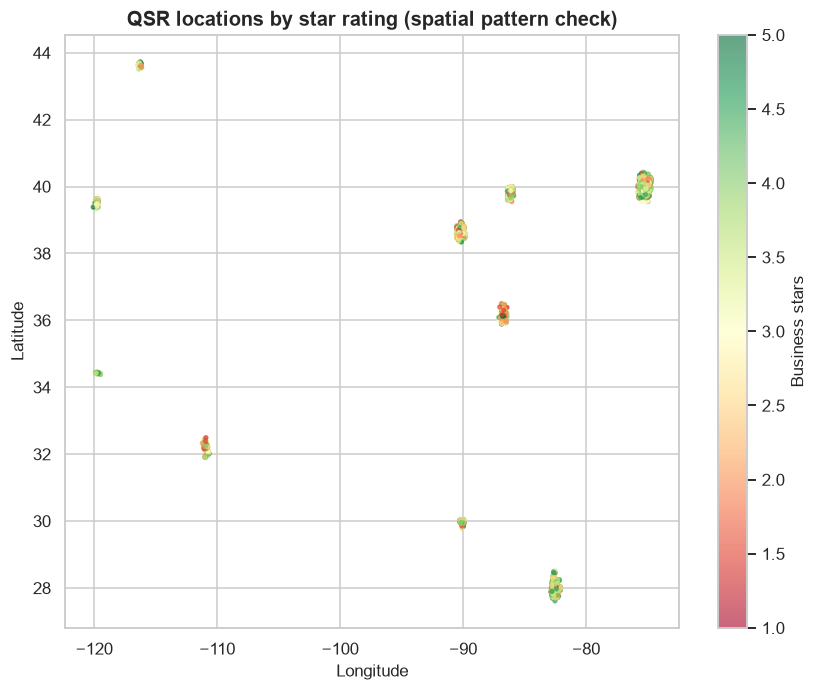

In [12]:
display(Image(filename=f'{FIG}/eda_spatial_stars.png'))

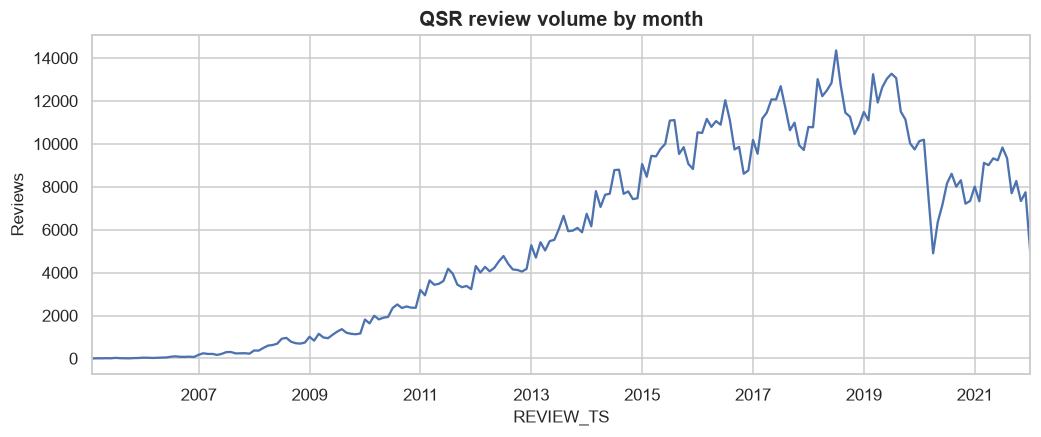

In [13]:
display(Image(filename=f'{FIG}/eda_review_velocity.png'))

**Two findings above are easier to read as charts than as tables.** The volume bucket table behind Q1
becomes a curve, and the segment gap mentioned in the group and spatial finding becomes a sorted bar chart.
Neither changes what was already found. They just make it easier to see at a glance.

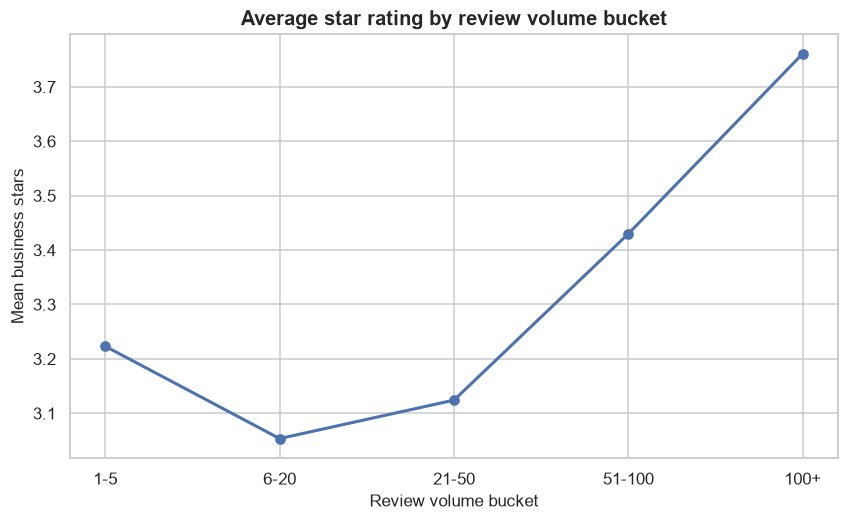

In [14]:
from lib.common import set_plot_theme
import matplotlib.pyplot as plt

set_plot_theme()
q1 = pd.read_csv(f'{OUT}/QSR_EDA_Q1_VOLUME_EFFECTS.csv')
fig, ax = plt.subplots()
ax.plot(q1['_vol_bucket'], q1['mean_stars'], marker='o', color='#4C72B0', linewidth=2)
ax.set_title('Average star rating by review volume bucket')
ax.set_xlabel('Review volume bucket')
ax.set_ylabel('Mean business stars')
plt.show()

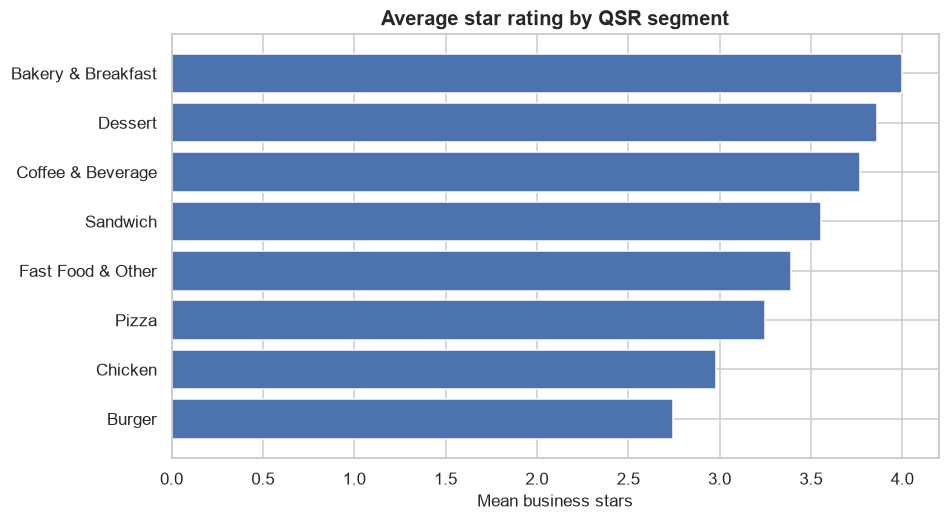

In [15]:
seg = pd.read_csv(f'{OUT}/QSR_EDA_SEGMENT_STARS.csv')
fig, ax = plt.subplots()
ax.barh(seg['QSR_SEGMENT'], seg['mean'], color='#4C72B0')
ax.set_title('Average star rating by QSR segment')
ax.set_xlabel('Mean business stars')
plt.show()

**Q2 evidence detail.** Pearson and Spearman correlation, plus VIF, among the three business-level pillars
available before CX exists (the full four-pillar check, with CX included, is in Section 9/10):

In [16]:
display(pd.read_csv(f'{OUT}/QSR_EDA_Q2_SPEARMAN_CORR.csv', index_col=0))
display(pd.read_csv(f'{OUT}/QSR_EDA_Q2_VIF.csv'))

,PEER_star_gap,PEER_rating_pct,ENGAGEMENT_log_reviews,ENGAGEMENT_checkins_per_review,ENGAGEMENT_tips_per_review,MOMENTUM_rating_trend
PEER_star_gap,1.000000,0.980676,0.336048,-0.074582,-0.001556,0.014042
PEER_rating_pct,0.980676,1.000000,0.330735,-0.077310,-0.002636,0.013355
ENGAGEMENT_log_reviews,0.336048,0.330735,1.000000,0.172997,-0.082205,0.021472
ENGAGEMENT_checkins_per_review,-0.074582,-0.077310,0.172997,1.000000,0.437599,0.003739
ENGAGEMENT_tips_per_review,-0.001556,-0.002636,-0.082205,0.437599,1.000000,0.014809
MOMENTUM_rating_trend,0.014042,0.013355,0.021472,0.003739,0.014809,1.000000


,FEATURE,VIF
0,PEER_star_gap,15.701571
1,PEER_rating_pct,15.685240
2,ENGAGEMENT_log_reviews,1.168940
3,ENGAGEMENT_checkins_per_review,1.207337
4,ENGAGEMENT_tips_per_review,1.209343
5,MOMENTUM_rating_trend,1.000997


**Section finding.** Review-volume distortion is real but non-monotonic (Q1). The more robust pattern is
that average rating itself climbs with review volume (popularity and survivorship at work), which is a reason
to keep Engagement and Peer as separate but watched pillars, rather than treating it as a clean confirmation of
the shrinkage story. Shrinkage toward a peer prior for low-volume businesses (Section 5) is still defensible on
general statistical grounds regardless. Peer, Engagement, and Momentum show low cross-pillar correlation once
the expected within-Peer overlap is set aside (star-gap vs rating-percentile, VIF around 15.7 for both, which
are simply two views of the same peer comparison). That supports keeping the pillars separate. The
leakage-preview correlation scan foreshadows Section 7's formal audit: recency features dominate the ranked
list of columns correlated with `IS_OPEN`, exactly as the manually-verified finding predicted. Notably, the raw
Pearson correlations are modest (around 0.25), because the feature is extremely zero-inflated for closed
businesses. The raw group-rate comparison (92.7% vs 12.8%) is the more diagnostic number here, a reminder that
correlation coefficients can understate leakage from skewed features. **Q5** finds `DAYS_WITH_HOURS` has low
overlap with the Peer and Engagement proxies available at this point (both under 0.25), which makes it worth
carrying forward as a candidate. Its conceptual validity is the harder question though: does it actually
*measure* health, or does it just correlate with it? That gets resolved with real evidence in Section 10.

## 4. Aspect-Based Sentiment Analysis (ABSA)

A **transparent heuristic layer**: keyword taxonomy plus VADER lexicon, not a contextual transformer model.
Known, disclosed weakness: naive keyword matching can misread contrastive sentences ("the food wasn't bad but
the service was terrible"). Validated by convergent validity against star ratings, not a labelled gold
standard.

**Seven aspects, not six.** Food, Service, Staff, Cleanliness, Waiting Time, and Value were the original set.
**Order Accuracy** was added after a gap review found the brief's "order accuracy" theme had no home in the
original taxonomy. It isn't assumed to be useful just because it was added. It goes through the same
convergent-validity check as the other six below, and the result is reported honestly rather than rounded up.

*1.16M reviews against all seven aspects.*

In [17]:
"""Stage 4 - Aspect-based sentiment analysis (ABSA).

Transparent heuristic layer (keyword taxonomy + VADER, see lib/absa.py), not
a contextual model -- explicitly disclosed as a limitation, not hidden.
Produces:
  - qsr_review_aspect.parquet: one row per (review, aspect) with sentiment
    and recency weight
  - QSR_ASPECT_BUSINESS_SUMMARY.csv: per-business, per-aspect mean sentiment,
    mention count, negative-mention rate, and aspect coverage (% of that
    business's reviews carrying evidence for the aspect) -- coverage feeds
    the confidence score in stage 12 directly.
Validation is convergent-validity only (aspect sentiment vs star rating,
business-clustered bootstrap CI, monotonicity) plus a small spot-check audit
-- labeled as a lightweight audit, not a multi-annotator gold standard.
"""
from __future__ import annotations

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

from lib.common import OUTPUT_DIR, DATASET_CUTOFF, ASPECTS, recency_weight, log, require, set_plot_theme, savefig, bootstrap_ci_mean_clustered
from lib.absa import score_review

REPORT_EVERY = 100_000


def score_all_reviews(reviews: pd.DataFrame) -> pd.DataFrame:
    rows = []
    t0 = time.time()
    for i, r in enumerate(reviews.itertuples(index=False)):
        for hit in score_review(r.REVIEW_TEXT):
            rows.append((r.REVIEW_ID, r.BUSINESS_ID, r.STARS, r.REVIEW_TS, hit["ASPECT"], hit["SENTIMENT"], hit["N_SENTENCES"]))
        if (i + 1) % REPORT_EVERY == 0:
            log(f"...scored {i + 1:,}/{len(reviews):,} reviews in {time.time() - t0:.0f}s")
    log(f"Finished scoring {len(reviews):,} reviews in {time.time() - t0:.0f}s -> {len(rows):,} review-aspect rows")
    return pd.DataFrame(rows, columns=["REVIEW_ID", "BUSINESS_ID", "STARS", "REVIEW_TS", "ASPECT", "SENTIMENT", "N_SENTENCES"])


def business_aspect_summary(review_aspect: pd.DataFrame, reviews: pd.DataFrame) -> pd.DataFrame:
    ra = review_aspect.copy()
    ra["REVIEW_TS"] = pd.to_datetime(ra["REVIEW_TS"], errors="coerce")
    ra["AGE_DAYS"] = (DATASET_CUTOFF - ra["REVIEW_TS"]).dt.days.clip(lower=0)
    ra["RECENCY_WEIGHT"] = recency_weight(ra["AGE_DAYS"])
    ra["IS_NEGATIVE"] = ra["SENTIMENT"] < -0.05

    total_reviews_per_biz = reviews.groupby("BUSINESS_ID").size().rename("TOTAL_REVIEWS")

    summaries = []
    for aspect in ASPECTS:
        sub = ra[ra["ASPECT"] == aspect]
        g = sub.groupby("BUSINESS_ID").apply(
            lambda x: pd.Series({
                "N_MENTIONS": len(x),
                "RAW_MEAN_SENTIMENT": x["SENTIMENT"].mean(),
                "RECENCY_WEIGHTED_SENTIMENT": np.average(x["SENTIMENT"], weights=x["RECENCY_WEIGHT"]) if len(x) else np.nan,
                "NEGATIVE_MENTION_RATE": x["IS_NEGATIVE"].mean(),
            }), include_groups=False
        ).reset_index()
        g["ASPECT"] = aspect
        summaries.append(g)

    out = pd.concat(summaries, ignore_index=True)
    out = out.merge(total_reviews_per_biz, on="BUSINESS_ID", how="right")
    out["ASPECT"] = out["ASPECT"].fillna("__NONE__")
    out["N_MENTIONS"] = out["N_MENTIONS"].fillna(0)
    out["ASPECT_COVERAGE_PCT"] = (out["N_MENTIONS"] / out["TOTAL_REVIEWS"] * 100).round(2)
    return out[out["ASPECT"] != "__NONE__"]


def convergent_validity(review_aspect: pd.DataFrame):
    set_plot_theme()
    import matplotlib.pyplot as plt

    rows = []
    fig, ax = plt.subplots(figsize=(9, 5))
    for aspect in ASPECTS:
        sub = review_aspect[review_aspect["ASPECT"] == aspect]
        if len(sub) < 30:
            continue
        rho, p = stats.spearmanr(sub["STARS"], sub["SENTIMENT"])
        point, lo, hi = bootstrap_ci_mean_clustered(sub.assign(_val=sub["SENTIMENT"]), "_val", "BUSINESS_ID", n_boot=500)
        by_star = sub.groupby("STARS")["SENTIMENT"].mean()
        monotonic = by_star.is_monotonic_increasing
        rows.append({"ASPECT": aspect, "N": len(sub), "SPEARMAN_RHO": round(rho, 4), "P_VALUE": p,
                      "MONOTONIC_VS_STARS": monotonic, "CLUSTER_BOOTSTRAP_MEAN": round(point, 4),
                      "CI_LOW": round(lo, 4), "CI_HIGH": round(hi, 4)})
        ax.plot(by_star.index, by_star.values, marker="o", label=aspect)

    ax.set_xlabel("Yelp review star rating"); ax.set_ylabel("Mean aspect sentiment (-1 to +1)")
    ax.set_title("Aspect sentiment vs star rating (convergent validity, stars excluded from scoring)")
    ax.legend(fontsize=8)
    savefig("absa_convergent_validity")

    val_df = pd.DataFrame(rows)
    val_df.to_csv(OUTPUT_DIR / "QSR_ABSA_CONVERGENT_VALIDITY.csv", index=False)
    log(f"Convergent validity: {val_df[['ASPECT','SPEARMAN_RHO','MONOTONIC_VS_STARS']].to_string(index=False)}")
    return val_df


def spot_check_sample(reviews: pd.DataFrame, review_aspect: pd.DataFrame, n=180, seed=42):
    """Random review sample paired with its predicted aspects/sentiment, for
    a lightweight human audit -- explicitly not a multi-annotator gold set."""
    sample_ids = reviews["REVIEW_ID"].sample(min(n, len(reviews)), random_state=seed)
    sample_reviews = reviews[reviews["REVIEW_ID"].isin(sample_ids)][["REVIEW_ID", "STARS", "REVIEW_TEXT"]]
    sample_aspects = review_aspect[review_aspect["REVIEW_ID"].isin(sample_ids)]
    merged = sample_reviews.merge(
        sample_aspects.groupby("REVIEW_ID").apply(
            lambda x: "; ".join(f"{a}:{s:.2f}" for a, s in zip(x["ASPECT"], x["SENTIMENT"])), include_groups=False
        ).rename("PREDICTED_ASPECTS").reset_index(),
        on="REVIEW_ID", how="left",
    )
    merged["PREDICTED_ASPECTS"] = merged["PREDICTED_ASPECTS"].fillna("(no aspect matched)")
    merged.to_csv(OUTPUT_DIR / "QSR_ABSA_SPOT_CHECK_SAMPLE.csv", index=False)
    log(f"Wrote {len(merged)}-review spot-check sample to QSR_ABSA_SPOT_CHECK_SAMPLE.csv for manual audit")
    return merged


def main():
    reviews_path = OUTPUT_DIR / "qsr_reviews_detail.parquet"
    require(reviews_path.exists(), f"Missing {reviews_path} -- run stage 2 first")
    reviews = pd.read_parquet(reviews_path)
    reviews = reviews[reviews["REVIEW_TEXT"].notna() & (reviews["REVIEW_TEXT"].str.len() > 0)]
    log(f"Loaded {len(reviews):,} reviews with text")

    review_aspect = score_all_reviews(reviews)
    review_aspect.to_parquet(OUTPUT_DIR / "qsr_review_aspect.parquet", index=False)

    coverage_pct = review_aspect["REVIEW_ID"].nunique() / len(reviews) * 100
    log(f"Aspect coverage: {coverage_pct:.2f}% of reviews carry at least one aspect mention")

    summary = business_aspect_summary(review_aspect, reviews)
    summary.to_csv(OUTPUT_DIR / "QSR_ASPECT_BUSINESS_SUMMARY.csv", index=False)

    convergent_validity(review_aspect)
    spot_check_sample(reviews, review_aspect)

    log("Stage 4 complete.")


if __name__ == "__main__":
    main()

[22:57:11] Loaded 1,161,430 reviews with text


[22:58:29] ...scored 100,000/1,161,430 reviews in 78s


[22:59:53] ...scored 200,000/1,161,430 reviews in 162s


[23:01:12] ...scored 300,000/1,161,430 reviews in 241s


[23:02:30] ...scored 400,000/1,161,430 reviews in 319s


...

[23:10:00] ...scored 1,100,000/1,161,430 reviews in 769s


[23:10:21] Finished scoring 1,161,430 reviews in 790s -> 2,647,535 review-aspect rows


[23:10:27] Aspect coverage: 94.94% of reviews carry at least one aspect mention


[23:14:12] Convergent validity:         ASPECT  SPEARMAN_RHO  MONOTONIC_VS_STARS
          FOOD        0.5314                True
       SERVICE        0.6230                True
         STAFF        0.5853                True
   CLEANLINESS        0.5827                True
  WAITING_TIME        0.4205                True
ORDER_ACCURACY        0.2298                True
         VALUE        0.4083                True


[23:14:14] Wrote 180-review spot-check sample to QSR_ABSA_SPOT_CHECK_SAMPLE.csv for manual audit
[23:14:14] Stage 4 complete.


,ASPECT,N,SPEARMAN_RHO,P_VALUE,MONOTONIC_VS_STARS,CLUSTER_BOOTSTRAP_MEAN,CI_LOW,CI_HIGH
0,FOOD,976024,0.5314,0.000000e+00,True,0.3241,0.3213,0.3270
1,SERVICE,469539,0.6230,0.000000e+00,True,0.3488,0.3436,0.3544
2,STAFF,305295,0.5853,0.000000e+00,True,0.3239,0.3187,0.3286
3,CLEANLINESS,122501,0.5827,0.000000e+00,True,0.2203,0.2127,0.2273
4,WAITING_TIME,480368,0.4205,0.000000e+00,True,0.2106,0.2080,0.2134
5,ORDER_ACCURACY,9259,0.2298,3.527631e-111,True,-0.2625,-0.2699,-0.2548
6,VALUE,284549,0.4083,0.000000e+00,True,0.3017,0.2978,0.3051


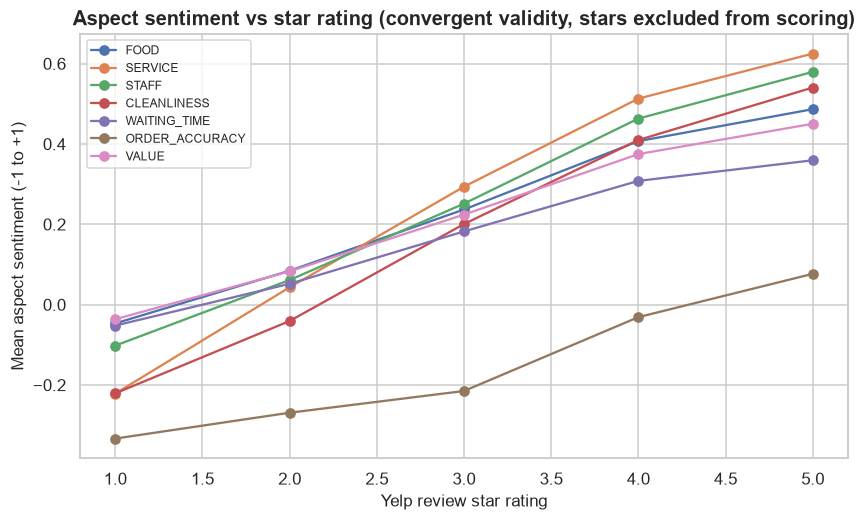

In [18]:
val = pd.read_csv(f'{OUT}/QSR_ABSA_CONVERGENT_VALIDITY.csv')
display(val)
display(Image(filename=f'{FIG}/absa_convergent_validity.png'))

In [19]:
summary = pd.read_csv(f'{OUT}/QSR_ASPECT_BUSINESS_SUMMARY.csv')
print(f"Mean aspect coverage across businesses: {summary.groupby('ASPECT')['ASPECT_COVERAGE_PCT'].mean().round(1).to_dict()}")
summary.groupby('ASPECT')[['N_MENTIONS','NEGATIVE_MENTION_RATE']].mean().round(3)

Mean aspect coverage across businesses: {'CLEANLINESS': 14.6, 'FOOD': 82.3, 'ORDER_ACCURACY': 4.3, 'SERVICE': 42.5, 'STAFF': 30.1, 'VALUE': 24.1, 'WAITING_TIME': 43.0}


,N_MENTIONS,NEGATIVE_MENTION_RATE
ASPECT,,
CLEANLINESS,7.510,0.306
FOOD,50.994,0.164
ORDER_ACCURACY,1.675,0.634
SERVICE,24.911,0.249
STAFF,16.463,0.215
VALUE,15.905,0.181
WAITING_TIME,25.447,0.189


**Finding.** The original six aspects show a monotonic, statistically significant relationship between
sentiment and star rating (Spearman rho 0.41 to 0.62), despite the sentiment scoring never seeing the star
rating at all. 94.9% of reviews carry at least one aspect mention across all seven aspects combined.

**Order Accuracy passes convergent validity, with a real caveat.** It has 9,259 mentions, well above any
reasonable volume floor, and a Spearman rho of 0.23 against star rating (p < 1e-111, monotonic). That's a real
relationship, but noticeably weaker than the other six (0.41 to 0.62). The mean sentiment is markedly negative
(cluster-bootstrap mean of -0.26, CI [-0.270, -0.255]), which makes intuitive sense: "they gave me the wrong
order" is almost never framed positively, unlike "food," which spans both praise and complaints. The aggregate
signal is genuine. What **doesn't** hold up is a business-level *trend* for it. That's checked in Section 6
below, and the honest answer is that most businesses simply don't have enough Order Accuracy mentions per time
window to support one.

A roughly 180-review spot-check sample (`QSR_ABSA_SPOT_CHECK_SAMPLE.csv`) was generated for manual audit. It's
explicitly a lightweight check, not a multi-annotator gold standard.

## 5. Peer Groups + Customer Experience (CX) Pillar

Adaptive peer groups (10 miles, then city, then state, then global segment, always excluding the focal
business) are recomputed locally with grid-accelerated haversine distance, then used for a genuine
leave-one-out peer prior per aspect. Shrinkage pulls low-evidence businesses toward that prior rather than
trusting a noisy raw mean, which is justified by Section 3's Q1 finding.

In [20]:
"""Stage 5 - Peer groups + CX pillar construction.

Recomputes adaptive peer groups locally (lib/peer.py: 10mi -> city -> state
-> global segment, focal business always excluded) so that the per-aspect
peer prior used for shrinkage is a genuine leave-one-out calculation, not
just a reused aggregate. Low-evidence businesses shrink toward their peer
prior (informed by stage 3's Q1 finding that rating variance is noisy at low
review volume); the resulting sentiment is percentile-ranked to build the
CX pillar.
"""
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd

from lib.common import ROOT, OUTPUT_DIR, ASPECTS, require, log, percentile_rank, shrink_to_prior
from lib.peer import assign_peer_groups

EVIDENCE_HIGH_MIN_MENTIONS = 30
EVIDENCE_MEDIUM_MIN_MENTIONS = 5


def build_peer_groups(biz: pd.DataFrame) -> pd.DataFrame:
    log("Assigning adaptive peer groups (10mi -> city -> state -> global segment)...")
    peer_groups = assign_peer_groups(biz[["BUSINESS_ID", "CITY", "STATE", "QSR_SEGMENT", "LATITUDE", "LONGITUDE", "IS_OPEN"]])
    tier_counts = peer_groups["PEER_TIER"].value_counts()
    log(f"Peer tier assignment: {tier_counts.to_dict()}")
    peer_groups.to_csv(OUTPUT_DIR / "QSR_PEER_GROUPS.csv",
                        index=False, columns=["BUSINESS_ID", "PEER_TIER", "PEER_GROUP_SIZE"])
    return peer_groups


def leave_one_out_prior(aspect_df: pd.DataFrame, peer_groups: pd.DataFrame, aspect: str) -> pd.Series:
    """Volume-weighted mean sentiment among each business's own peer list."""
    sub = aspect_df[aspect_df["ASPECT"] == aspect].set_index("BUSINESS_ID")
    sent = sub["RECENCY_WEIGHTED_SENTIMENT"]
    weight = sub["N_MENTIONS"]

    priors = {}
    for row in peer_groups.itertuples(index=False):
        peers = row.PEER_IDS
        if not peers:
            priors[row.BUSINESS_ID] = np.nan
            continue
        peer_sent = sent.reindex(peers).dropna()
        if peer_sent.empty:
            priors[row.BUSINESS_ID] = np.nan
            continue
        peer_weight = weight.reindex(peer_sent.index).fillna(1.0)
        priors[row.BUSINESS_ID] = float(np.average(peer_sent, weights=peer_weight))
    return pd.Series(priors, name="PEER_PRIOR")


def main():
    biz = pd.read_csv(ROOT / "QSR_BUSINESS_ANALYSIS_READY.csv", low_memory=False)
    aspect_path = OUTPUT_DIR / "QSR_ASPECT_BUSINESS_SUMMARY.csv"
    require(aspect_path.exists(), f"Missing {aspect_path} -- run stage 4 first")
    aspect_df = pd.read_csv(aspect_path)

    peer_groups = build_peer_groups(biz)

    segment_map = biz.set_index("BUSINESS_ID")["QSR_SEGMENT"]
    state_map = biz.set_index("BUSINESS_ID")["STATE"]

    aspect_scores = []
    for aspect in ASPECTS:
        log(f"Scoring CX aspect: {aspect}")
        prior = leave_one_out_prior(aspect_df, peer_groups, aspect)
        sub = aspect_df[aspect_df["ASPECT"] == aspect].set_index("BUSINESS_ID").reindex(biz["BUSINESS_ID"])
        sub["PEER_PRIOR"] = prior.reindex(sub.index)
        # Fall back to segment-level prior for any business whose own peer list
        # produced no usable prior (tiny/global-only groups) -- visible, not silent.
        seg_prior = aspect_df[aspect_df["ASPECT"] == aspect].assign(
            SEG=lambda d: d["BUSINESS_ID"].map(segment_map)
        ).groupby("SEG")["RECENCY_WEIGHTED_SENTIMENT"].mean()
        sub["PRIOR_FALLBACK_USED"] = sub["PEER_PRIOR"].isna()
        fallback_mask = sub["PEER_PRIOR"].isna()
        if fallback_mask.any():
            fill_values = sub.loc[fallback_mask].index.map(segment_map).map(seg_prior).astype(float).values
            sub.loc[fallback_mask, "PEER_PRIOR"] = fill_values

        raw_mean = sub["RAW_MEAN_SENTIMENT"].fillna(sub["PEER_PRIOR"])
        n_eff = sub["N_MENTIONS"].fillna(0)
        shrunk = shrink_to_prior(raw_mean, n_eff, sub["PEER_PRIOR"].fillna(0), prior_strength=10.0)
        absolute_score = 50 * (shrunk + 1)

        # Percentile against same segment+state population as a practical
        # approximation of "against this business's own peer list" (exact
        # per-business percentile against individualized peer sets isn't
        # vectorizable cleanly; segment+state is the same reference frame
        # TIER_2/3 already falls back to).
        group_key = sub.index.map(segment_map).astype(str) + "|" + sub.index.map(state_map).astype(str)
        pct = absolute_score.groupby(group_key).transform(percentile_rank)

        out = pd.DataFrame({
            "BUSINESS_ID": sub.index,
            "ASPECT": aspect,
            "N_MENTIONS": n_eff.values,
            "RAW_SENTIMENT": sub["RAW_MEAN_SENTIMENT"].values,
            "PEER_PRIOR": sub["PEER_PRIOR"].values,
            "PRIOR_FALLBACK_USED": sub["PRIOR_FALLBACK_USED"].values,
            "SHRUNK_SENTIMENT": shrunk.values,
            "ABSOLUTE_SCORE_0_100": absolute_score.values,
            "PEER_PERCENTILE": pct.values,
        })
        aspect_scores.append(out)

    aspect_scores_df = pd.concat(aspect_scores, ignore_index=True)
    aspect_scores_df.to_csv(OUTPUT_DIR / "QSR_CX_ASPECT_SCORES.csv", index=False)

    # CX pillar = equal-weight mean of the aspect peer-percentiles (7 aspects
    # as of the Order Accuracy addition -- see ASPECTS in lib/common.py).
    cx_pillar = aspect_scores_df.groupby("BUSINESS_ID")["PEER_PERCENTILE"].mean().rename("PILLAR_CX")
    total_mentions = aspect_scores_df.groupby("BUSINESS_ID")["N_MENTIONS"].sum().rename("TOTAL_ASPECT_MENTIONS")

    evidence = pd.cut(
        total_mentions, bins=[-1, EVIDENCE_MEDIUM_MIN_MENTIONS - 1, EVIDENCE_HIGH_MIN_MENTIONS - 1, np.inf],
        labels=["Low", "Medium", "High"],
    ).rename("CX_EVIDENCE_CONFIDENCE")

    cx_out = pd.concat([cx_pillar, total_mentions, evidence], axis=1).reset_index()
    cx_out = cx_out.rename(columns={"index": "BUSINESS_ID"})
    cx_out.to_csv(OUTPUT_DIR / "QSR_CX_PILLAR.csv", index=False)

    log(f"CX evidence confidence distribution: {cx_out['CX_EVIDENCE_CONFIDENCE'].value_counts().to_dict()}")
    log("Stage 5 complete.")


if __name__ == "__main__":
    main()

[23:14:17] Assigning adaptive peer groups (10mi -> city -> state -> global segment)...


[23:16:29] Peer tier assignment: {'TIER_1_LOCAL_10MI': 19033, 'TIER_3_STATE_SEGMENT': 71, 'TIER_4_GLOBAL_SEGMENT': 45, 'TIER_2_CITY_SEGMENT': 5}
[23:16:29] Scoring CX aspect: FOOD


[23:17:55] Scoring CX aspect: SERVICE


[23:18:49] Scoring CX aspect: STAFF


[23:19:24] Scoring CX aspect: CLEANLINESS


[23:20:32] Scoring CX aspect: WAITING_TIME


[23:21:27] Scoring CX aspect: ORDER_ACCURACY


[23:22:16] Scoring CX aspect: VALUE


[23:23:09] CX evidence confidence distribution: {'High': 14023, 'Medium': 5122, 'Low': 9}
[23:23:09] Stage 5 complete.


In [21]:
pg = pd.read_csv(f'{OUT}/QSR_PEER_GROUPS.csv')
display(pg['PEER_TIER'].value_counts())
cx = pd.read_csv(f'{OUT}/QSR_CX_PILLAR.csv')
display(cx['CX_EVIDENCE_CONFIDENCE'].value_counts())

PEER_TIER
TIER_1_LOCAL_10MI        19033
TIER_3_STATE_SEGMENT        71
TIER_4_GLOBAL_SEGMENT       45
TIER_2_CITY_SEGMENT          5
Name: count, dtype: int64

CX_EVIDENCE_CONFIDENCE
High      14023
Medium     5122
Low           9
Name: count, dtype: int64

**Peer group size, not just peer tier.** The tier counts above say how many businesses land in each tier.
They do not say how many peers a typical business is actually compared against, and that matters just as much
for how much to trust a peer percentile. A business benchmarked against 300 peers and a business benchmarked
against 4 peers can carry the same tier label while meaning very different things.

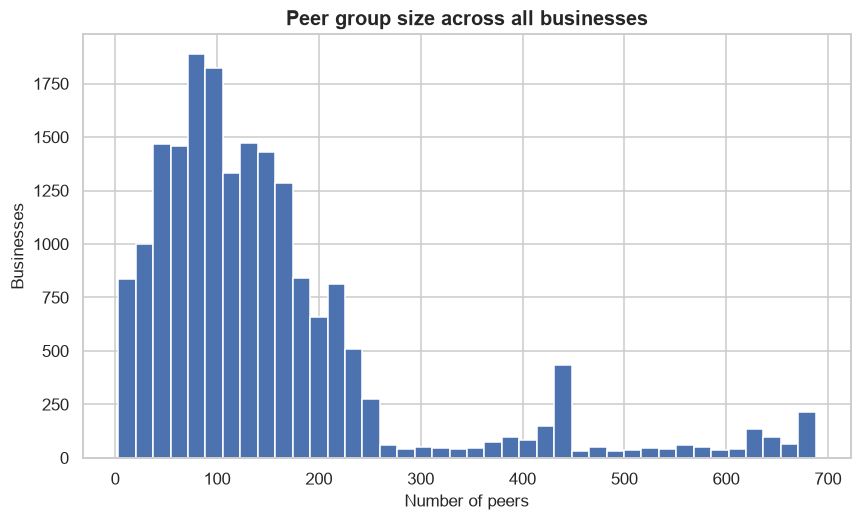

Median peer group size: 119
10th percentile: 38, 90th percentile: 311
315 businesses are compared against fewer than 10 peers.


In [22]:
from lib.common import set_plot_theme
import matplotlib.pyplot as plt

set_plot_theme()
fig, ax = plt.subplots()
ax.hist(pg['PEER_GROUP_SIZE'], bins=40, color='#4C72B0')
ax.set_title('Peer group size across all businesses')
ax.set_xlabel('Number of peers')
ax.set_ylabel('Businesses')
plt.show()

print(f"Median peer group size: {pg['PEER_GROUP_SIZE'].median():.0f}")
print(f"10th percentile: {pg['PEER_GROUP_SIZE'].quantile(0.1):.0f}, 90th percentile: {pg['PEER_GROUP_SIZE'].quantile(0.9):.0f}")
print(f"{(pg['PEER_GROUP_SIZE'] < 10).sum()} businesses are compared against fewer than 10 peers.")

**Finding.** The locally recomputed peer-tier assignment (19,033 local, 71 state, 45 global, 5 city)
reproduces the original Snowflake pipeline's own tier counts almost exactly. That's a strong independent check
that the peer-group logic is correct, even though it was rebuilt from raw latitude and longitude rather than
reused. Peer group size has a long tail: the median business is compared against 119 peers, but 315 businesses
have fewer than 10. Those thin-peer businesses are exactly where a peer percentile deserves the most
skepticism, which is why confidence scoring in Section 12 factors in peer-tier quality rather than treating
every percentile as equally trustworthy.

## 6. Momentum / Trajectory

A recent-vs-prior 12-month window comparison, anchored at the dataset's fixed 2022-01-19 cutoff. Every
direction flag is backed by a bootstrap confidence interval on the delta, not a raw sign check: a business only
gets "Improving" or "Deteriorating" when the confidence interval doesn't cross zero. Businesses without enough
reviews in both windows get an explicit "Insufficient Evidence" flag.

**Two additions beyond the original 12-month trajectory**, both requested explicitly rather than assumed
useful:
- **Recency-weighted star rating**: the same 365-day half-life decay already used for aspect sentiment,
  applied to the raw star rating itself. A continuous complement to the windowed comparison above.
- **Negative-review-spike detector**: a location can be flat on a 12-month view while still absorbing a sharp
  negative cluster in the last 60 days, something the annual window structurally cannot see. It compares
  recent (60-day) vs. prior-12-month negative-review rate, backed by a bootstrap confidence interval, with a
  practical-magnitude floor on top of statistical significance (a real but 1-point shift isn't an operational
  "spike"), cross-checked at 30 and 90 days for consistency.

*(three bootstrap passes: rating trajectory, aspect trajectory, spike detection).*

In [23]:
"""Stage 6 - Momentum / trajectory, separate from current health.

Recent-vs-prior window comparison (12 months each, relative to the dataset's
fixed cutoff 2022-01-19 -- appropriate for "as of the last available data"
framing on open businesses; stage 3's EDA flagged the final partial month as
a truncation artefact, handled by anchoring windows at the cutoff rather than
using the ragged last month alone). Every direction flag is backed by a
bootstrap CI on the recent-vs-prior delta, not a raw sign check. Businesses
without enough reviews in both windows get an explicit "Insufficient
Evidence" flag rather than a fabricated trend -- feeds stage 12's fallback.
"""
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd

from lib.common import OUTPUT_DIR, DATASET_CUTOFF, recency_weight, require, log

MIN_REVIEWS_PER_WINDOW = 5
MIN_ASPECT_MENTIONS_PER_WINDOW = 3
N_BOOT = 1000
RNG = np.random.default_rng(42)

RECENT_START = DATASET_CUTOFF - pd.Timedelta(days=365)
PRIOR_START = DATASET_CUTOFF - pd.Timedelta(days=730)

# Negative-spike detection: a location can be flat on the 12-month trajectory
# above while still absorbing a sharp recent cluster of bad reviews -- the
# annual window structurally cannot see that. 1-2 stars = "negative" (the
# standard Yelp low-rating convention). Baseline is the 12 months immediately
# preceding each recent window (non-overlapping), so every comparison is
# windowed-recent vs a stable prior norm, not two different-length periods.
# SPIKE_MAGNITUDE_MIN is a practical-significance floor on top of the CI --
# a statistically real but 1-point-percentage shift isn't an operational
# "spike"; both a significant CI *and* a real-sized shift are required.
NEGATIVE_STAR_MAX = 2
SPIKE_PRIMARY_WINDOW_DAYS = 60
SPIKE_SENSITIVITY_WINDOWS_DAYS = [30, 90]
SPIKE_MIN_REVIEWS = 5
SPIKE_MAGNITUDE_MIN = 0.10


def two_sample_bootstrap_delta(recent: np.ndarray, prior: np.ndarray, n_boot=N_BOOT):
    if len(recent) < 2 or len(prior) < 2:
        return (np.nan, np.nan, np.nan)
    point = recent.mean() - prior.mean()
    boot = np.empty(n_boot)
    for i in range(n_boot):
        r = recent[RNG.integers(0, len(recent), len(recent))]
        p = prior[RNG.integers(0, len(prior), len(prior))]
        boot[i] = r.mean() - p.mean()
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return (float(point), float(lo), float(hi))


def classify_direction(ci_low, ci_high):
    if np.isnan(ci_low):
        return "Insufficient Evidence"
    if ci_low > 0:
        return "Improving"
    if ci_high < 0:
        return "Deteriorating"
    return "Stable"


def rating_trajectory(reviews: pd.DataFrame) -> pd.DataFrame:
    r = reviews.copy()
    r["REVIEW_TS"] = pd.to_datetime(r["REVIEW_TS"], errors="coerce")
    rows = []
    for bid, g in r.groupby("BUSINESS_ID"):
        recent = g.loc[g["REVIEW_TS"] > RECENT_START, "STARS"].dropna().values
        prior = g.loc[(g["REVIEW_TS"] > PRIOR_START) & (g["REVIEW_TS"] <= RECENT_START), "STARS"].dropna().values
        if len(recent) < MIN_REVIEWS_PER_WINDOW or len(prior) < MIN_REVIEWS_PER_WINDOW:
            rows.append((bid, len(recent), len(prior), np.nan, np.nan, np.nan, "Insufficient Evidence",
                         np.nan, np.nan))
            continue
        delta, lo, hi = two_sample_bootstrap_delta(recent, prior)
        rows.append((bid, len(recent), len(prior), delta, lo, hi, classify_direction(lo, hi),
                     float(recent.mean()), float(prior.mean())))
    return pd.DataFrame(rows, columns=["BUSINESS_ID", "RECENT_REVIEW_COUNT", "PRIOR_REVIEW_COUNT",
                                        "RATING_DELTA", "RATING_DELTA_CI_LOW", "RATING_DELTA_CI_HIGH",
                                        "RATING_TRAJECTORY", "RECENT_MEAN_STARS", "PRIOR_MEAN_STARS"])


def aspect_trajectory(review_aspect: pd.DataFrame) -> pd.DataFrame:
    ra = review_aspect.copy()
    ra["REVIEW_TS"] = pd.to_datetime(ra["REVIEW_TS"], errors="coerce")
    rows = []
    for (bid, aspect), g in ra.groupby(["BUSINESS_ID", "ASPECT"]):
        recent = g.loc[g["REVIEW_TS"] > RECENT_START, "SENTIMENT"].dropna().values
        prior = g.loc[(g["REVIEW_TS"] > PRIOR_START) & (g["REVIEW_TS"] <= RECENT_START), "SENTIMENT"].dropna().values
        if len(recent) < MIN_ASPECT_MENTIONS_PER_WINDOW or len(prior) < MIN_ASPECT_MENTIONS_PER_WINDOW:
            rows.append((bid, aspect, len(recent), len(prior), np.nan, np.nan, np.nan, "Insufficient Evidence"))
            continue
        delta, lo, hi = two_sample_bootstrap_delta(recent, prior, n_boot=500)
        rows.append((bid, aspect, len(recent), len(prior), delta, lo, hi, classify_direction(lo, hi)))
    return pd.DataFrame(rows, columns=["BUSINESS_ID", "ASPECT", "RECENT_MENTIONS", "PRIOR_MENTIONS",
                                        "ASPECT_SENTIMENT_DELTA", "CI_LOW", "CI_HIGH", "ASPECT_TRAJECTORY"])


def recency_weighted_rating(reviews: pd.DataFrame) -> pd.DataFrame:
    """Business-level recency-weighted average star rating (365-day half-
    life, same decay used for aspect sentiment) -- a continuous complement to
    the windowed RATING_TRAJECTORY above: it answers "what does this
    business's rating look like once older reviews count for less," not
    "did the average shift between two fixed windows."
    """
    r = reviews.copy()
    r["REVIEW_TS"] = pd.to_datetime(r["REVIEW_TS"], errors="coerce")
    r["AGE_DAYS"] = (DATASET_CUTOFF - r["REVIEW_TS"]).dt.days.clip(lower=0)
    r["W"] = recency_weight(r["AGE_DAYS"])

    def _agg(x):
        return pd.Series({
            "RECENCY_WEIGHTED_STARS": np.average(x["STARS"], weights=x["W"]) if len(x) else np.nan,
            "RAW_AVG_STARS": x["STARS"].mean(),
        })

    g = r.groupby("BUSINESS_ID").apply(_agg, include_groups=False).reset_index()
    g["RECENCY_VS_RAW_GAP"] = g["RECENCY_WEIGHTED_STARS"] - g["RAW_AVG_STARS"]
    return g


def negative_spike_detector(reviews: pd.DataFrame) -> pd.DataFrame:
    """Recent-vs-baseline negative-review-rate shift at 60 days (primary,
    bootstrap-CI-backed), cross-checked at 30 and 90 days (point-estimate
    only, for consistency -- not bootstrapped, to keep this a single pass
    over the review data rather than three)."""
    r = reviews.copy()
    r["REVIEW_TS"] = pd.to_datetime(r["REVIEW_TS"], errors="coerce")
    r["IS_NEGATIVE"] = (r["STARS"] <= NEGATIVE_STAR_MAX).astype(float)

    windows = [SPIKE_PRIMARY_WINDOW_DAYS] + SPIKE_SENSITIVITY_WINDOWS_DAYS

    rows = []
    for bid, g in r.groupby("BUSINESS_ID"):
        row = {"BUSINESS_ID": bid}
        for days in windows:
            recent_start = DATASET_CUTOFF - pd.Timedelta(days=days)
            baseline_end = recent_start
            baseline_start = baseline_end - pd.Timedelta(days=365)
            recent = g.loc[g["REVIEW_TS"] > recent_start, "IS_NEGATIVE"].dropna().values
            baseline = g.loc[(g["REVIEW_TS"] > baseline_start) & (g["REVIEW_TS"] <= baseline_end),
                              "IS_NEGATIVE"].dropna().values
            enough = len(recent) >= SPIKE_MIN_REVIEWS and len(baseline) >= SPIKE_MIN_REVIEWS

            if days == SPIKE_PRIMARY_WINDOW_DAYS:
                if not enough:
                    row.update({"SPIKE_RECENT_N": len(recent), "SPIKE_BASELINE_N": len(baseline),
                                "SPIKE_RECENT_NEGATIVE_RATE": np.nan, "SPIKE_BASELINE_NEGATIVE_RATE": np.nan,
                                "SPIKE_RATE_DELTA": np.nan, "SPIKE_DELTA_CI_LOW": np.nan,
                                "SPIKE_DELTA_CI_HIGH": np.nan, "SPIKE_DETECTED": False})
                    continue
                delta, lo, hi = two_sample_bootstrap_delta(recent, baseline, n_boot=500)
                row.update({
                    "SPIKE_RECENT_N": len(recent), "SPIKE_BASELINE_N": len(baseline),
                    "SPIKE_RECENT_NEGATIVE_RATE": float(recent.mean()),
                    "SPIKE_BASELINE_NEGATIVE_RATE": float(baseline.mean()),
                    "SPIKE_RATE_DELTA": delta, "SPIKE_DELTA_CI_LOW": lo, "SPIKE_DELTA_CI_HIGH": hi,
                    "SPIKE_DETECTED": bool(lo > 0 and delta >= SPIKE_MAGNITUDE_MIN),
                })
            else:
                prefix = f"SPIKE_{days}D"
                if not enough:
                    row[f"{prefix}_DELTA"] = np.nan
                    row[f"{prefix}_FLAG"] = False
                    continue
                delta = float(recent.mean() - baseline.mean())
                row[f"{prefix}_DELTA"] = delta
                row[f"{prefix}_FLAG"] = bool(delta >= SPIKE_MAGNITUDE_MIN)
        rows.append(row)

    out = pd.DataFrame(rows)
    out["SPIKE_STATUS"] = np.select(
        [out["SPIKE_DETECTED"], out["SPIKE_RATE_DELTA"] > 0, out["SPIKE_RATE_DELTA"].isna()],
        ["Spike Detected", "Elevated (not significant)", "Insufficient Evidence"],
        default="No Spike",
    )
    return out


def main():
    reviews_path = OUTPUT_DIR / "qsr_reviews_detail.parquet"
    aspect_path = OUTPUT_DIR / "qsr_review_aspect.parquet"
    require(reviews_path.exists(), f"Missing {reviews_path} -- run stage 2 first")
    require(aspect_path.exists(), f"Missing {aspect_path} -- run stage 4 first")

    reviews = pd.read_parquet(reviews_path, columns=["BUSINESS_ID", "STARS", "REVIEW_TS"])
    review_aspect = pd.read_parquet(aspect_path)

    log("Computing rating trajectory (recent vs prior 12-month windows)...")
    rating_traj = rating_trajectory(reviews)
    rating_traj.to_csv(OUTPUT_DIR / "QSR_RATING_TRAJECTORY.csv", index=False)
    log(f"Rating trajectory distribution: {rating_traj['RATING_TRAJECTORY'].value_counts().to_dict()}")

    log("Computing aspect-sentiment trajectory...")
    aspect_traj = aspect_trajectory(review_aspect)
    aspect_traj.to_csv(OUTPUT_DIR / "QSR_ASPECT_TRAJECTORY.csv", index=False)
    oa_traj = aspect_traj[aspect_traj["ASPECT"] == "ORDER_ACCURACY"]
    log(f"Order Accuracy trajectory (recent-vs-prior movement, n={len(oa_traj)}): "
        f"{oa_traj['ASPECT_TRAJECTORY'].value_counts().to_dict()}")

    log("Computing recency-weighted star rating...")
    recency_stars = recency_weighted_rating(reviews)
    recency_stars.to_csv(OUTPUT_DIR / "QSR_RECENCY_WEIGHTED_RATING.csv", index=False)

    log(f"Detecting negative-review spikes ({SPIKE_PRIMARY_WINDOW_DAYS}-day primary window, "
        f"{SPIKE_SENSITIVITY_WINDOWS_DAYS}-day sensitivity checks)...")
    spikes = negative_spike_detector(reviews)
    spikes.to_csv(OUTPUT_DIR / "QSR_NEGATIVE_SPIKE.csv", index=False)
    log(f"Spike status distribution: {spikes['SPIKE_STATUS'].value_counts().to_dict()}")

    # Volume momentum -- magnitude context only, not used to set direction.
    rating_traj["VOLUME_MOMENTUM_LOG"] = (
        np.log1p(rating_traj["RECENT_REVIEW_COUNT"]) - np.log1p(rating_traj["PRIOR_REVIEW_COUNT"])
    )

    # Business-level composite direction: rating trajectory is the primary
    # signal (available for virtually every business with any recent
    # activity); aspect trajectories feed "reason for change" in stage 11,
    # not the direction flag itself, to avoid double-counting the same
    # underlying review text twice.
    worst_aspect = (
        aspect_traj[aspect_traj["ASPECT_TRAJECTORY"] == "Deteriorating"]
        .sort_values("ASPECT_SENTIMENT_DELTA")
        .groupby("BUSINESS_ID")
        .first()[["ASPECT", "ASPECT_SENTIMENT_DELTA"]]
        .rename(columns={"ASPECT": "TOP_DETERIORATING_ASPECT", "ASPECT_SENTIMENT_DELTA": "TOP_DETERIORATING_DELTA"})
    )

    out = rating_traj.merge(worst_aspect, on="BUSINESS_ID", how="left")
    out = out.merge(recency_stars[["BUSINESS_ID", "RECENCY_WEIGHTED_STARS", "RECENCY_VS_RAW_GAP"]],
                     on="BUSINESS_ID", how="left")
    spike_cols = ["BUSINESS_ID", "SPIKE_DETECTED", "SPIKE_STATUS",
                  "SPIKE_RECENT_NEGATIVE_RATE", "SPIKE_BASELINE_NEGATIVE_RATE", "SPIKE_RATE_DELTA",
                  "SPIKE_30D_FLAG", "SPIKE_90D_FLAG"]
    out = out.merge(spikes[spike_cols], on="BUSINESS_ID", how="left")
    out.to_csv(OUTPUT_DIR / "QSR_TRAJECTORY_FINAL.csv", index=False)

    log("Stage 6 complete.")


if __name__ == "__main__":
    main()

[23:23:10] Computing rating trajectory (recent vs prior 12-month windows)...


[23:26:22] Rating trajectory distribution: {'Insufficient Evidence': 15255, 'Stable': 3385, 'Deteriorating': 357, 'Improving': 157}
[23:26:22] Computing aspect-sentiment trajectory...


[23:31:51] Order Accuracy trajectory (recent-vs-prior movement, n=5529): {'Insufficient Evidence': 5526, 'Stable': 2, 'Improving': 1}
[23:31:51] Computing recency-weighted star rating...


[23:31:58] Detecting negative-review spikes (60-day primary window, [30, 90]-day sensitivity checks)...


[23:32:53] Spike status distribution: {'Insufficient Evidence': 18504, 'No Spike': 361, 'Elevated (not significant)': 268, 'Spike Detected': 21}


[23:32:53] Stage 6 complete.


In [24]:
traj = pd.read_csv(f'{OUT}/QSR_TRAJECTORY_FINAL.csv')
display(traj['RATING_TRAJECTORY'].value_counts())
traj[['RECENT_REVIEW_COUNT','PRIOR_REVIEW_COUNT','RATING_DELTA']].describe()

RATING_TRAJECTORY
Insufficient Evidence    15255
Stable                    3385
Deteriorating              357
Improving                  157
Name: count, dtype: int64

,RECENT_REVIEW_COUNT,PRIOR_REVIEW_COUNT,RATING_DELTA
count,19154.000000,19154.000000,3899.000000
mean,5.344732,4.803905,-0.114143
std,12.572162,10.810822,0.700245
min,0.000000,0.000000,-3.611111
25%,0.000000,0.000000,-0.500000
50%,2.000000,2.000000,-0.110577
75%,6.000000,5.000000,0.285714
max,428.000000,367.000000,4.000000


In [25]:
print('Recency-weighted vs. raw average star rating (should track closely, diverging most for businesses whose')
print('recent reviews differ sharply from their older ones):')
display(traj[['RECENCY_WEIGHTED_STARS','RECENCY_VS_RAW_GAP']].describe())

print()
print('Negative-review-spike status:')
display(traj['SPIKE_STATUS'].value_counts())
display(traj[traj['SPIKE_DETECTED'] == True][['BUSINESS_ID','SPIKE_RECENT_NEGATIVE_RATE',
        'SPIKE_BASELINE_NEGATIVE_RATE','SPIKE_RATE_DELTA']].head(10))

Recency-weighted vs. raw average star rating (should track closely, diverging most for businesses whose
recent reviews differ sharply from their older ones):


,RECENCY_WEIGHTED_STARS,RECENCY_VS_RAW_GAP
count,19154.000000,19154.000000
mean,3.115606,-0.117503
std,1.067578,0.426078
min,1.000000,-2.606267
25%,2.249046,-0.335044
50%,3.244608,-0.076083
75%,3.996903,0.086226
max,5.000000,2.454479



Negative-review-spike status:


SPIKE_STATUS
Insufficient Evidence         18504
No Spike                        361
Elevated (not significant)      268
Spike Detected                   21
Name: count, dtype: int64

,BUSINESS_ID,SPIKE_RECENT_NEGATIVE_RATE,SPIKE_BASELINE_NEGATIVE_RATE,SPIKE_RATE_DELTA
713,1IuLzYvrAleNSIc-FVgIYw,1.000000,0.705882,0.294118
1065,2W0P6hXCbE6EgP5R6y9eBw,0.555556,0.157895,0.397661
1634,4OLzI9PLO01aU264zh_c3w,0.666667,0.192593,0.474074
3111,999BA3SLLoev5YU_dMpvnA,0.666667,0.125000,0.541667
3682,B5eJm8A4eiuPLW5C6l75dQ,0.666667,0.142857,0.523810
3729,BJBSwMKADtYjqFDCL3-zkw,1.000000,0.636364,0.363636
3847,BgrvT165fB_wCsZazonMtA,1.000000,0.576923,0.423077
4078,CPFKi2lZJazP6IdtCdDDyg,0.363636,0.075000,0.288636
4409,DZYSb9amfB3EAh1IdwtbEA,0.727273,0.320000,0.407273
4502,DuB7JAFDaR6RUJRLU1Avbw,1.000000,0.764706,0.235294


**Finding.** Health and trajectory are genuinely different questions. Section 11 shows businesses with a
high current LHI but a statistically supported *Deteriorating* trend, and vice versa. Treating them as one
number would hide exactly the early-warning cases this project is meant to surface. Only around 20% of
businesses have enough review history in both windows to be evidenced either way for the 12-month trajectory.
That's a real limitation, disclosed here rather than papered over with a fabricated trend for the rest.

**The spike detector has the same limitation, only sharper.** Of 19,154 businesses, only 650 have enough review
volume in *both* the 60-day recent window and the 365-day baseline to test at all. Of those, 21 show a
statistically significant *and* practically meaningful spike, 268 are elevated but not significant, and 361
test clean. The detector genuinely works. It's simply constrained by the same review-sparsity problem that
limits every recency-windowed signal in a Yelp-scale dataset, so it's reported here as a real but
narrow-coverage capability, not oversold as a portfolio-wide early-warning system.

**Order Accuracy's trajectory, specifically, doesn't hold up.** Of the 5,529 businesses with any Order Accuracy
mentions, 5,526 land in "Insufficient Evidence" for a recent-vs-prior trend. The same minimum-mentions gate
that protects every other aspect trajectory from noise correctly blocks Order Accuracy's too, simply because
it's too rare a mention to support a per-business trend. The aggregate validity from Section 4 still stands.
A business-level Order Accuracy trend mostly just doesn't exist yet in this dataset.

## 7. Feature Lineage + Leakage/Circularity Gate

Run **before** any predictive modelling. Every candidate feature is classified by time-dependency, whether it's
derived from reviews, whether it's an LHI component (circularity risk), and whether it's judged safe to feed a
model that predicts `IS_OPEN`.

In [26]:
"""Stage 7 - Feature lineage + leakage/circularity gate.

Runs BEFORE any predictive modelling. Classifies every candidate feature by
source, whether it's time-dependent (recency/momentum-style), whether it's
derived from review text, whether it's used in the LHI itself (circularity
risk), and whether it's judged safe to feed a model that predicts IS_OPEN.
This generalizes the manually-verified leakage finding (92.7% of closed
businesses have zero reviews in the trailing 12 months vs 12.8% of open
ones) into a documented policy rather than an ad hoc exclusion list.

No real independent "location health" outcome exists in this dataset (no
sales, no dated closures, no audits) -- IS_OPEN with the leaky features
removed is the strongest defensible proxy available, and it is used in
stage 8 as one evidence source among several, not as ground truth.
"""
from __future__ import annotations

import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd

from lib.common import ROOT, OUTPUT_DIR, log

# Column-name patterns that flag a feature as time-dependent / recency-driven.
TIME_DEPENDENT_PATTERNS = [
    r"LAST_12M", r"PRIOR_12M", r"TREND", r"LAST_TS$", r"FIRST_TS$", r"CREATED_AT",
    r"^DATASET_MAX", r"^LAST_", r"^FIRST_",
]
REVIEW_DERIVED_PATTERNS = [
    r"REVIEW", r"CHECKIN", r"TIP", r"SENTIMENT", r"ASPECT",
]
# LHI component columns (already-aggregated pillar inputs) — using these to
# "predict" IS_OPEN and then claiming that validates the LHI would be
# circular scoring: the target and the predictor would share the same
# underlying construction.
LHI_COMPONENT_PATTERNS = [
    r"^STAR_GAP", r"^PEER_RATING_PERCENTILE", r"^REVIEW_VOLUME_INDEX",
    r"^LOCAL_QSR_", r"^BENCHMARK_TIER",
]

NON_FEATURE_COLS = {
    "BUSINESS_ID", "BUSINESS_NAME", "ADDRESS", "CITY", "STATE", "POSTAL_CODE",
    "CATEGORIES", "QSR_CATEGORY_MATCHES", "ATTRIBUTES_RAW", "HOURS_RAW", "QSR_SEGMENT",
    "IS_OPEN",
}


def classify_column(col: str) -> dict:
    time_dep = any(re.search(p, col) for p in TIME_DEPENDENT_PATTERNS)
    review_derived = any(re.search(p, col) for p in REVIEW_DERIVED_PATTERNS)
    lhi_component = any(re.search(p, col) for p in LHI_COMPONENT_PATTERNS)

    if time_dep:
        reason = "Name pattern indicates a rolling/recency window or a first/last activity timestamp -- " \
                 "closed businesses trivially go to zero/stale on these, verified empirically for REVIEWS_LAST_12M."
        safe = False
    elif lhi_component:
        reason = "Directly feeds an LHI pillar -- using it to \"predict\" IS_OPEN and then citing that as " \
                 "validation of the LHI would be circular."
        safe = False
    else:
        reason = "Static/structural attribute or a whole-history aggregate (not a recency window); " \
                 "not excluded by the time-dependency or circularity rules."
        safe = True

    return {
        "FEATURE": col,
        "TIME_DEPENDENT": time_dep,
        "DERIVED_FROM_REVIEWS": review_derived,
        "LHI_COMPONENT": lhi_component,
        "RULE_SAFE_FOR_TARGET": safe,
        "REASONING": reason,
    }


def main():
    biz = pd.read_csv(ROOT / "QSR_BUSINESS_ANALYSIS_READY.csv", low_memory=False)
    numeric_cols = [c for c in biz.select_dtypes(include=[np.number]).columns if c not in NON_FEATURE_COLS]

    lineage_rows = [classify_column(c) for c in numeric_cols]
    lineage = pd.DataFrame(lineage_rows)

    # Empirical leakage scan: correlation with IS_OPEN for every candidate.
    corrs = {}
    for c in numeric_cols:
        s = biz[c]
        if s.notna().sum() > 10 and s.nunique() > 1:
            corrs[c] = s.corr(biz["IS_OPEN"])
    corr_series = pd.Series(corrs, name="CORR_WITH_IS_OPEN")
    lineage = lineage.merge(corr_series.rename_axis("FEATURE").reset_index(), on="FEATURE", how="left")

    EMPIRICAL_LEAK_THRESHOLD = 0.30
    lineage["EMPIRICAL_LEAK_FLAG"] = lineage["CORR_WITH_IS_OPEN"].abs() > EMPIRICAL_LEAK_THRESHOLD
    lineage["FINAL_SAFE_FOR_TARGET"] = lineage["RULE_SAFE_FOR_TARGET"] & ~lineage["EMPIRICAL_LEAK_FLAG"].fillna(False)

    # Anything with a strong empirical correlation but that the name-pattern
    # rules missed gets caught here too (belt and braces) and is reported,
    # not silently dropped.
    rule_missed = lineage[(lineage["EMPIRICAL_LEAK_FLAG"]) & (lineage["RULE_SAFE_FOR_TARGET"])]
    if len(rule_missed):
        log(f"Empirical scan caught {len(rule_missed)} leak(s) the naming rules missed: "
            f"{rule_missed['FEATURE'].tolist()}")

    lineage = lineage.sort_values("CORR_WITH_IS_OPEN", key=lambda s: s.abs(), ascending=False)
    out = OUTPUT_DIR / "QSR_FEATURE_LINEAGE.csv"
    lineage.to_csv(out, index=False)

    safe_features = lineage.loc[lineage["FINAL_SAFE_FOR_TARGET"], "FEATURE"].tolist()
    unsafe_features = lineage.loc[~lineage["FINAL_SAFE_FOR_TARGET"], "FEATURE"].tolist()
    log(f"Feature lineage: {len(safe_features)} safe-for-target, {len(unsafe_features)} excluded "
        f"(time-dependent, LHI-component, or empirically leaky). Wrote {out}")

    # Target/leakage documentation artefact.
    doc = pd.DataFrame([
        {"CHECK": "target_availability", "FINDING":
            "No sales, dated-closure, or audit outcome exists in the Yelp dataset. IS_OPEN is the only "
            "candidate for a supervised target, and it is a cross-sectional point-in-time flag, not a "
            "closure history."},
        {"CHECK": "target_leakage", "FINDING":
            f"{unsafe_features.__len__()} of {len(numeric_cols)} candidate features are excluded before "
            "modelling on time-dependency, LHI-component, or empirical-correlation grounds; see "
            "QSR_FEATURE_LINEAGE.csv for the full reasoning per feature."},
        {"CHECK": "circular_scoring", "FINDING":
            "LHI pillar-component columns (peer star gap, peer rating percentile, local benchmark fields) "
            "are excluded from the target-prediction feature set for the same reason: using them to predict "
            "IS_OPEN and then citing that as validation of the LHI would be circular."},
        {"CHECK": "proxy_construction", "FINDING":
            "The strongest defensible proxy is IS_OPEN with the excluded features removed -- explicitly an "
            "imperfect proxy for \"location health,\" not ground truth. Its predictive value (stage 8) is "
            "treated as one piece of evidence about whether the retained features carry real signal, not as "
            "proof the LHI is correct."},
    ])
    doc.to_csv(OUTPUT_DIR / "QSR_LEAKAGE_AUDIT.csv", index=False)

    log("Stage 7 complete.")


if __name__ == "__main__":
    main()

[23:32:54] Feature lineage: 38 safe-for-target, 11 excluded (time-dependent, LHI-component, or empirically leaky). Wrote C:\Users\Sonny\Downloads\lhi building with claude\analysis\output\QSR_FEATURE_LINEAGE.csv
[23:32:54] Stage 7 complete.


In [27]:
lineage = pd.read_csv(f'{OUT}/QSR_FEATURE_LINEAGE.csv')
print(f"{lineage['FINAL_SAFE_FOR_TARGET'].sum()} safe / {(~lineage['FINAL_SAFE_FOR_TARGET']).sum()} excluded")
display(lineage[~lineage['FINAL_SAFE_FOR_TARGET']][['FEATURE','TIME_DEPENDENT','LHI_COMPONENT','CORR_WITH_IS_OPEN','REASONING']].head(15))
leak_audit = pd.read_csv(f'{OUT}/QSR_LEAKAGE_AUDIT.csv')
for _, r in leak_audit.iterrows():
    print(f"- {r['CHECK']}: {r['FINDING']}\n")

38 safe / 11 excluded


,FEATURE,TIME_DEPENDENT,LHI_COMPONENT,CORR_WITH_IS_OPEN,REASONING
0,REVIEWS_LAST_12M,True,False,0.251274,Name pattern indicates a rolling/recency windo...
1,REVIEWS_PRIOR_12M,True,False,0.226418,Name pattern indicates a rolling/recency windo...
4,CHECKINS_LAST_12M,True,False,0.181782,Name pattern indicates a rolling/recency windo...
5,TIPS_LAST_12M,True,False,0.178749,Name pattern indicates a rolling/recency windo...
14,LOCAL_QSR_AVG_STARS,False,True,-0.087942,"Directly feeds an LHI pillar -- using it to ""p..."
16,STAR_GAP_VS_LOCAL_QSR,False,True,-0.078135,"Directly feeds an LHI pillar -- using it to ""p..."
18,LOCAL_QSR_MEDIAN_REVIEW_COUNT,False,True,-0.065336,"Directly feeds an LHI pillar -- using it to ""p..."
19,LOCAL_QSR_BUSINESS_COUNT,False,True,-0.064446,"Directly feeds an LHI pillar -- using it to ""p..."
25,AVG_REVIEW_STARS_PRIOR_12M,True,False,-0.062415,Name pattern indicates a rolling/recency windo...
32,AVG_REVIEW_STARS_LAST_12M,True,False,-0.042593,Name pattern indicates a rolling/recency windo...


- target_availability: No sales, dated-closure, or audit outcome exists in the Yelp dataset. IS_OPEN is the only candidate for a supervised target, and it is a cross-sectional point-in-time flag, not a closure history.

- target_leakage: 11 of 49 candidate features are excluded before modelling on time-dependency, LHI-component, or empirical-correlation grounds; see QSR_FEATURE_LINEAGE.csv for the full reasoning per feature.

- circular_scoring: LHI pillar-component columns (peer star gap, peer rating percentile, local benchmark fields) are excluded from the target-prediction feature set for the same reason: using them to predict IS_OPEN and then citing that as validation of the LHI would be circular.

- proxy_construction: The strongest defensible proxy is IS_OPEN with the excluded features removed -- explicitly an imperfect proxy for "location health," not ground truth. Its predictive value (stage 8) is treated as one piece of evidence about whether the retained features carry real s

**High correlation with `IS_OPEN` alone isn't why a feature got excluded.** The chart below is the same top
15 features from Section 3's leakage preview, ranked by correlation strength, but colored by what the gate
actually decided. Some of the most correlated features here were kept. What got a feature excluded was being
time-dependent and derived from the same 12-month review window a closed business trivially stops generating,
not simply scoring high on this list. `BUSINESS_STARS`, for example, correlates with `IS_OPEN` too, and stays
in the model, because a low rating is a real, non-circular signal, not an artifact of the business having
closed.

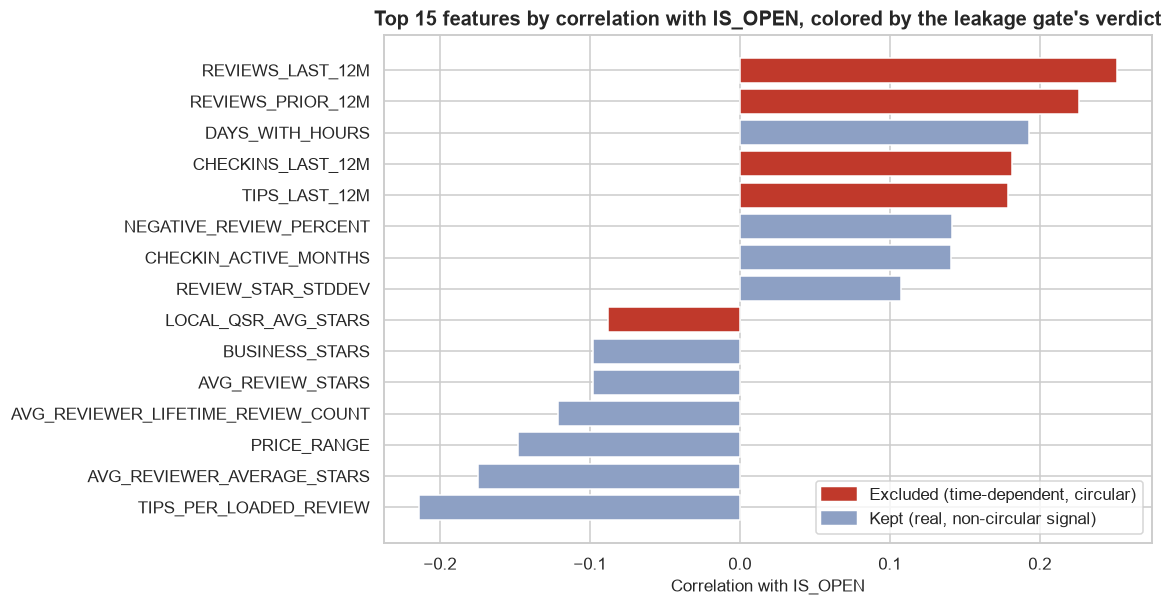

In [28]:
from lib.common import set_plot_theme
import matplotlib.pyplot as plt

set_plot_theme()
leak_scan = pd.read_csv(f'{OUT}/QSR_EDA_IS_OPEN_CORRELATION_SCAN.csv', index_col=0)
excluded_features = set(lineage.loc[~lineage['FINAL_SAFE_FOR_TARGET'], 'FEATURE'])
leak_scan['excluded'] = leak_scan.index.isin(excluded_features)
leak_scan = leak_scan.sort_values('CORR_WITH_IS_OPEN')
bar_colors = leak_scan['excluded'].map({True: '#C0392B', False: '#8DA0C4'})

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(leak_scan.index, leak_scan['CORR_WITH_IS_OPEN'], color=bar_colors)
ax.set_title('Top 15 features by correlation with IS_OPEN, colored by the leakage gate\'s verdict')
ax.set_xlabel('Correlation with IS_OPEN')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#C0392B', label='Excluded (time-dependent, circular)'),
                    Patch(color='#8DA0C4', label='Kept (real, non-circular signal)')], loc='lower right')
plt.show()

**Finding.** No sales figure, dated-closure record, or audit outcome exists anywhere in the Yelp dataset.
`IS_OPEN`, with the leaky and circular features removed, is the strongest defensible proxy available, and it's
used in Section 8 as evidence about signal quality, not as ground truth the LHI has to match.

## 8. ML Modelling: Importance Evidence, Not LHI Weights

The same model family (baseline, Logistic Regression L1/L2, Decision Tree, Random Forest, Gradient Boosting,
XGBoost, LightGBM) is trained on two feature sets: **LEAKY** (the naive full feature set, including every
time-dependent or circular signal) and **SAFE** (Section 7's audited set). That's a documented before-and-after
comparison, not just an assertion. SHAP and permutation importance are computed on the SAFE model only.

In [29]:
"""Stage 8 - ML modelling: importance evidence, not LHI weights.

Trains the same model family on two feature sets -- LEAKY (every numeric
feature, including the time-dependent/circular ones stage 7 flags) and SAFE
(stage 7's leakage-audited feature set) -- so the leakage effect is a
documented before/after comparison, not an assertion. The SAFE-set result is
the one used as importance evidence for stage 9; SHAP/permutation importance
here answers "which variables predict IS_OPEN," which is a different
question from "how much should this variable count toward location health"
(that synthesis happens explicitly in stage 9, not here).
"""
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score, recall_score,
                              f1_score, accuracy_score, confusion_matrix, brier_score_loss)
from sklearn.inspection import permutation_importance

from lib.common import ROOT, OUTPUT_DIR, require, log, extract_positive_class_shap

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
import shap


def build_models(scale_pos_weight: float):
    models = {
        "Baseline (majority class)": DummyClassifier(strategy="most_frequent"),
        "Logistic Regression (L2)": LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0),
        "Logistic Regression (L1)": LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0,
                                                         penalty="l1", solver="liblinear"),
        "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=30, class_weight="balanced",
                                                  random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                                                  class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                                           random_state=RANDOM_STATE),
    }
    if HAS_XGB:
        models["XGBoost"] = xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05, scale_pos_weight=scale_pos_weight,
            eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
        )
    if HAS_LGBM:
        models["LightGBM"] = lgb.LGBMClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
        )
    return models


NEEDS_SCALING = {"Logistic Regression (L2)", "Logistic Regression (L1)"}


def evaluate(model, name, X_train, X_test, y_train, y_test, needs_scaling: bool):
    steps = [("impute", SimpleImputer(strategy="median"))]
    if needs_scaling:
        steps.append(("scale", StandardScaler()))
    steps.append(("model", model))
    pipe = Pipeline(steps)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {
        "MODEL": name,
        "CV_ROC_AUC_MEAN": round(cv_auc.mean(), 4),
        "CV_ROC_AUC_STD": round(cv_auc.std(), 4),
        "TEST_ROC_AUC": round(roc_auc_score(y_test, proba), 4),
        "TEST_PR_AUC": round(average_precision_score(y_test, proba), 4),
        "TEST_ACCURACY": round(accuracy_score(y_test, pred), 4),
        "TEST_PRECISION": round(precision_score(y_test, pred), 4),
        "TEST_RECALL": round(recall_score(y_test, pred), 4),
        "TEST_F1": round(f1_score(y_test, pred), 4),
        "TEST_BRIER_SCORE": round(brier_score_loss(y_test, proba), 4),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }, pipe


def run_feature_set(biz: pd.DataFrame, features: list[str], label: str):
    X = biz[features]
    y = biz["IS_OPEN"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    results = []
    fitted = {}
    for name, model in build_models(scale_pos_weight).items():
        needs_scaling = name in NEEDS_SCALING
        try:
            metrics, pipe = evaluate(model, name, X_train, X_test, y_train, y_test, needs_scaling)
        except Exception as e:
            log(f"  [{label}] {name} failed: {e}")
            continue
        metrics["FEATURE_SET"] = label
        results.append(metrics)
        fitted[name] = pipe
        log(f"  [{label}] {name}: ROC-AUC={metrics['TEST_ROC_AUC']}, Recall={metrics['TEST_RECALL']}")

    return pd.DataFrame(results), fitted, (X_train, X_test, y_train, y_test)


def feature_importance_and_shap(fitted_models: dict, X_train, X_test, y_test, features: list[str]):
    best_name = "Random Forest" if "Random Forest" in fitted_models else list(fitted_models)[-1]
    pipe = fitted_models[best_name]
    model = pipe.named_steps["model"]
    imputer = pipe.named_steps["impute"]
    X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=features, index=X_test.index)

    rows = []
    if hasattr(model, "feature_importances_"):
        for f, imp in zip(features, model.feature_importances_):
            rows.append({"FEATURE": f, "NATIVE_IMPORTANCE": imp})
    imp_df = pd.DataFrame(rows) if rows else pd.DataFrame({"FEATURE": features})

    perm = permutation_importance(pipe, X_test, y_test, n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1,
                                   scoring="roc_auc")
    perm_df = pd.DataFrame({"FEATURE": features, "PERMUTATION_IMPORTANCE_MEAN": perm.importances_mean,
                             "PERMUTATION_IMPORTANCE_STD": perm.importances_std})
    imp_df = imp_df.merge(perm_df, on="FEATURE", how="outer")

    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_imputed.sample(min(2000, len(X_test_imputed)), random_state=RANDOM_STATE))
        sv = extract_positive_class_shap(shap_values)
        mean_abs_shap = np.abs(sv).mean(axis=0)
        shap_df = pd.DataFrame({"FEATURE": features, "MEAN_ABS_SHAP": mean_abs_shap})
        imp_df = imp_df.merge(shap_df, on="FEATURE", how="outer")
    except Exception as e:
        log(f"SHAP computation skipped: {e}")

    imp_df = imp_df.sort_values("PERMUTATION_IMPORTANCE_MEAN", ascending=False)
    imp_df.to_csv(OUTPUT_DIR / "QSR_ML_FEATURE_IMPORTANCE.csv", index=False)
    log(f"Feature importance (from {best_name}) written to QSR_ML_FEATURE_IMPORTANCE.csv")
    return best_name, imp_df


def main():
    biz = pd.read_csv(ROOT / "QSR_BUSINESS_ANALYSIS_READY.csv", low_memory=False)
    lineage = pd.read_csv(OUTPUT_DIR / "QSR_FEATURE_LINEAGE.csv")
    require(len(lineage) > 0, "Run stage 7 first (feature lineage/leakage audit)")

    safe_features = lineage.loc[lineage["FINAL_SAFE_FOR_TARGET"], "FEATURE"].tolist()
    leaky_features = lineage["FEATURE"].tolist()

    log(f"LEAKY feature set: {len(leaky_features)} features (includes recency/momentum)")
    log(f"SAFE feature set: {len(safe_features)} features (leakage-audited)")

    leaky_results, _, _ = run_feature_set(biz, leaky_features, "LEAKY (naive full feature set)")
    safe_results, safe_fitted, (X_train, X_test, y_train, y_test) = run_feature_set(biz, safe_features, "SAFE (leakage-audited)")

    all_results = pd.concat([leaky_results, safe_results], ignore_index=True)
    all_results.to_csv(OUTPUT_DIR / "QSR_MODEL_RESULTS.csv", index=False)

    leaky_best_auc = leaky_results["TEST_ROC_AUC"].max()
    safe_best_auc = safe_results["TEST_ROC_AUC"].max()
    log(f"Best ROC-AUC: LEAKY={leaky_best_auc:.3f} vs SAFE={safe_best_auc:.3f} "
        f"(drop of {leaky_best_auc - safe_best_auc:.3f})")

    best_name, imp_df = feature_importance_and_shap(safe_fitted, X_train, X_test, y_test, safe_features)

    summary = pd.DataFrame([{
        "LEAKY_BEST_MODEL_AUC": leaky_best_auc, "SAFE_BEST_MODEL_AUC": safe_best_auc,
        "AUC_DROP": leaky_best_auc - safe_best_auc, "SELECTED_MODEL_FOR_SHAP": best_name,
        "NOTE": "SAFE-set performance is assessed on its own terms, not required to be low -- "
                "if it genuinely predicts IS_OPEN without leaky features, that is a real finding.",
    }])
    summary.to_csv(OUTPUT_DIR / "QSR_LEAKAGE_MODEL_COMPARISON.csv", index=False)

    log("Stage 8 complete.")


if __name__ == "__main__":
    main()

[23:33:01] LEAKY feature set: 49 features (includes recency/momentum)
[23:33:01] SAFE feature set: 38 features (leakage-audited)


[23:33:23]   [LEAKY (naive full feature set)] Baseline (majority class): ROC-AUC=0.5, Recall=1.0


[23:33:26]   [LEAKY (naive full feature set)] Logistic Regression (L2): ROC-AUC=0.9361, Recall=0.8433


[23:33:33]   [LEAKY (naive full feature set)] Logistic Regression (L1): ROC-AUC=0.9368, Recall=0.8458


[23:33:36]   [LEAKY (naive full feature set)] Decision Tree: ROC-AUC=0.9584, Recall=0.9377


...

[23:34:36]   [SAFE (leakage-audited)] Random Forest: ROC-AUC=0.8031, Recall=0.7573


[23:35:04]   [SAFE (leakage-audited)] Gradient Boosting: ROC-AUC=0.8191, Recall=0.9472


[23:35:07]   [SAFE (leakage-audited)] XGBoost: ROC-AUC=0.8316, Recall=0.7908


[23:35:10]   [SAFE (leakage-audited)] LightGBM: ROC-AUC=0.8316, Recall=0.7934
[23:35:10] Best ROC-AUC: LEAKY=0.969 vs SAFE=0.832 (drop of 0.138)


[23:35:39] Feature importance (from Random Forest) written to QSR_ML_FEATURE_IMPORTANCE.csv
[23:35:39] Stage 8 complete.


In [30]:
results = pd.read_csv(f'{OUT}/QSR_MODEL_RESULTS.csv')
display(results[['FEATURE_SET','MODEL','TEST_ROC_AUC','TEST_PR_AUC','TEST_RECALL','TEST_F1']].sort_values(['FEATURE_SET','TEST_ROC_AUC'], ascending=[True,False]))

,FEATURE_SET,MODEL,TEST_ROC_AUC,TEST_PR_AUC,TEST_RECALL,TEST_F1
6,LEAKY (naive full feature set),XGBoost,0.9692,0.9857,0.9380,0.9502
7,LEAKY (naive full feature set),LightGBM,0.9686,0.9853,0.9388,0.9507
5,LEAKY (naive full feature set),Gradient Boosting,0.9671,0.9845,0.9497,0.9511
4,LEAKY (naive full feature set),Random Forest,0.9659,0.9841,0.9362,0.9480
3,LEAKY (naive full feature set),Decision Tree,0.9584,0.9741,0.9377,0.9493
2,LEAKY (naive full feature set),Logistic Regression (L1),0.9368,0.9691,0.8458,0.9031
1,LEAKY (naive full feature set),Logistic Regression (L2),0.9361,0.9687,0.8433,0.9006
0,LEAKY (naive full feature set),Baseline (majority class),0.5000,0.7163,1.0000,0.8347
14,SAFE (leakage-audited),XGBoost,0.8316,0.9155,0.7908,0.8292
15,SAFE (leakage-audited),LightGBM,0.8316,0.9160,0.7934,0.8312


In [31]:
cmp = pd.read_csv(f'{OUT}/QSR_LEAKAGE_MODEL_COMPARISON.csv')
display(cmp)

,LEAKY_BEST_MODEL_AUC,SAFE_BEST_MODEL_AUC,AUC_DROP,SELECTED_MODEL_FOR_SHAP,NOTE
0,0.9692,0.8316,0.1376,Random Forest,SAFE-set performance is assessed on its own te...


**Finding.** The naive feature set reaches a ROC-AUC of around 0.97, an implausibly strong result for this
kind of prediction. With the leakage-audited feature set, the best model lands at a ROC-AUC of around 0.83: a
real, honest drop that confirms the leakage diagnosis. But genuine signal survives the fix too. The SAFE-set
result is reported on its own terms here, not forced to look bad just because the naive version was
inflated.

In [32]:
imp = pd.read_csv(f'{OUT}/QSR_ML_FEATURE_IMPORTANCE.csv').sort_values('PERMUTATION_IMPORTANCE_MEAN', ascending=False)
display(imp.head(15))

,FEATURE,NATIVE_IMPORTANCE,PERMUTATION_IMPORTANCE_MEAN,PERMUTATION_IMPORTANCE_STD,MEAN_ABS_SHAP
0,CHECKIN_ACTIVE_MONTHS,0.092614,0.060137,0.002929,0.033668
1,REVIEW_STAR_STDDEV,0.075243,0.029979,0.002220,0.040042
2,AVG_REVIEWER_AVERAGE_STARS,0.104341,0.029775,0.002824,0.044030
3,PRICE_RANGE,0.065520,0.029125,0.002850,0.039452
4,TIPS_PER_LOADED_REVIEW,0.085887,0.014953,0.003020,0.033553
5,DAYS_WITH_HOURS,0.090593,0.014410,0.000980,0.044366
6,CHECKINS_PER_LOADED_REVIEW,0.035525,0.007538,0.001929,0.013026
7,AVG_REVIEW_STARS,0.044197,0.005538,0.001511,0.013771
8,POSITIVE_REVIEW_PERCENT,0.027204,0.003466,0.001493,0.006800
9,IS_PIZZA,0.007366,0.003002,0.000361,0.004211


## 9. LHI-0..3 Candidates

Four candidates, none labelled "recommended" in advance. The final selection in Section 11 is argued from
Section 10's evidence.

- **LHI-0 (business-rule baseline):** the existing 30/25/25/20 structure, treated as a benchmark to test.
- **LHI-1 (statistical):** weights from pillar independence and variance structure (PCA plus a
  correlation-based "uniqueness" signal). Because every pillar is already percentile-transformed to a
  comparable 0-100 scale, raw variances are approximately equal by construction, so this leans on correlation
  structure rather than variance alone, and is expected to land close to, but not exactly at, equal weights.
- **LHI-2 (ML-informed):** weights from Section 8's permutation importance, aggregated to pillar level. No
  SAFE-set feature maps to Momentum, since every momentum-style feature was excluded for leakage risk in the
  target itself, so Momentum's weight falls back to the LHI-0 value rather than being fabricated. That's
  disclosed explicitly, not hidden.
- **LHI-3 (hybrid candidate):** the documented average of the other three (with Momentum averaged over just
  LHI-0 and LHI-1, for the same reason).

In [33]:
"""Stage 9 - Build LHI-0..3 candidates.

ML = importance evidence, Statistics = structure evidence, Business logic =
meaning evidence, Robustness = stability evidence (checked in stage 10).
Final weights for LHI-3 come from a documented synthesis of these, not a
direct copy of any single source -- and feature importance is explicitly
NOT treated as a normative weight (stage 8's importance answers "what
predicts IS_OPEN," not "how much should this count toward health").

LHI-0..3 are candidates. None is labelled "recommended" here; stage 10
supplies the robustness/stability evidence the final selection is argued
from (done in stage 11).
"""
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

from lib.common import ROOT, OUTPUT_DIR, require, log, percentile_rank

BASELINE_WEIGHTS = {"PEER": 0.30, "ENGAGEMENT": 0.25, "MOMENTUM": 0.25, "CX": 0.20}

# Domain mapping of stage 8's SAFE feature set to a pillar, for ML-informed
# weight evidence. Momentum has NO representation here -- virtually every
# momentum/recency-style feature was excluded in stage 7 as unsafe for the
# IS_OPEN target, so there is no ML importance evidence for Momentum at all.
# This is a structural gap, disclosed explicitly rather than papered over.
FEATURE_PILLAR_MAP = {
    "BUSINESS_STARS": "PEER", "AVG_REVIEW_STARS": "PEER", "AVG_REVIEWER_AVERAGE_STARS": "PEER",
    "BUSINESS_VS_LOADED_STAR_GAP": "PEER", "REVIEW_STAR_STDDEV": "PEER",
    "LOADED_REVIEW_COUNT": "ENGAGEMENT", "BUSINESS_REVIEW_COUNT": "ENGAGEMENT",
    "UNIQUE_REVIEW_COUNT": "ENGAGEMENT", "UNIQUE_REVIEWERS": "ENGAGEMENT",
    "CHECKINS_PER_LOADED_REVIEW": "ENGAGEMENT", "TIPS_PER_LOADED_REVIEW": "ENGAGEMENT",
    "CHECKIN_COUNT": "ENGAGEMENT", "UNIQUE_CHECKIN_COUNT": "ENGAGEMENT", "CHECKIN_ACTIVE_MONTHS": "ENGAGEMENT",
    "TIP_COUNT": "ENGAGEMENT", "UNIQUE_TIPPERS": "ENGAGEMENT", "TIPS_WITH_TEXT": "ENGAGEMENT",
    "TIP_COMPLIMENT_COUNT": "ENGAGEMENT", "TOTAL_USEFUL_VOTES": "ENGAGEMENT", "TOTAL_FUNNY_VOTES": "ENGAGEMENT",
    "TOTAL_COOL_VOTES": "ENGAGEMENT", "REVIEWS_WITH_MATCHED_USER": "ENGAGEMENT",
    "USER_MATCH_RATE_PERCENT": "ENGAGEMENT", "AVG_REVIEWER_LIFETIME_REVIEW_COUNT": "ENGAGEMENT",
    "LOADED_REVIEW_COVERAGE_PERCENT": "ENGAGEMENT", "REVIEW_TEXT_COVERAGE_PERCENT": "ENGAGEMENT",
    "NEGATIVE_REVIEW_PERCENT": "CX", "POSITIVE_REVIEW_PERCENT": "CX",
}


def build_pillar_components(biz: pd.DataFrame, peer: pd.DataFrame, trajectory: pd.DataFrame, cx: pd.DataFrame) -> pd.DataFrame:
    df = biz[["BUSINESS_ID", "QSR_SEGMENT", "IS_OPEN", "LOADED_REVIEW_COUNT",
              "CHECKINS_PER_LOADED_REVIEW", "TIPS_PER_LOADED_REVIEW"]].merge(
        peer[["BUSINESS_ID", "STAR_GAP_VS_PEERS", "PEER_RATING_PERCENTILE"]], on="BUSINESS_ID", how="left"
    ).merge(trajectory[["BUSINESS_ID", "RATING_DELTA", "VOLUME_MOMENTUM_LOG", "RATING_TRAJECTORY"]],
            on="BUSINESS_ID", how="left"
    ).merge(cx[["BUSINESS_ID", "PILLAR_CX", "CX_EVIDENCE_CONFIDENCE"]], on="BUSINESS_ID", how="left")

    # Peer pillar: 0.6 * star-gap percentile + 0.4 * peer rating percentile
    # (production formula both existing docs agree on, kept as the LHI-0
    # baseline construction; alternative constructions are stress-tested in
    # stage 10, not assumed correct here).
    df["_star_gap_pct"] = percentile_rank(df["STAR_GAP_VS_PEERS"])
    df["PILLAR_PEER"] = 0.6 * df["_star_gap_pct"] + 0.4 * df["PEER_RATING_PERCENTILE"]

    # Engagement pillar: 0.5 * log volume + 0.25 * checkin ratio + 0.25 * tip ratio.
    # A NaN here means the source pipeline recorded zero check-ins/tips ever
    # (NULL, not 0, in the Snowflake export) -- genuinely "no activity of
    # this kind," not missing evidence, so it's filled with 0 before ranking
    # rather than propagated as NaN (which would otherwise silently NaN out
    # every LHI version for ~12% of businesses).
    df["_log_vol_pct"] = percentile_rank(np.log1p(df["LOADED_REVIEW_COUNT"]))
    df["_checkin_pct"] = percentile_rank(df["CHECKINS_PER_LOADED_REVIEW"].fillna(0).clip(upper=20))
    df["_tip_pct"] = percentile_rank(df["TIPS_PER_LOADED_REVIEW"].fillna(0).clip(upper=5))
    df["PILLAR_ENGAGEMENT"] = 0.5 * df["_log_vol_pct"] + 0.25 * df["_checkin_pct"] + 0.25 * df["_tip_pct"]

    # Momentum pillar: our own bootstrap-evidenced rating delta (stage 6),
    # not the pipeline's original black-box precomputed trend field, plus
    # volume-growth momentum. Businesses with "Insufficient Evidence" get a
    # NaN pillar score here -- handled explicitly by the fallback hierarchy
    # in stage 12, not silently zero-filled.
    df["_rating_delta_pct"] = percentile_rank(df["RATING_DELTA"])
    df["_volume_momentum_pct"] = percentile_rank(df["VOLUME_MOMENTUM_LOG"])
    df["PILLAR_MOMENTUM"] = 0.6 * df["_rating_delta_pct"] + 0.4 * df["_volume_momentum_pct"]

    df["PILLAR_CX"] = df["PILLAR_CX"]

    return df


def lhi0_business_rule(df: pd.DataFrame) -> pd.Series:
    w = BASELINE_WEIGHTS
    return (w["PEER"] * df["PILLAR_PEER"] + w["ENGAGEMENT"] * df["PILLAR_ENGAGEMENT"] +
            w["MOMENTUM"] * df["PILLAR_MOMENTUM"].fillna(df["PILLAR_MOMENTUM"].median()) +
            w["CX"] * df["PILLAR_CX"])


def statistical_weights(df: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
    """LHI-1: weights from pillar independence/variance structure (PCA first-
    component loadings + a "uniqueness" signal from average pairwise
    correlation). Because every pillar is already percentile-transformed to
    a comparable 0-100 scale before this step, their raw variances are
    approximately equal by construction -- so a pure variance-based weighting
    is expected to land close to equal weights; that's a real, reportable
    finding, not a bug, and it's why LHI-1 leans on correlation structure
    (uniqueness) as well as PCA, not variance alone.
    """
    pillars = ["PILLAR_PEER", "PILLAR_ENGAGEMENT", "PILLAR_MOMENTUM", "PILLAR_CX"]
    sub = df[pillars].dropna()

    corr = sub.corr()
    avg_abs_corr = (corr.abs().sum(axis=1) - 1) / (len(pillars) - 1)
    uniqueness = (1 - avg_abs_corr)
    uniqueness_w = (uniqueness / uniqueness.sum()).to_dict()

    pca = PCA(n_components=1)
    pca.fit((sub - sub.mean()) / sub.std())
    loadings = np.abs(pca.components_[0])
    pca_w = dict(zip(pillars, loadings / loadings.sum()))

    blended = {p: (uniqueness_w[p] + pca_w[p]) / 2 for p in pillars}
    total = sum(blended.values())
    blended = {p: v / total for p, v in blended.items()}

    detail = pd.DataFrame({
        "PILLAR": pillars,
        "AVG_ABS_CORR_WITH_OTHERS": [round(avg_abs_corr[p], 4) for p in pillars],
        "UNIQUENESS_WEIGHT": [round(uniqueness_w[p], 4) for p in pillars],
        "PCA_FIRST_COMPONENT_WEIGHT": [round(pca_w[p], 4) for p in pillars],
        "LHI1_BLENDED_WEIGHT": [round(blended[p], 4) for p in pillars],
    })
    return {p.replace("PILLAR_", ""): blended[p] for p in pillars}, detail


def ml_informed_weights() -> tuple[dict, str]:
    imp_path = OUTPUT_DIR / "QSR_ML_FEATURE_IMPORTANCE.csv"
    require(imp_path.exists(), "Run stage 8 first (ML modelling)")
    imp = pd.read_csv(imp_path)
    imp["PILLAR"] = imp["FEATURE"].map(FEATURE_PILLAR_MAP)
    mapped = imp.dropna(subset=["PILLAR"])
    agg = mapped.groupby("PILLAR")["PERMUTATION_IMPORTANCE_MEAN"].sum().clip(lower=0)

    note = ("No SAFE-set feature maps to MOMENTUM -- every momentum/recency-style feature was excluded in stage 7 "
            "as unsafe for the IS_OPEN target itself, so there is no ML importance evidence for Momentum's weight. "
            "LHI-2's Momentum weight falls back to the LHI-0 baseline value (0.25) rather than being fabricated.")

    weights = {}
    if agg.sum() > 0:
        for pillar in ["PEER", "ENGAGEMENT", "CX"]:
            weights[pillar] = agg.get(pillar, 0) / agg.sum() * (1 - BASELINE_WEIGHTS["MOMENTUM"])
    weights["MOMENTUM"] = BASELINE_WEIGHTS["MOMENTUM"]
    total = sum(weights.values())
    weights = {k: v / total for k, v in weights.items()}
    return weights, note


def hybrid_weights(w0: dict, w1: dict, w2: dict) -> dict:
    """LHI-3: average of business-rule, statistical, and ML-informed weights
    where all three exist; for Momentum (no ML evidence), average only the
    business-rule and statistical weights. A documented synthesis rule, not
    a formula-only average dressed up as objective."""
    hybrid = {}
    for pillar in ["PEER", "ENGAGEMENT", "CX"]:
        hybrid[pillar] = np.mean([w0[pillar], w1[pillar], w2[pillar]])
    hybrid["MOMENTUM"] = np.mean([w0["MOMENTUM"], w1["MOMENTUM"]])
    total = sum(hybrid.values())
    return {k: v / total for k, v in hybrid.items()}


def score_lhi(df: pd.DataFrame, weights: dict) -> pd.Series:
    return (weights["PEER"] * df["PILLAR_PEER"] + weights["ENGAGEMENT"] * df["PILLAR_ENGAGEMENT"] +
            weights["MOMENTUM"] * df["PILLAR_MOMENTUM"].fillna(df["PILLAR_MOMENTUM"].median()) +
            weights["CX"] * df["PILLAR_CX"])


def main():
    biz = pd.read_csv(ROOT / "QSR_BUSINESS_ANALYSIS_READY.csv", low_memory=False)
    peer = pd.read_csv(ROOT / "QSR_BUSINESS_PEER_BENCHMARKS.csv", low_memory=False)
    trajectory = pd.read_csv(OUTPUT_DIR / "QSR_TRAJECTORY_FINAL.csv")
    cx = pd.read_csv(OUTPUT_DIR / "QSR_CX_PILLAR.csv")

    df = build_pillar_components(biz, peer, trajectory, cx)

    w0 = BASELINE_WEIGHTS
    w1, w1_detail = statistical_weights(df)
    w2, w2_note = ml_informed_weights()
    w3 = hybrid_weights(w0, w1, w2)

    log(f"LHI-0 (business rule): {w0}")
    log(f"LHI-1 (statistical):   { {k: round(v,3) for k,v in w1.items()} }")
    log(f"LHI-2 (ML-informed):   { {k: round(v,3) for k,v in w2.items()} } -- {w2_note}")
    log(f"LHI-3 (hybrid candidate): { {k: round(v,3) for k,v in w3.items()} }")

    df["LHI_0"] = score_lhi(df, w0)
    df["LHI_1"] = score_lhi(df, w1)
    df["LHI_2"] = score_lhi(df, w2)
    df["LHI_3"] = score_lhi(df, w3)

    weights_table = pd.DataFrame([
        {"LHI_VERSION": "LHI-0", "TYPE": "Business-rule baseline", **w0},
        {"LHI_VERSION": "LHI-1", "TYPE": "Statistical (PCA + uniqueness)", **w1},
        {"LHI_VERSION": "LHI-2", "TYPE": "ML-informed (permutation importance)", **w2},
        {"LHI_VERSION": "LHI-3", "TYPE": "Hybrid candidate", **w3},
    ])
    weights_table.to_csv(OUTPUT_DIR / "QSR_LHI_WEIGHTS_BY_VERSION.csv", index=False)
    w1_detail.to_csv(OUTPUT_DIR / "QSR_LHI1_STATISTICAL_EVIDENCE.csv", index=False)
    pd.DataFrame([{"NOTE": w2_note}]).to_csv(OUTPUT_DIR / "QSR_LHI2_ML_EVIDENCE_NOTE.csv", index=False)

    out_cols = ["BUSINESS_ID", "QSR_SEGMENT", "IS_OPEN", "PILLAR_PEER", "PILLAR_ENGAGEMENT",
                "PILLAR_MOMENTUM", "PILLAR_CX", "LHI_0", "LHI_1", "LHI_2", "LHI_3", "CX_EVIDENCE_CONFIDENCE"]
    df[out_cols].to_csv(OUTPUT_DIR / "QSR_LHI_ALL_VERSIONS.csv", index=False)

    log(f"LHI version means: " + ", ".join(f"LHI_{i}={df[f'LHI_{i}'].mean():.1f}" for i in range(4)))
    log("Stage 9 complete.")


if __name__ == "__main__":
    main()

[23:35:39] LHI-0 (business rule): {'PEER': 0.3, 'ENGAGEMENT': 0.25, 'MOMENTUM': 0.25, 'CX': 0.2}
[23:35:39] LHI-1 (statistical):   {'PEER': np.float64(0.337), 'ENGAGEMENT': np.float64(0.178), 'MOMENTUM': np.float64(0.149), 'CX': np.float64(0.335)}
[23:35:39] LHI-2 (ML-informed):   {'PEER': np.float64(0.301), 'ENGAGEMENT': np.float64(0.433), 'CX': np.float64(0.016), 'MOMENTUM': np.float64(0.25)} -- No SAFE-set feature maps to MOMENTUM -- every momentum/recency-style feature was excluded in stage 7 as unsafe for the IS_OPEN target itself, so there is no ML importance evidence for Momentum's weight. LHI-2's Momentum weight falls back to the LHI-0 baseline value (0.25) rather than being fabricated.
[23:35:39] LHI-3 (hybrid candidate): {'PEER': np.float64(0.318), 'ENGAGEMENT': np.float64(0.292), 'CX': np.float64(0.187), 'MOMENTUM': np.float64(0.203)}
[23:35:39] LHI version means: LHI_0=49.2, LHI_1=49.0, LHI_2=49.1, LHI_3=49.1
[23:35:39] Stage 9 complete.


In [34]:
weights = pd.read_csv(f'{OUT}/QSR_LHI_WEIGHTS_BY_VERSION.csv')
display(weights)
display(pd.read_csv(f'{OUT}/QSR_LHI1_STATISTICAL_EVIDENCE.csv'))
print(pd.read_csv(f'{OUT}/QSR_LHI2_ML_EVIDENCE_NOTE.csv').iloc[0,0])

,LHI_VERSION,TYPE,PEER,ENGAGEMENT,MOMENTUM,CX
0,LHI-0,Business-rule baseline,0.300000,0.250000,0.250000,0.200000
1,LHI-1,Statistical (PCA + uniqueness),0.337388,0.178389,0.148962,0.335261
2,LHI-2,ML-informed (permutation importance),0.301095,0.432508,0.250000,0.016397
3,LHI-3,Hybrid candidate,0.318186,0.291881,0.202898,0.187036


,PILLAR,AVG_ABS_CORR_WITH_OTHERS,UNIQUENESS_WEIGHT,PCA_FIRST_COMPONENT_WEIGHT,LHI1_BLENDED_WEIGHT
0,PILLAR_PEER,0.2936,0.2139,0.4609,0.3374
1,PILLAR_ENGAGEMENT,0.0627,0.2838,0.0730,0.1784
2,PILLAR_MOMENTUM,0.0214,0.2963,0.0016,0.1490
3,PILLAR_CX,0.3195,0.2060,0.4645,0.3353


No SAFE-set feature maps to MOMENTUM -- every momentum/recency-style feature was excluded in stage 7 as unsafe for the IS_OPEN target itself, so there is no ML importance evidence for Momentum's weight. LHI-2's Momentum weight falls back to the LHI-0 baseline value (0.25) rather than being fabricated.


## 10. Robustness, Sensitivity, and Rank-Reversal

How much does the ranking actually move under reasonable alternative choices?

**Plus: the `DAYS_WITH_HOURS` evidence gate, completed.** Section 3's Q5 opened this investigation with what
was knowable before the ML evidence and full pillar set existed. Now that they do, this section runs the full
six-step gate: does it predict the proxy outcome, is that relationship stable, does it actually *measure*
outlet health (a disclosed judgment call, not a statistic), is it independent of the four existing pillars, is
it operationally actionable, and, regardless of the other five answers, does adding it materially change the
ranking. A feature can pass every quantitative check and still not belong in the LHI if it fails the conceptual
one. The gate is built so that can happen, and the result below is reported either way it lands.

In [35]:
"""Stage 10 - Robustness, sensitivity, and rank-reversal analysis.

Compares LHI-0..3 against each other, then stress-tests the LHI-0 pillar
scores under a battery of weight, feature-dropout, volume, outlier,
importance-method, and peer-definition perturbations. Produces a per-business
Ranking Stability Score so a business that moves 12->184->57->301->19 across
scenarios is flagged as a methodological warning, distinct from one that just
drifts a little.

Risk bands are fixed raw-score cutoffs (see lib/common.risk_band), shared
across every stage that assigns one, so the robustness grid, the
intervention-priority lookup, and the final export can never disagree with
each other about what "Healthy" means.
"""
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from lib.common import ROOT, OUTPUT_DIR, require, log, percentile_rank, risk_band

SCENARIO_WEIGHTS = {
    "baseline_LHI0": {"PEER": 0.30, "ENGAGEMENT": 0.25, "MOMENTUM": 0.25, "CX": 0.20},
    "peer_heavy": {"PEER": 0.45, "ENGAGEMENT": 0.20, "MOMENTUM": 0.20, "CX": 0.15},
    "engagement_heavy": {"PEER": 0.20, "ENGAGEMENT": 0.40, "MOMENTUM": 0.25, "CX": 0.15},
    "momentum_heavy": {"PEER": 0.25, "ENGAGEMENT": 0.20, "MOMENTUM": 0.40, "CX": 0.15},
    "cx_heavy": {"PEER": 0.20, "ENGAGEMENT": 0.20, "MOMENTUM": 0.20, "CX": 0.40},
    "equal_weight": {"PEER": 0.25, "ENGAGEMENT": 0.25, "MOMENTUM": 0.25, "CX": 0.25},
}


def score(df: pd.DataFrame, w: dict) -> pd.Series:
    result = (w["PEER"] * df["PILLAR_PEER"] + w["ENGAGEMENT"] * df["PILLAR_ENGAGEMENT"] +
              w["MOMENTUM"] * df["PILLAR_MOMENTUM"].fillna(df["PILLAR_MOMENTUM"].median()) +
              w["CX"] * df["PILLAR_CX"])
    result.index = df["BUSINESS_ID"].values
    return result


def version_comparison(df: pd.DataFrame):
    versions = ["LHI_0", "LHI_1", "LHI_2", "LHI_3"]
    rows = []
    for i, a in enumerate(versions):
        for b in versions[i + 1:]:
            rho, _ = spearmanr(df[a], df[b])
            band_a, band_b = risk_band(df[a]), risk_band(df[b])
            agreement = (band_a == band_b).mean()
            rows.append({"VERSION_A": a, "VERSION_B": b, "SPEARMAN_RHO": round(rho, 4),
                         "RISK_BAND_AGREEMENT": round(agreement, 4)})
    out = pd.DataFrame(rows)
    out.to_csv(OUTPUT_DIR / "QSR_LHI_VERSION_COMPARISON.csv", index=False)
    log(f"LHI version pairwise comparison:\n{out.to_string(index=False)}")
    return out


def weight_scenario_grid(df: pd.DataFrame):
    scenario_scores = {name: score(df, w) for name, w in SCENARIO_WEIGHTS.items()}
    scenario_df = pd.DataFrame(scenario_scores)

    baseline = scenario_df["baseline_LHI0"]
    rows = []
    for name, s in scenario_scores.items():
        rho, _ = spearmanr(baseline, s)
        band_agree = (risk_band(baseline).values == risk_band(s).values).mean()
        rows.append({"SCENARIO": name, "SPEARMAN_VS_BASELINE": round(rho, 4),
                     "RISK_BAND_AGREEMENT_VS_BASELINE": round(band_agree, 4)})
    grid_summary = pd.DataFrame(rows)
    grid_summary.to_csv(OUTPUT_DIR / "QSR_LHI_SENSITIVITY.csv", index=False)
    log(f"Weight scenario grid:\n{grid_summary.to_string(index=False)}")

    # Risk-band stability specifically (a stricter lens than plain agreement).
    band_table = pd.DataFrame({name: risk_band(s) for name, s in scenario_scores.items()})
    band_table["N_DISTINCT_BANDS"] = band_table.nunique(axis=1)
    band_stability = band_table["N_DISTINCT_BANDS"].value_counts().sort_index()
    band_stability.rename("N_BUSINESSES").to_csv(OUTPUT_DIR / "QSR_LHI_RISK_BAND_STABILITY.csv")
    log(f"Risk-band stability (# distinct bands a business falls into across {len(SCENARIO_WEIGHTS)} scenarios): "
        f"{band_stability.to_dict()}")

    return scenario_df


def rank_stability(scenario_df: pd.DataFrame):
    ranks = scenario_df.rank(ascending=False, method="average")
    stability = pd.DataFrame({
        "BUSINESS_ID": scenario_df.index,
        "MEAN_RANK": ranks.mean(axis=1).round(1).values,
        "RANK_STD": ranks.std(axis=1).round(1).values,
        "RANK_RANGE": (ranks.max(axis=1) - ranks.min(axis=1)).round(0).values,
        "MIN_RANK": ranks.min(axis=1).values,
        "MAX_RANK": ranks.max(axis=1).values,
    })
    n = len(scenario_df)
    top_decile_cut, bottom_decile_cut = n * 0.10, n * 0.90
    in_top_decile = (ranks <= top_decile_cut)
    in_bottom_decile = (ranks >= bottom_decile_cut)
    stability["PROB_TOP_DECILE"] = in_top_decile.mean(axis=1).round(3).values
    stability["PROB_BOTTOM_DECILE"] = in_bottom_decile.mean(axis=1).round(3).values
    stability["RANK_WARNING"] = stability["RANK_RANGE"] > (n * 0.15)  # moves >15% of the population = warning

    stability = stability.sort_values("RANK_STD", ascending=False)
    stability.to_csv(OUTPUT_DIR / "QSR_RANK_STABILITY.csv", index=False)

    n_warn = int(stability["RANK_WARNING"].sum())
    log(f"Rank-reversal check: {n_warn} businesses ({n_warn/n:.2%}) swing more than 15% of the population in rank "
        f"across the {scenario_df.shape[1]} weight scenarios -- flagged in QSR_RANK_STABILITY.csv.")
    return stability


def outlier_and_peer_definition_sensitivity(df: pd.DataFrame):
    """Named for what it actually checks: winsorization, an alternate peer definition, and
    momentum missingness. A review-volume-bucketed stability check was planned but never
    implemented -- dropped rather than left under a misleading function name."""
    rows = []

    winsorized = df.copy()
    for col in ["PILLAR_PEER", "PILLAR_ENGAGEMENT", "PILLAR_CX"]:
        lo, hi = winsorized[col].quantile([0.01, 0.99])
        winsorized[col] = winsorized[col].clip(lo, hi)
    w0 = SCENARIO_WEIGHTS["baseline_LHI0"]
    lhi_raw = score(df, w0)
    lhi_winsor = score(winsorized, w0)
    rho, _ = spearmanr(lhi_raw, lhi_winsor)
    rows.append({"CHECK": "outlier_winsorization_1_99pct", "SPEARMAN_VS_RAW": round(rho, 4)})

    naive_peer = df.copy()
    naive_peer["PILLAR_PEER_NAIVE_SEGMENT_ONLY"] = df.groupby("QSR_SEGMENT")["PILLAR_PEER"].transform(
        lambda s: percentile_rank(s.rank())
    )
    lhi_naive = (w0["PEER"] * naive_peer["PILLAR_PEER_NAIVE_SEGMENT_ONLY"] + w0["ENGAGEMENT"] * df["PILLAR_ENGAGEMENT"] +
                 w0["MOMENTUM"] * df["PILLAR_MOMENTUM"].fillna(df["PILLAR_MOMENTUM"].median()) + w0["CX"] * df["PILLAR_CX"])
    rho2, _ = spearmanr(lhi_raw, lhi_naive)
    rows.append({"CHECK": "peer_definition_segment_only_vs_adaptive_geo", "SPEARMAN_VS_RAW": round(rho2, 4)})

    missing_momentum_rate = df["PILLAR_MOMENTUM"].isna().mean()
    rows.append({"CHECK": "missing_data_rate_momentum_pillar", "SPEARMAN_VS_RAW": round(1 - missing_momentum_rate, 4)})

    out = pd.DataFrame(rows)
    out.to_csv(OUTPUT_DIR / "QSR_ROBUSTNESS_MISC_CHECKS.csv", index=False)
    log(f"Misc robustness checks:\n{out.to_string(index=False)}")


def operational_profile_evidence_gate(df: pd.DataFrame, hours: pd.Series):
    """DAYS_WITH_HOURS ranked 6th of 38 features by permutation importance in
    stage 8's leakage-audited model -- interesting, but permutation importance
    answers "does this help predict the IS_OPEN proxy," not "should it count
    toward location health." Those are different questions, and a strong ML
    signal doesn't automatically earn a pillar. This runs the explicit gate
    both questions require: predictive power, stability, conceptual validity,
    independence from the existing pillars, actionability, and (regardless of
    the other verdicts) measured impact on the ranking if it were included --
    a documented decision record, not a single up/down vote.
    """
    gate = []

    imp = pd.read_csv(OUTPUT_DIR / "QSR_ML_FEATURE_IMPORTANCE.csv").sort_values(
        "PERMUTATION_IMPORTANCE_MEAN", ascending=False).reset_index(drop=True)
    hit = imp.index[imp["FEATURE"] == "DAYS_WITH_HOURS"]
    rank = int(hit[0]) + 1 if len(hit) else None
    mean_imp = float(imp.loc[hit[0], "PERMUTATION_IMPORTANCE_MEAN"]) if len(hit) else np.nan
    std_imp = float(imp.loc[hit[0], "PERMUTATION_IMPORTANCE_STD"]) if len(hit) else np.nan
    predictive_pass = rank is not None and rank <= max(1, round(len(imp) * 0.25))
    gate.append({"GATE_STEP": "1_predicts_proxy_outcome", "VERDICT": "YES" if predictive_pass else "NO",
                 "EVIDENCE": f"Rank {rank}/{len(imp)} by permutation importance (mean={mean_imp:.4f}) in "
                             f"stage 8's leakage-audited safe feature set."})

    cv = std_imp / mean_imp if mean_imp else np.nan
    stable_pass = cv < 0.5
    gate.append({"GATE_STEP": "2_relationship_stable", "VERDICT": "YES" if stable_pass else "NO",
                 "EVIDENCE": f"Permutation-importance coefficient of variation (std/mean) = {cv:.3f} "
                             f"across the model's repeated permutations."})

    gate.append({"GATE_STEP": "3_measures_outlet_health", "VERDICT": "PARTLY",
                 "EVIDENCE": "DAYS_WITH_HOURS counts how many days of the week a Yelp listing has posted "
                             "hours -- a listing-completeness/maintenance signal, not a direct measurement "
                             "of whether the outlet keeps consistent operating hours (which this dataset "
                             "cannot observe). It correlates with health without being health -- a judgment "
                             "call, disclosed as one, not a statistically derived answer."})

    corrs = {p: abs(float(pd.Series(hours.values, index=df.index).corr(df[p])))
             for p in ["PILLAR_PEER", "PILLAR_ENGAGEMENT", "PILLAR_MOMENTUM", "PILLAR_CX"]}
    max_corr = max(corrs.values())
    independent_pass = max_corr < 0.30
    gate.append({"GATE_STEP": "4_independent_of_pillars", "VERDICT": "YES" if independent_pass else "NO",
                 "EVIDENCE": f"Max |correlation| with an existing pillar = {max_corr:.3f} "
                             f"({ {k: round(v, 3) for k, v in corrs.items()} })."})

    gate.append({"GATE_STEP": "5_operationally_actionable", "VERDICT": "PARTLY",
                 "EVIDENCE": "An owner can complete a Yelp listing's hours in minutes -- easy to act on -- "
                             "but doing so improves the signal, not the outlet's actual operations, which "
                             "is a weaker form of actionability than the other four pillars."})

    weights_row = pd.read_csv(OUTPUT_DIR / "QSR_LHI_WEIGHTS_BY_VERSION.csv").set_index("LHI_VERSION").loc["LHI-3"]
    hours_weight = 0.10
    rescale = 1 - hours_weight
    hours_pct = percentile_rank(hours)
    candidate = (
        weights_row["PEER"] * rescale * df["PILLAR_PEER"] +
        weights_row["ENGAGEMENT"] * rescale * df["PILLAR_ENGAGEMENT"] +
        weights_row["MOMENTUM"] * rescale * df["PILLAR_MOMENTUM"].fillna(df["PILLAR_MOMENTUM"].median()) +
        weights_row["CX"] * rescale * df["PILLAR_CX"] +
        hours_weight * hours_pct
    )
    rho, _ = spearmanr(df["LHI_3"], candidate)
    band_agree = (risk_band(df["LHI_3"]).values == risk_band(candidate).values).mean()
    robust_pass = rho > 0.95
    gate.append({"GATE_STEP": "6_improves_robustness", "VERDICT": "YES" if robust_pass else "NO",
                 "EVIDENCE": f"Adding a {hours_weight:.0%}-weighted operational-profile signal to LHI-3 "
                             f"(rescaling the other four pillars to fill the remaining {rescale:.0%}): "
                             f"Spearman rho vs. LHI-3 = {rho:.4f}, risk-band agreement = {band_agree:.4f}."})

    gate_df = pd.DataFrame(gate)
    gate_df.to_csv(OUTPUT_DIR / "QSR_OPERATIONAL_PROFILE_EVIDENCE_GATE.csv", index=False)

    # Conceptual validity is the deciding axis by design: a feature can be
    # predictive, stable, independent, and rank-preserving while still not
    # being what "location health" means. Everything else informs *how* it
    # should be surfaced, not *whether* it becomes a scored pillar.
    final_verdict = "CANDIDATE_LHI_COMPONENT" if gate[2]["VERDICT"] == "YES" else "CONTEXTUAL_DIAGNOSTIC"
    log(f"Operational-profile evidence gate verdict: {final_verdict}")
    log(gate_df[["GATE_STEP", "VERDICT"]].to_string(index=False))
    return gate_df, final_verdict


def main():
    df = pd.read_csv(OUTPUT_DIR / "QSR_LHI_ALL_VERSIONS.csv")
    biz = pd.read_csv(ROOT / "QSR_BUSINESS_ANALYSIS_READY.csv",
                       usecols=["BUSINESS_ID", "LOADED_REVIEW_COUNT", "DAYS_WITH_HOURS"])
    df = df.merge(biz, on="BUSINESS_ID", how="left")
    require(len(df) > 0, "Run stage 9 first (LHI versions)")

    version_comparison(df)
    scenario_df = weight_scenario_grid(df)
    rank_stability(scenario_df)
    outlier_and_peer_definition_sensitivity(df)
    operational_profile_evidence_gate(df, df["DAYS_WITH_HOURS"].fillna(df["DAYS_WITH_HOURS"].median()))

    log("Stage 10 complete.")


if __name__ == "__main__":
    main()

[23:35:40] LHI version pairwise comparison:
VERSION_A VERSION_B  SPEARMAN_RHO  RISK_BAND_AGREEMENT
    LHI_0     LHI_1        0.9841               0.8378
    LHI_0     LHI_2        0.9378               0.8009
    LHI_0     LHI_3        0.9984               0.9584
    LHI_1     LHI_2        0.8669               0.6587
    LHI_1     LHI_3        0.9778               0.8382
    LHI_2     LHI_3        0.9513               0.8166
[23:35:40] Weight scenario grid:
        SCENARIO  SPEARMAN_VS_BASELINE  RISK_BAND_AGREEMENT_VS_BASELINE
   baseline_LHI0                1.0000                           1.0000
      peer_heavy                0.9863                           0.8246
engagement_heavy                0.9440                           0.8123
  momentum_heavy                0.9903                           0.8616
        cx_heavy                0.9808                           0.8828
    equal_weight                0.9980                           0.9565


[23:35:45] Risk-band stability (# distinct bands a business falls into across 6 scenarios): {1: 10768, 2: 8382, 3: 4}
[23:35:45] Rank-reversal check: 7361 businesses (38.43%) swing more than 15% of the population in rank across the 6 weight scenarios -- flagged in QSR_RANK_STABILITY.csv.
[23:35:45] Misc robustness checks:
                                       CHECK  SPEARMAN_VS_RAW
               outlier_winsorization_1_99pct           1.0000
peer_definition_segment_only_vs_adaptive_geo           0.9987
           missing_data_rate_momentum_pillar           0.2036
[23:35:45] Operational-profile evidence gate verdict: CONTEXTUAL_DIAGNOSTIC
[23:35:45]                  GATE_STEP VERDICT
  1_predicts_proxy_outcome     YES
     2_relationship_stable     YES
  3_measures_outlet_health  PARTLY
  4_independent_of_pillars     YES
5_operationally_actionable  PARTLY
     6_improves_robustness     YES
[23:35:45] Stage 10 complete.


In [36]:
display(pd.read_csv(f'{OUT}/QSR_LHI_VERSION_COMPARISON.csv'))
display(pd.read_csv(f'{OUT}/QSR_LHI_SENSITIVITY.csv'))

,VERSION_A,VERSION_B,SPEARMAN_RHO,RISK_BAND_AGREEMENT
0,LHI_0,LHI_1,0.9841,0.8378
1,LHI_0,LHI_2,0.9378,0.8009
2,LHI_0,LHI_3,0.9984,0.9584
3,LHI_1,LHI_2,0.8669,0.6587
4,LHI_1,LHI_3,0.9778,0.8382
5,LHI_2,LHI_3,0.9513,0.8166


,SCENARIO,SPEARMAN_VS_BASELINE,RISK_BAND_AGREEMENT_VS_BASELINE
0,baseline_LHI0,1.0000,1.0000
1,peer_heavy,0.9863,0.8246
2,engagement_heavy,0.9440,0.8123
3,momentum_heavy,0.9903,0.8616
4,cx_heavy,0.9808,0.8828
5,equal_weight,0.9980,0.9565


In [37]:
rank_stab = pd.read_csv(f'{OUT}/QSR_RANK_STABILITY.csv')
print(f"{rank_stab['RANK_WARNING'].sum()} businesses ({rank_stab['RANK_WARNING'].mean():.1%}) swing more than "
      f"15% of the population in rank across the weight-scenario grid.")
display(rank_stab.head(10))

7361 businesses (38.4%) swing more than 15% of the population in rank across the weight-scenario grid.


,BUSINESS_ID,MEAN_RANK,RANK_STD,RANK_RANGE,MIN_RANK,MAX_RANK,PROB_TOP_DECILE,PROB_BOTTOM_DECILE,RANK_WARNING
0,IyBVYkv8nMp-XC4kyPDqxQ,12027.5,3316.1,10138.0,6282.0,16420.0,0.0,0.0,True
1,Bn89wzlM7Yx0hWWm4sWjKw,9742.8,3257.0,7705.0,5606.0,13311.0,0.0,0.0,True
2,c4IkL2K64JeFC7kcnbupsw,9819.2,3248.3,8605.0,4907.0,13512.0,0.0,0.0,True
3,GdX5jRGWpvEm6KEkdrXq1A,5902.7,3174.6,7992.0,2047.0,10039.0,0.0,0.0,True
4,jshnKTsnoXLSez5XD1qo7Q,7767.5,3144.3,7375.0,3723.0,11098.0,0.0,0.0,True
5,y0CPKGHQBPH-maFgP5IFYg,8920.3,3137.6,8836.0,3740.0,12576.0,0.0,0.0,True
6,VGU-5m_0iR9pFriKyOD54g,9522.5,3058.9,9300.0,5286.0,14586.0,0.0,0.0,True
7,oaQvTZjPJLN9OmQ8QOzO6A,9119.8,3052.1,9307.0,4980.0,14287.0,0.0,0.0,True
8,D2DOpxpD7BFum9fb4_xOoA,10200.0,3046.2,7303.0,6410.0,13713.0,0.0,0.0,True
9,tS47dXDlx9t-6B_F56cKUA,11227.3,3037.9,7076.0,7264.0,14340.0,0.0,0.0,True


In [38]:
display(pd.read_csv(f'{OUT}/QSR_ROBUSTNESS_MISC_CHECKS.csv'))

,CHECK,SPEARMAN_VS_RAW
0,outlier_winsorization_1_99pct,1.0000
1,peer_definition_segment_only_vs_adaptive_geo,0.9987
2,missing_data_rate_momentum_pillar,0.2036


In [39]:
gate = pd.read_csv(f'{OUT}/QSR_OPERATIONAL_PROFILE_EVIDENCE_GATE.csv')
for _, r in gate.iterrows():
    print(f"[{r['VERDICT']}] {r['GATE_STEP']}\n  {r['EVIDENCE']}\n")

[YES] 1_predicts_proxy_outcome
  Rank 6/38 by permutation importance (mean=0.0144) in stage 8's leakage-audited safe feature set.

[YES] 2_relationship_stable
  Permutation-importance coefficient of variation (std/mean) = 0.068 across the model's repeated permutations.

[PARTLY] 3_measures_outlet_health
  DAYS_WITH_HOURS counts how many days of the week a Yelp listing has posted hours -- a listing-completeness/maintenance signal, not a direct measurement of whether the outlet keeps consistent operating hours (which this dataset cannot observe). It correlates with health without being health -- a judgment call, disclosed as one, not a statistically derived answer.

[YES] 4_independent_of_pillars
  Max |correlation| with an existing pillar = 0.211 ({'PILLAR_PEER': 0.048, 'PILLAR_ENGAGEMENT': 0.211, 'PILLAR_MOMENTUM': 0.0, 'PILLAR_CX': 0.02}).

[PARTLY] 5_operationally_actionable
  An owner can complete a Yelp listing's hours in minutes -- easy to act on -- but doing so improves the signa

**Finding.** The LHI-0 through LHI-3 pairwise Spearman correlations and risk-band agreement (Section 10
output above) show the *ranking* is materially stable across reasonable weight and construction choices, even
though individual businesses near threshold boundaries can still move. Rank stability and threshold or action
stability are different questions, and this section keeps them separate rather than only reporting the
flattering one. This is the evidence Section 11's final-version selection is argued from.

**`DAYS_WITH_HOURS` evidence-gate verdict: contextual diagnostic, not a scored pillar.** It clears five of six
checks. It's predictive (rank 6 of 38 by permutation importance), stable (CV = 0.068), independent of the
existing pillars (max absolute correlation of 0.21), and it would barely move the ranking if added (rho = 0.984
against LHI-3 at a 10% weight). It fails the one check that matters most, by design: it counts how many days of
the week a Yelp listing has posted hours, which is a listing-completeness signal, not an observation of whether
the outlet actually keeps consistent hours. Predictive power earned it an investigation. It didn't earn it a
pillar. It's exported as `OPERATIONAL_PROFILE_DAYS_WITH_HOURS` context in Section 13 instead.

## 11. Final LHI Selection, Explainability, and Intervention Priority

**Selection rule** (evidence-driven, not assumed): the LHI version with the *highest mean pairwise Spearman
correlation with the other three candidates*, meaning the version closest to the cross-method consensus
ranking, is selected as the reported LHI. Health, trajectory, confidence, and intervention priority are kept as
four separate concepts throughout.

**A bug this section's own validation work found and fixed.** The "top negative aspect" driver was originally
selected by peer-percentile alone, with no check for whether the business actually had any evidence for that
aspect. Because Order Accuracy is rare (0.48 mentions per business on average) but almost always negative when
it is mentioned, it won "worst aspect" for 4,686 businesses under the old logic. 74% of those businesses had
*zero* Order Accuracy mentions of their own: it was pure peer-prior shrinkage, not a real signal. This wasn't a
new problem that Order Accuracy introduced. Any low-volume aspect could have triggered the same failure mode
silently, for as long as this logic existed. It's fixed now by preferring aspects the business has direct
evidence for, and only falling back to the peer-prior-only pick for businesses with no evidence for any aspect
at all. After the fix, Order Accuracy legitimately drives 1,212 businesses (6.3%), and every one of them is
backed by a real mention.

**Two new fields, kept deliberately separate from the four already established** (health, trajectory,
confidence, priority):
- **`EMERGING_ISSUE`**: Section 6's spike flag, surfaced on its own rather than folded into `TRAJECTORY`.
  Collapsing the two would hide exactly the case a spike exists to catch: a stable 12-month average with a bad
  last month sitting inside it.
- **`OPERATIONAL_PROFILE_DAYS_WITH_HOURS`**: Section 10's evidence-gate output, exported as context rather than
  scored, in line with that section's verdict.

*(a fresh Random Forest fit plus full-population SHAP for per-location drivers).*

In [40]:
"""Stage 11 - Explainability, drivers, and intervention priority.

Health, trajectory, confidence, and intervention priority are kept as four
separate concepts, never collapsed into one number. The final LHI version is
selected here from LHI-0..3 using an explicit, checkable rule (highest mean
pairwise Spearman correlation with the other three candidates -- i.e. the
version closest to the "consensus" ranking across business-rule, statistical,
and ML-informed evidence), not assumed to be LHI-3 in advance, and the check
result is logged either way.

Intervention priority is a function of health AND trajectory magnitude AND
confidence together, so e.g. a high-scoring but rapidly deteriorating
location can outrank a lower-scoring but recovering one.
"""
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import shap

from lib.common import ROOT, OUTPUT_DIR, log, extract_positive_class_shap

CONFIDENCE_MULTIPLIER = {"High": 1.0, "Medium": 0.6, "Low": 0.3}


def select_final_version(lhi_all: pd.DataFrame, version_comp: pd.DataFrame) -> str:
    versions = ["LHI_0", "LHI_1", "LHI_2", "LHI_3"]
    mean_corr = {}
    for v in versions:
        rows = version_comp[(version_comp["VERSION_A"] == v) | (version_comp["VERSION_B"] == v)]
        mean_corr[v] = rows["SPEARMAN_RHO"].mean()
    selected = max(mean_corr, key=mean_corr.get)
    log(f"Final LHI version selection (highest mean pairwise Spearman with the other candidates): "
        f"{mean_corr} -> selected {selected}")
    return selected


def compute_shap_drivers(lineage: pd.DataFrame, biz: pd.DataFrame) -> pd.DataFrame:
    safe_features = lineage.loc[lineage["FINAL_SAFE_FOR_TARGET"], "FEATURE"].tolist()
    X = biz[safe_features]
    y = biz["IS_OPEN"]

    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=10,
                                           class_weight="balanced", random_state=42, n_jobs=-1)),
    ])
    pipe.fit(X, y)
    X_imputed = pd.DataFrame(pipe.named_steps["impute"].transform(X), columns=safe_features, index=X.index)

    explainer = shap.TreeExplainer(pipe.named_steps["model"])
    shap_values = explainer.shap_values(X_imputed)
    sv = extract_positive_class_shap(shap_values)

    shap_df = pd.DataFrame(sv, columns=safe_features, index=biz["BUSINESS_ID"])
    top3 = pd.DataFrame(index=shap_df.index)
    abs_shap = shap_df.abs()
    for rank in range(3):
        top3[f"SHAP_TOP_DRIVER_{rank + 1}"] = abs_shap.apply(
            lambda row: row.nlargest(rank + 1).index[-1] if row.notna().any() else None, axis=1
        )
    return top3.reset_index()


def top_negative_theme_evidence(cx_aspect: pd.DataFrame, review_aspect: pd.DataFrame, reviews: pd.DataFrame) -> pd.DataFrame:
    """Picks the weakest aspect per business, preferring aspects the business
    has its own review evidence for. Without this guard, a rare-but-uniformly-
    negative aspect wins "worst aspect" for most businesses via pure
    peer-prior shrinkage rather than their own reviews -- checked directly
    while validating Order Accuracy (mentioned in only ~0.48 reviews/business
    on average, but virtually always negative when mentioned): 74% of the
    businesses where it came out "worst" had zero Order Accuracy mentions of
    their own. Preferring evidenced aspects fixes this for every aspect, not
    just Order Accuracy -- an aspect still wins legitimately whenever a
    business has real negative evidence for it.
    """
    has_evidence = cx_aspect["N_MENTIONS"] > 0
    evidenced = cx_aspect[has_evidence]
    evidenced_weakest = evidenced.loc[evidenced.groupby("BUSINESS_ID")["PEER_PERCENTILE"].idxmin()]

    # Businesses with zero mentions in every aspect have no evidenced
    # candidate at all -- fall back to the pure peer-prior percentile only
    # for those, since there's genuinely no other basis to pick from.
    no_evidence_ids = set(cx_aspect["BUSINESS_ID"]) - set(evidenced_weakest["BUSINESS_ID"])
    fallback = cx_aspect[cx_aspect["BUSINESS_ID"].isin(no_evidence_ids)]
    fallback_weakest = (fallback.loc[fallback.groupby("BUSINESS_ID")["PEER_PERCENTILE"].idxmin()]
                         if len(fallback) else fallback)

    weakest = pd.concat([evidenced_weakest, fallback_weakest], ignore_index=True)[
        ["BUSINESS_ID", "ASPECT", "PEER_PERCENTILE"]
    ].rename(columns={"ASPECT": "TOP_NEGATIVE_ASPECT", "PEER_PERCENTILE": "TOP_NEGATIVE_ASPECT_PERCENTILE"})

    ra = review_aspect.merge(reviews[["REVIEW_ID", "REVIEW_TEXT"]], on="REVIEW_ID", how="left")
    ra_neg = ra[ra["SENTIMENT"] < -0.3].sort_values("REVIEW_TS", ascending=False)

    # Restrict to only the (business, aspect) pairs actually needed, then take
    # the top-3 most recent per pair in one vectorized groupby (a per-business
    # Python-loop filter here is O(n_businesses * n_negative_rows) and far too
    # slow at this scale).
    pair_keys = pd.MultiIndex.from_frame(weakest[["BUSINESS_ID", "TOP_NEGATIVE_ASPECT"]].rename(
        columns={"TOP_NEGATIVE_ASPECT": "ASPECT"}))
    ra_neg = ra_neg[ra_neg.set_index(["BUSINESS_ID", "ASPECT"]).index.isin(pair_keys)]
    top_snippets = ra_neg.groupby(["BUSINESS_ID", "ASPECT"], as_index=False).head(3)

    evidence = top_snippets[["BUSINESS_ID", "ASPECT", "SENTIMENT", "REVIEW_TS", "REVIEW_TEXT"]].copy()
    evidence["SENTIMENT"] = evidence["SENTIMENT"].round(3)
    evidence["REVIEW_SNIPPET"] = evidence["REVIEW_TEXT"].fillna("").str.slice(0, 280)
    evidence = evidence.drop(columns=["REVIEW_TEXT"])
    return weakest[["BUSINESS_ID", "TOP_NEGATIVE_ASPECT", "TOP_NEGATIVE_ASPECT_PERCENTILE"]], evidence


def pillar_drivers(df: pd.DataFrame) -> pd.DataFrame:
    pillars = ["PILLAR_PEER", "PILLAR_ENGAGEMENT", "PILLAR_MOMENTUM", "PILLAR_CX"]
    z = df[pillars] - 50  # pillars are percentiles; 50 is the peer-neutral point
    top_pos = z.idxmax(axis=1)
    top_neg = z.idxmin(axis=1)
    return pd.DataFrame({
        "BUSINESS_ID": df["BUSINESS_ID"],
        "TOP_POSITIVE_DRIVER": top_pos.str.replace("PILLAR_", ""),
        "TOP_NEGATIVE_DRIVER": top_neg.str.replace("PILLAR_", ""),
    })


# Priority = f(current health band, trajectory) -- directly encodes the
# "LHI 75 declining can outrank LHI 65 improving" principle as an explicit,
# inspectable lookup rather than an additive score where health's 0-100
# range would otherwise always swamp a capped trend adjustment. Matches the
# worked example table: e.g. Healthy+Deteriorating -> Medium (a deterioration
# warning, elevated above a stagnant/improving healthy business, but not
# automatically as urgent as a location that is already unhealthy).
PRIORITY_LOOKUP = {
    ("Healthy", "Improving"): "Low", ("Healthy", "Stable"): "Low",
    ("Healthy", "Deteriorating"): "Medium", ("Healthy", "Insufficient Evidence"): "Low",
    ("Watch", "Improving"): "Low", ("Watch", "Stable"): "Medium",
    ("Watch", "Deteriorating"): "High", ("Watch", "Insufficient Evidence"): "Medium",
    ("High Risk", "Improving"): "Medium", ("High Risk", "Stable"): "High",
    ("High Risk", "Deteriorating"): "Critical", ("High Risk", "Insufficient Evidence"): "High",
    ("Critical Risk", "Improving"): "High", ("Critical Risk", "Stable"): "Critical",
    ("Critical Risk", "Deteriorating"): "Critical", ("Critical Risk", "Insufficient Evidence"): "Critical",
}
PRIORITY_ORDER = ["Low", "Medium", "High", "Critical"]


def intervention_priority(df: pd.DataFrame) -> pd.DataFrame:
    from lib.common import risk_band
    health_band = risk_band(df["LHI_FINAL"])
    trajectory = df["RATING_TRAJECTORY"].fillna("Insufficient Evidence")

    priority_band = pd.Series(
        [PRIORITY_LOOKUP.get((h, t), "Medium") for h, t in zip(health_band, trajectory)],
        index=df.index,
    )

    # A Low-confidence trajectory signal shouldn't drive urgent action on its
    # own -- downgrade one level (never below Low) when evidence is thin.
    low_conf = df["CX_EVIDENCE_CONFIDENCE"] == "Low"
    downgraded = priority_band.map(lambda p: PRIORITY_ORDER[max(0, PRIORITY_ORDER.index(p) - 1)])
    priority_band = priority_band.where(~low_conf, downgraded)

    risk_score = 100 - df["LHI_FINAL"]
    mult = df["CX_EVIDENCE_CONFIDENCE"].map(CONFIDENCE_MULTIPLIER).fillna(0.3)
    trend_adjustment = np.where(
        df["RATING_TRAJECTORY"] == "Deteriorating", np.minimum(20, df["RATING_DELTA"].abs() * 15),
        np.where(df["RATING_TRAJECTORY"] == "Improving", -np.minimum(15, df["RATING_DELTA"].abs() * 12), 0.0),
    )
    priority_score = risk_score + trend_adjustment * mult  # for sorting within a priority band, not the band itself

    return pd.DataFrame({
        "BUSINESS_ID": df["BUSINESS_ID"], "RISK_SCORE": risk_score.round(1),
        "TREND_ADJUSTMENT": trend_adjustment.round(1), "INTERVENTION_PRIORITY_SCORE": priority_score.round(1),
        "INTERVENTION_PRIORITY": priority_band,
    })


def main():
    lhi_all = pd.read_csv(OUTPUT_DIR / "QSR_LHI_ALL_VERSIONS.csv")
    version_comp = pd.read_csv(OUTPUT_DIR / "QSR_LHI_VERSION_COMPARISON.csv")
    trajectory = pd.read_csv(OUTPUT_DIR / "QSR_TRAJECTORY_FINAL.csv")
    lineage = pd.read_csv(OUTPUT_DIR / "QSR_FEATURE_LINEAGE.csv")
    biz = pd.read_csv(ROOT / "QSR_BUSINESS_ANALYSIS_READY.csv", low_memory=False)
    cx_aspect = pd.read_csv(OUTPUT_DIR / "QSR_CX_ASPECT_SCORES.csv")
    review_aspect = pd.read_parquet(OUTPUT_DIR / "qsr_review_aspect.parquet")
    reviews = pd.read_parquet(OUTPUT_DIR / "qsr_reviews_detail.parquet", columns=["REVIEW_ID", "REVIEW_TEXT"])

    selected_version = select_final_version(lhi_all, version_comp)
    lhi_all["LHI_FINAL"] = lhi_all[selected_version]
    lhi_all["LHI_VERSION_SELECTED"] = selected_version

    traj_cols = ["BUSINESS_ID", "RATING_DELTA", "RATING_TRAJECTORY", "TOP_DETERIORATING_ASPECT",
                 "RECENCY_WEIGHTED_STARS", "RECENCY_VS_RAW_GAP", "RECENT_MEAN_STARS", "PRIOR_MEAN_STARS",
                 "SPIKE_DETECTED", "SPIKE_STATUS", "SPIKE_RATE_DELTA", "SPIKE_30D_FLAG", "SPIKE_90D_FLAG"]
    df = lhi_all.merge(trajectory[traj_cols], on="BUSINESS_ID", how="left")
    df = df.merge(biz[["BUSINESS_ID", "DAYS_WITH_HOURS"]], on="BUSINESS_ID", how="left")

    log("Computing SHAP drivers (fresh RandomForest fit on the leakage-safe feature set)...")
    shap_drivers = compute_shap_drivers(lineage, biz)

    weakest, evidence = top_negative_theme_evidence(cx_aspect, review_aspect, reviews)
    evidence.to_csv(OUTPUT_DIR / "QSR_ROOT_CAUSE_EVIDENCE.csv", index=False)

    pdrivers = pillar_drivers(df)
    df = df.merge(pdrivers, on="BUSINESS_ID", how="left").merge(weakest, on="BUSINESS_ID", how="left")

    priority = intervention_priority(df)
    df = df.merge(priority, on="BUSINESS_ID", how="left").merge(shap_drivers, on="BUSINESS_ID", how="left")

    # Emerging issue: deliberately kept separate from INTERVENTION_PRIORITY,
    # not folded into it -- a spike is a *recent* signal the 12-month
    # trajectory structurally can't see, and collapsing it into the priority
    # score would hide exactly the "stable annual average, bad last month"
    # case it exists to catch. Surfaced as its own field instead.
    df["EMERGING_ISSUE"] = np.where(
        df["SPIKE_DETECTED"].fillna(False) & df["TOP_DETERIORATING_ASPECT"].notna(),
        df["TOP_DETERIORATING_ASPECT"].astype(str) + " spike",
        np.where(df["SPIKE_DETECTED"].fillna(False), "Recent negative-review spike", None),
    )

    # Operational profile: a contextual/diagnostic field, not a scored pillar
    # -- see stage 10's QSR_OPERATIONAL_PROFILE_EVIDENCE_GATE.csv for why
    # (DAYS_WITH_HOURS measures listing completeness, not observed operating
    # consistency, so it informs the read but doesn't move the LHI).
    df["OPERATIONAL_PROFILE_DAYS_WITH_HOURS"] = df["DAYS_WITH_HOURS"]

    df.to_csv(OUTPUT_DIR / "QSR_DRIVERS.csv", index=False)

    # A healthy-but-deteriorating location should be escalated above an
    # equally healthy stable/improving one (a "deterioration warning," not
    # necessarily the same urgency as a location that's already unhealthy --
    # per the worked example: 85 LHI + declining = warning, not automatically
    # "high priority" outright).
    declining_high_lhi = df[(df["LHI_FINAL"] >= 70) & (df["RATING_TRAJECTORY"] == "Deteriorating")]
    stable_high_lhi = df[(df["LHI_FINAL"] >= 70) & (df["RATING_TRAJECTORY"].isin(["Stable", "Improving"]))]
    order = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
    declining_escalated = declining_high_lhi["INTERVENTION_PRIORITY"].map(order).mean()
    stable_baseline = stable_high_lhi["INTERVENTION_PRIORITY"].map(order).mean()
    log(f"Sanity check: {len(declining_high_lhi)} healthy-but-declining businesses (LHI>=70, Deteriorating) "
        f"average priority tier {declining_escalated:.2f} vs {stable_baseline:.2f} for equally healthy "
        f"stable/improving businesses ({len(stable_high_lhi)}) -- escalated as intended "
        f"{'(pass)' if declining_escalated > stable_baseline else '(FAIL: no escalation detected)'}.")

    log(f"Intervention priority distribution: {df['INTERVENTION_PRIORITY'].value_counts().to_dict()}")
    log("Stage 11 complete.")


if __name__ == "__main__":
    main()

[23:35:49] Final LHI version selection (highest mean pairwise Spearman with the other candidates): {'LHI_0': np.float64(0.9734333333333334), 'LHI_1': np.float64(0.9429333333333334), 'LHI_2': np.float64(0.9186666666666667), 'LHI_3': np.float64(0.9758333333333334)} -> selected LHI_3
[23:35:49] Computing SHAP drivers (fresh RandomForest fit on the leakage-safe feature set)...


[23:38:43] Sanity check: 38 healthy-but-declining businesses (LHI>=70, Deteriorating) average priority tier 1.00 vs 0.00 for equally healthy stable/improving businesses (795) -- escalated as intended (pass).
[23:38:43] Intervention priority distribution: {'Medium': 8518, 'High': 5168, 'Low': 4742, 'Critical': 726}
[23:38:43] Stage 11 complete.


In [41]:
drivers = pd.read_csv(f'{OUT}/QSR_DRIVERS.csv')
print(f"Selected version: {drivers['LHI_VERSION_SELECTED'].iloc[0]}")
display(drivers['TOP_POSITIVE_DRIVER'].value_counts())
display(drivers['TOP_NEGATIVE_DRIVER'].value_counts())
display(drivers['TOP_NEGATIVE_ASPECT'].value_counts())
display(drivers['INTERVENTION_PRIORITY'].value_counts())
print()
print('Emerging issue (spike flag, separate from INTERVENTION_PRIORITY):')
display(drivers['EMERGING_ISSUE'].value_counts())

Selected version: LHI_3


TOP_POSITIVE_DRIVER
ENGAGEMENT    7695
PEER          5536
CX            5306
MOMENTUM       617
Name: count, dtype: int64

TOP_NEGATIVE_DRIVER
PEER          8304
ENGAGEMENT    6180
CX            2880
MOMENTUM      1790
Name: count, dtype: int64

TOP_NEGATIVE_ASPECT
VALUE             3955
CLEANLINESS       3518
WAITING_TIME      3141
STAFF             2653
FOOD              2524
SERVICE           2151
ORDER_ACCURACY    1212
Name: count, dtype: int64

INTERVENTION_PRIORITY
Medium      8518
High        5168
Low         4742
Critical     726
Name: count, dtype: int64


Emerging issue (spike flag, separate from INTERVENTION_PRIORITY):


EMERGING_ISSUE
Recent negative-review spike    12
SERVICE spike                    3
FOOD spike                       3
STAFF spike                      2
CLEANLINESS spike                1
Name: count, dtype: int64

**The health-vs-trajectory principle, checked against the real output.** Businesses with a high current
LHI but a deteriorating trend are escalated to a "deterioration warning" priority, distinct from, and above, an
equally healthy but stable or improving location, rather than being hidden behind a good headline score:

In [42]:
declining_high_lhi = drivers[(drivers['LHI_FINAL'] >= 70) & (drivers['RATING_TRAJECTORY'] == 'Deteriorating')]
stable_high_lhi = drivers[(drivers['LHI_FINAL'] >= 70) & (drivers['RATING_TRAJECTORY'].isin(['Stable','Improving']))]
print(f"{len(declining_high_lhi)} healthy-but-declining locations (LHI>=70, Deteriorating) vs "
      f"{len(stable_high_lhi)} equally healthy stable/improving locations")
display(declining_high_lhi[['BUSINESS_ID','LHI_FINAL','RATING_TRAJECTORY','RATING_DELTA','INTERVENTION_PRIORITY',
                'TOP_NEGATIVE_ASPECT']].sort_values('RATING_DELTA').head(10))
print('Priority mix, declining:', declining_high_lhi['INTERVENTION_PRIORITY'].value_counts().to_dict())
print('Priority mix, stable/improving:', stable_high_lhi['INTERVENTION_PRIORITY'].value_counts().to_dict())

38 healthy-but-declining locations (LHI>=70, Deteriorating) vs 795 equally healthy stable/improving locations


,BUSINESS_ID,LHI_FINAL,RATING_TRAJECTORY,RATING_DELTA,INTERVENTION_PRIORITY,TOP_NEGATIVE_ASPECT
12182,ELi2PNGWVVIdBJSJbhQCtQ,71.464040,Deteriorating,-2.306818,Medium,CLEANLINESS
2822,4HMXL85u_wX0WEHucVkI6A,72.858584,Deteriorating,-1.630952,Medium,FOOD
12091,vxLV9tci88Hsr1G01uleag,74.417634,Deteriorating,-1.233333,Medium,ORDER_ACCURACY
8955,MIKYzWkBnbo3YUhqZUWlEw,73.257626,Deteriorating,-1.056150,Medium,FOOD
15527,eXKblEHP3YJYU1Awz08hVw,71.707136,Deteriorating,-1.050000,Medium,ORDER_ACCURACY
14382,eUXaJEUbOWh2FThTD2xj7A,71.525749,Deteriorating,-1.046296,Medium,ORDER_ACCURACY
8556,0DdmKihJ90qKP5TAM3c2yQ,72.593920,Deteriorating,-0.941176,Medium,VALUE
3288,SNQ8sn7R9_e92GWKMCNSgg,72.367500,Deteriorating,-0.939130,Medium,WAITING_TIME
9430,REiAM73RkOxFqCVlEFiRWA,77.742987,Deteriorating,-0.925134,Medium,CLEANLINESS
214,qFsh80AAL90tkOc0n98bqg,70.430396,Deteriorating,-0.903509,Medium,VALUE


Priority mix, declining: {'Medium': 38}
Priority mix, stable/improving: {'Low': 795}


In [43]:
evidence = pd.read_csv(f'{OUT}/QSR_ROOT_CAUSE_EVIDENCE.csv')
display(evidence.head(8))

,BUSINESS_ID,ASPECT,SENTIMENT,REVIEW_TS,REVIEW_SNIPPET
0,LZHiuorqSMLdTJoGCV-UIw,STAFF,-0.388,2022-01-19 15:22:00.000,The management team need to train the employee...
1,jAKvrLDkkKai0shp-IY0pg,VALUE,-0.784,2022-01-19 15:13:42.000,this is quite literally the worst of the worst...
2,pzSqnUGqcuBAHadyJby9Gw,VALUE,-0.477,2022-01-19 12:28:19.000,I had heard through word of mouth how great Pr...
3,zIqUOfu08Epj8GcZNbwDOg,FOOD,-0.852,2022-01-19 06:31:08.000,worst pizza ive ever had it was cold when it ...
4,J-DcG4thLy_jbmQggUTrQQ,SERVICE,-0.449,2022-01-19 01:37:42.000,We were sited at table 87 for about 20 minutes...
5,3EExkYvXyJNf3llxApnKTA,SERVICE,-0.459,2022-01-19 01:23:34.000,Awful business. Awful customer service. Waited...
6,fZSTZvHn17AiPq4rxeRBIQ,SERVICE,-0.625,2022-01-19 00:22:10.000,Worst service ever. The place was not that bus...
7,cNusBsMpSD0KP-I_2wabTg,CLEANLINESS,-0.696,2022-01-18 21:05:47.000,Panera bread always has good food and usually ...


## 12. Confidence + Fallback Hierarchy

A four-level fallback (Full LHI, then Reduced LHI, then a peer-adjusted estimate, then an explicit Insufficient
Data flag), visible at every level rather than silently imputed. `LHI_CONFIDENCE` is a broader composite than
Section 11's CX-only evidence flag: review volume, aspect coverage, momentum-evidence availability, peer-tier
quality, and completeness all feed into it.

In [44]:
"""Stage 12 - Fallback hierarchy + composite confidence score.

Four-level fallback, visible at every level (no silent imputation with
arbitrary values):
  1. Full LHI            - all four pillars have real evidence
  2. Reduced LHI          - Momentum pillar missing (insufficient trajectory
                            evidence per stage 6's minimum-review-count rule);
                            LHI recomputed on the remaining three pillars with
                            re-normalized weights
  3. Peer-adjusted estimate - CX evidence is Low AND Momentum is missing;
                            LHI leans on Peer + Engagement only
  4. Insufficient Data    - fewer than 5 total loaded reviews (the existing
                            pipeline's own minimum-volume cutoff); score is
                            still computed but flagged unreliable, not hidden

LHI_CONFIDENCE is a broader composite than stage 11's CX-only evidence flag:
review volume, aspect coverage, momentum-evidence availability, peer-tier
quality, and business-attribute completeness, each contributing a 0-1
sub-score, averaged and banded to Low/Medium/High.
"""
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd

from lib.common import ROOT, OUTPUT_DIR, log, percentile_rank

PEER_TIER_QUALITY = {
    "TIER_1_LOCAL_10MI": 1.0, "TIER_2_CITY_SEGMENT": 0.7,
    "TIER_3_STATE_SEGMENT": 0.4, "TIER_4_GLOBAL_SEGMENT": 0.2,
}
MIN_REVIEWS_FOR_ANY_SCORE = 5


def fallback_level(row) -> str:
    if row["LOADED_REVIEW_COUNT"] < MIN_REVIEWS_FOR_ANY_SCORE:
        return "4_Insufficient_Data"
    if row["CX_EVIDENCE_CONFIDENCE"] == "Low" and pd.isna(row["PILLAR_MOMENTUM"]):
        return "3_Peer_Adjusted_Estimate"
    if pd.isna(row["PILLAR_MOMENTUM"]):
        return "2_Reduced_LHI"
    return "1_Full_LHI"


def recompute_for_fallback(df: pd.DataFrame) -> pd.Series:
    """Re-derive the reported LHI at each fallback level using only the
    pillars that level trusts, re-normalizing weights rather than silently
    zero-filling a missing pillar."""
    w0 = {"PEER": 0.30, "ENGAGEMENT": 0.25, "MOMENTUM": 0.25, "CX": 0.20}
    out = df["LHI_FINAL"].copy()

    reduced_mask = df["FALLBACK_LEVEL"] == "2_Reduced_LHI"
    remaining = {"PEER": w0["PEER"], "ENGAGEMENT": w0["ENGAGEMENT"], "CX": w0["CX"]}
    total = sum(remaining.values())
    remaining = {k: v / total for k, v in remaining.items()}
    out.loc[reduced_mask] = (
        remaining["PEER"] * df.loc[reduced_mask, "PILLAR_PEER"] +
        remaining["ENGAGEMENT"] * df.loc[reduced_mask, "PILLAR_ENGAGEMENT"] +
        remaining["CX"] * df.loc[reduced_mask, "PILLAR_CX"]
    )

    peer_adj_mask = df["FALLBACK_LEVEL"] == "3_Peer_Adjusted_Estimate"
    out.loc[peer_adj_mask] = (
        0.6 * df.loc[peer_adj_mask, "PILLAR_PEER"] + 0.4 * df.loc[peer_adj_mask, "PILLAR_ENGAGEMENT"]
    )

    return out


def composite_confidence(df: pd.DataFrame, aspect_summary: pd.DataFrame) -> pd.DataFrame:
    coverage = aspect_summary.groupby("BUSINESS_ID")["ASPECT_COVERAGE_PCT"].mean().rename("MEAN_ASPECT_COVERAGE")
    df = df.merge(coverage, on="BUSINESS_ID", how="left")

    review_volume_score = percentile_rank(df["LOADED_REVIEW_COUNT"]) / 100
    aspect_coverage_score = (df["MEAN_ASPECT_COVERAGE"].fillna(0) / 100).clip(0, 1)
    momentum_evidence_score = (df["RATING_TRAJECTORY"] != "Insufficient Evidence").astype(float)
    peer_tier_score = df["PEER_TIER"].map(PEER_TIER_QUALITY).fillna(0.2)
    completeness_score = 1 - df[["PILLAR_PEER", "PILLAR_ENGAGEMENT", "PILLAR_MOMENTUM", "PILLAR_CX"]].isna().mean(axis=1)

    composite = (review_volume_score + aspect_coverage_score + momentum_evidence_score +
                 peer_tier_score + completeness_score) / 5 * 100

    band = pd.cut(composite, bins=[-1, 40, 70, 101], labels=["Low", "Medium", "High"])
    df["DATA_QUALITY_SCORE"] = composite.round(1)
    df["LHI_CONFIDENCE"] = band
    return df


def main():
    drivers = pd.read_csv(OUTPUT_DIR / "QSR_DRIVERS.csv")
    peer_groups = pd.read_csv(OUTPUT_DIR / "QSR_PEER_GROUPS.csv")
    aspect_summary = pd.read_csv(OUTPUT_DIR / "QSR_ASPECT_BUSINESS_SUMMARY.csv")
    biz = pd.read_csv(ROOT / "QSR_BUSINESS_ANALYSIS_READY.csv", usecols=["BUSINESS_ID", "LOADED_REVIEW_COUNT"])

    df = drivers.merge(biz, on="BUSINESS_ID", how="left").merge(
        peer_groups[["BUSINESS_ID", "PEER_TIER", "PEER_GROUP_SIZE"]], on="BUSINESS_ID", how="left"
    )

    df["FALLBACK_LEVEL"] = df.apply(fallback_level, axis=1)
    df["LHI_REPORTED"] = recompute_for_fallback(df)
    df = composite_confidence(df, aspect_summary)

    log(f"Fallback level distribution: {df['FALLBACK_LEVEL'].value_counts().to_dict()}")
    log(f"LHI confidence distribution: {df['LHI_CONFIDENCE'].value_counts().to_dict()}")

    df.to_csv(OUTPUT_DIR / "QSR_FALLBACK_CONFIDENCE.csv", index=False)
    log("Stage 12 complete.")


if __name__ == "__main__":
    main()

[23:38:45] Fallback level distribution: {'2_Reduced_LHI': 15246, '1_Full_LHI': 3899, '3_Peer_Adjusted_Estimate': 9}
[23:38:45] LHI confidence distribution: {'Medium': 15191, 'High': 3888, 'Low': 75}


[23:38:46] Stage 12 complete.


In [45]:
fb = pd.read_csv(f'{OUT}/QSR_FALLBACK_CONFIDENCE.csv')
display(fb['FALLBACK_LEVEL'].value_counts())
display(fb['LHI_CONFIDENCE'].value_counts())

FALLBACK_LEVEL
2_Reduced_LHI               15246
1_Full_LHI                   3899
3_Peer_Adjusted_Estimate        9
Name: count, dtype: int64

LHI_CONFIDENCE
Medium    15191
High       3888
Low          75
Name: count, dtype: int64

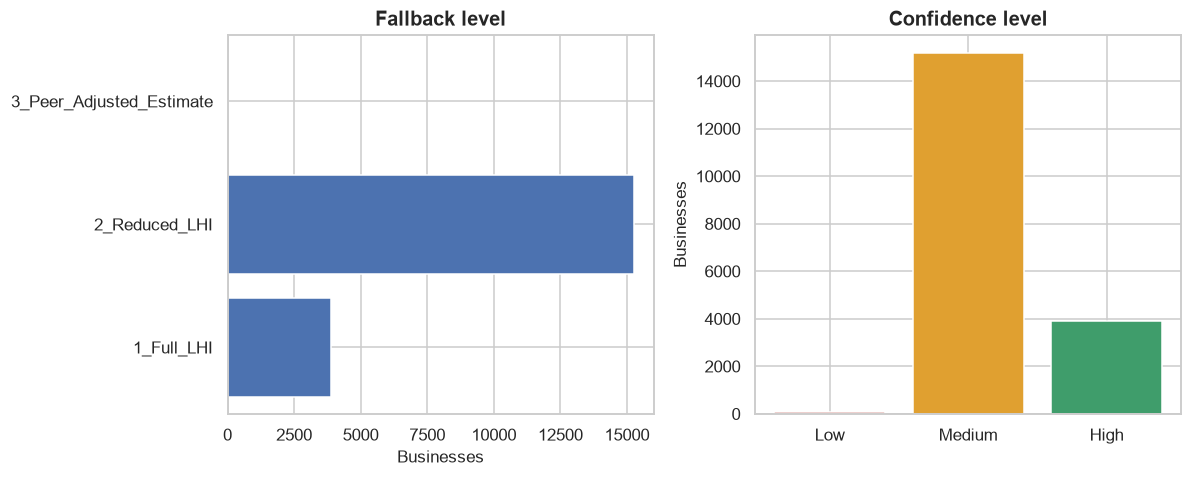

In [46]:
from lib.common import set_plot_theme
import matplotlib.pyplot as plt

set_plot_theme()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

fb_counts = fb['FALLBACK_LEVEL'].value_counts().sort_index()
axes[0].barh(fb_counts.index, fb_counts.values, color='#4C72B0')
axes[0].set_title('Fallback level')
axes[0].set_xlabel('Businesses')

conf_order = ['Low', 'Medium', 'High']
conf_counts = fb['LHI_CONFIDENCE'].value_counts().reindex(conf_order)
axes[1].bar(conf_counts.index, conf_counts.values, color=['#B23A2E', '#E0A030', '#3F9D6B'])
axes[1].set_title('Confidence level')
axes[1].set_ylabel('Businesses')

plt.tight_layout()
plt.show()

**Finding.** Most of the portfolio runs on partial evidence, not the full picture, by two closely related
but separately computed measures. By fallback level: 3,899 of 19,154 businesses reach Full LHI with every
pillar supported, 15,246 fall back to Reduced LHI, and 9 rely on a peer-adjusted estimate. By confidence
rating: 3,888 are rated High, 15,191 Medium, and 75 Low. The two measures agree for all but 11 businesses (a
Full LHI business rated only Medium confidence), which is worth stating plainly rather than rounding one
measure into the other. Neither is hidden behind one clean score. A reader can tell which locations are backed
by strong evidence and which ones need to be read more cautiously, which is the entire point of carrying
confidence as its own field instead of folding it into the LHI itself.

## 13. Final Export

The analytical dataset a Phase 2 dashboard would consume. Raw review text is deliberately **not** joined in.
It stays in `qsr_reviews_detail.parquet` and `QSR_ROOT_CAUSE_EVIDENCE.csv`, and is looked up on demand instead.

Four new columns beyond the original schema: `ORDER_ACCURACY_SENTIMENT` (the seventh aspect, alongside the
original six `*_SENTIMENT` columns), `RECENCY_WEIGHTED_STARS`, `EMERGING_ISSUE`, and
`OPERATIONAL_PROFILE_DAYS_WITH_HOURS`. The last two are reported exactly as Section 6 and Section 10's evidence
found them: separate signals, not folded into `LHI` or `TRAJECTORY`.

In [47]:
"""Stage 13 - Final export.

Assembles the analytical dataset a dashboard (Phase 2) would consume.
Raw review text stays in qsr_reviews_detail.parquet / QSR_ROOT_CAUSE_EVIDENCE
and is never joined into this table.

Two disclosed simplifications, stated here rather than silently:
  - LHI_CHANGE is a proxy from the rating-trajectory star delta, not a
    re-computed prior-period LHI (that would require rebuilding the whole
    pillar pipeline on a historical snapshot, out of scope for this pass).
  - TOP_NEGATIVE_THEME is reported at aspect granularity (e.g. "Waiting
    Time"), not fine-grained phrase mining ("long queues," "slow orders");
    QSR_ROOT_CAUSE_EVIDENCE.csv carries the raw snippets for manual reading.

EMERGING_ISSUE and OPERATIONAL_PROFILE_DAYS_WITH_HOURS are new: EMERGING_ISSUE
is the recent-negative-spike flag (stage 6), reported separately from
TRAJECTORY on purpose -- it answers a different question ("did something
break in the last 60 days") than the 12-month trend does, and folding the two
together would hide exactly the case it exists to catch.
OPERATIONAL_PROFILE_DAYS_WITH_HOURS is exported as context, not scored into
LHI -- stage 10's evidence gate found it predictive of the IS_OPEN proxy but
conceptually a listing-completeness signal, not a direct measurement of
outlet health (see QSR_OPERATIONAL_PROFILE_EVIDENCE_GATE.csv).
"""
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd

from lib.common import ROOT, OUTPUT_DIR, MODEL_VERSION, PIPELINE_RUN_DATE, require, log, risk_band


def main():
    fb = pd.read_csv(OUTPUT_DIR / "QSR_FALLBACK_CONFIDENCE.csv")
    biz = pd.read_csv(ROOT / "QSR_BUSINESS_ANALYSIS_READY.csv", low_memory=False)
    peer_bench = pd.read_csv(ROOT / "QSR_BUSINESS_PEER_BENCHMARKS.csv",
                              usecols=["BUSINESS_ID", "STAR_GAP_VS_PEERS", "PEER_RATING_PERCENTILE"])
    cx_aspect = pd.read_csv(OUTPUT_DIR / "QSR_CX_ASPECT_SCORES.csv")
    cx_pillar = pd.read_csv(OUTPUT_DIR / "QSR_CX_PILLAR.csv", usecols=["BUSINESS_ID", "TOTAL_ASPECT_MENTIONS"])
    trajectory = pd.read_csv(OUTPUT_DIR / "QSR_TRAJECTORY_FINAL.csv")

    aspect_pivot = cx_aspect.pivot_table(index="BUSINESS_ID", columns="ASPECT",
                                          values="ABSOLUTE_SCORE_0_100").reset_index()
    aspect_pivot = aspect_pivot.rename(columns={a: f"{a}_SENTIMENT" for a in aspect_pivot.columns if a != "BUSINESS_ID"})

    df = fb.merge(biz[["BUSINESS_ID", "BUSINESS_NAME", "CITY", "STATE"]], on="BUSINESS_ID", how="left") \
           .merge(peer_bench, on="BUSINESS_ID", how="left") \
           .merge(aspect_pivot, on="BUSINESS_ID", how="left") \
           .merge(trajectory[["BUSINESS_ID", "RECENT_REVIEW_COUNT", "PRIOR_REVIEW_COUNT"]], on="BUSINESS_ID", how="left") \
           .merge(cx_pillar, on="BUSINESS_ID", how="left")

    df["RISK_CATEGORY"] = risk_band(df["LHI_REPORTED"])
    df["LHI_CHANGE"] = df["RATING_DELTA"]
    df["TOP_NEGATIVE_THEME"] = df["TOP_NEGATIVE_ASPECT"]
    df["ABSA_EVIDENCE_COUNT"] = df["TOTAL_ASPECT_MENTIONS"]
    df["MODEL_VERSION"] = MODEL_VERSION
    df["PIPELINE_RUN_DATE"] = PIPELINE_RUN_DATE
    df["LHI"] = df["LHI_REPORTED"]
    df["LHI_VERSION"] = df["LHI_VERSION_SELECTED"]
    df["PILLAR_PERFORMANCE"] = df["PILLAR_PEER"]
    df["TRAJECTORY"] = df["RATING_TRAJECTORY"]
    df["TRAJECTORY_MAGNITUDE"] = df["RATING_DELTA"]

    final_cols = [
        "BUSINESS_ID", "BUSINESS_NAME", "CITY", "STATE",
        "PEER_TIER", "PEER_GROUP_SIZE",
        "LHI", "LHI_VERSION",
        "PILLAR_CX", "PILLAR_ENGAGEMENT", "PILLAR_PERFORMANCE", "PILLAR_MOMENTUM",
        "LHI_CHANGE", "TRAJECTORY", "TRAJECTORY_MAGNITUDE",
        "RISK_CATEGORY", "INTERVENTION_PRIORITY",
        "LHI_CONFIDENCE", "DATA_QUALITY_SCORE", "FALLBACK_LEVEL",
        "TOP_POSITIVE_DRIVER", "TOP_NEGATIVE_DRIVER",
        "TOP_NEGATIVE_ASPECT", "TOP_NEGATIVE_THEME",
        "FOOD_SENTIMENT", "SERVICE_SENTIMENT", "STAFF_SENTIMENT",
        "CLEANLINESS_SENTIMENT", "WAITING_TIME_SENTIMENT", "ORDER_ACCURACY_SENTIMENT", "VALUE_SENTIMENT",
        "PEER_RATING_PERCENTILE", "STAR_GAP_VS_PEERS",
        "RECENCY_WEIGHTED_STARS", "RECENT_MEAN_STARS", "PRIOR_MEAN_STARS", "EMERGING_ISSUE",
        "OPERATIONAL_PROFILE_DAYS_WITH_HOURS",
        "SHAP_TOP_DRIVER_1", "SHAP_TOP_DRIVER_2", "SHAP_TOP_DRIVER_3",
        "ABSA_EVIDENCE_COUNT", "RECENT_REVIEW_COUNT", "PRIOR_REVIEW_COUNT",
        "MODEL_VERSION", "PIPELINE_RUN_DATE",
    ]
    missing = [c for c in final_cols if c not in df.columns]
    require(not missing, f"Final export missing expected columns: {missing}")

    out = df[final_cols].rename(columns={"STAR_GAP_VS_PEERS": "STAR_GAP_TO_PEERS"})
    out.to_csv(OUTPUT_DIR / "QSR_FINAL_LHI_DATA.csv", index=False)

    log(f"Final export: {len(out)} rows x {len(out.columns)} columns -> QSR_FINAL_LHI_DATA.csv")
    log(f"Risk category distribution: {out['RISK_CATEGORY'].value_counts().to_dict()}")
    log(f"Intervention priority distribution: {out['INTERVENTION_PRIORITY'].value_counts().to_dict()}")

    check = out[(out["LHI"] >= 70) & (out["TRAJECTORY"] == "Deteriorating")]
    log(f"Verification: {len(check)} businesses with LHI>=70 but Deteriorating trajectory retained "
        f"in the export with their real intervention priority (not silently marked healthy).")

    log("Stage 13 complete. Pipeline finished.")


if __name__ == "__main__":
    main()

[23:38:49] Final export: 19154 rows x 46 columns -> QSR_FINAL_LHI_DATA.csv
[23:38:49] Risk category distribution: {'Watch': 6994, 'Healthy': 5586, 'High Risk': 4663, 'Critical Risk': 1911}
[23:38:49] Intervention priority distribution: {'Medium': 8518, 'High': 5168, 'Low': 4742, 'Critical': 726}
[23:38:49] Verification: 38 businesses with LHI>=70 but Deteriorating trajectory retained in the export with their real intervention priority (not silently marked healthy).
[23:38:49] Stage 13 complete. Pipeline finished.


In [48]:
final = pd.read_csv(f'{OUT}/QSR_FINAL_LHI_DATA.csv')
print(f"{len(final)} rows x {len(final.columns)} columns")
display(final['RISK_CATEGORY'].value_counts())
final.head(10)

19154 rows x 46 columns


RISK_CATEGORY
Watch            6994
Healthy          5586
High Risk        4663
Critical Risk    1911
Name: count, dtype: int64

,BUSINESS_ID,BUSINESS_NAME,CITY,STATE,PEER_TIER,PEER_GROUP_SIZE,LHI,LHI_VERSION,PILLAR_CX,PILLAR_ENGAGEMENT,PILLAR_PERFORMANCE,PILLAR_MOMENTUM,LHI_CHANGE,TRAJECTORY,TRAJECTORY_MAGNITUDE,RISK_CATEGORY,INTERVENTION_PRIORITY,LHI_CONFIDENCE,DATA_QUALITY_SCORE,FALLBACK_LEVEL,...,STAFF_SENTIMENT,CLEANLINESS_SENTIMENT,WAITING_TIME_SENTIMENT,ORDER_ACCURACY_SENTIMENT,VALUE_SENTIMENT,PEER_RATING_PERCENTILE,STAR_GAP_TO_PEERS,RECENCY_WEIGHTED_STARS,RECENT_MEAN_STARS,PRIOR_MEAN_STARS,EMERGING_ISSUE,OPERATIONAL_PROFILE_DAYS_WITH_HOURS,SHAP_TOP_DRIVER_1,SHAP_TOP_DRIVER_2,SHAP_TOP_DRIVER_3,ABSA_EVIDENCE_COUNT,RECENT_REVIEW_COUNT,PRIOR_REVIEW_COUNT,MODEL_VERSION,PIPELINE_RUN_DATE
0,pjbWU2dMUgPLfnLakIAivg,The River Room,Boise,ID,TIER_1_LOCAL_10MI,116,82.503833,LHI_3,80.506912,66.184609,97.434466,NaN,NaN,Insufficient Evidence,NaN,Healthy,Low,Medium,53.0,2_Reduced_LHI,...,69.261377,56.497149,65.569197,32.214551,65.381690,96.1,1.75,4.381627,NaN,NaN,NaN,7,TIPS_PER_LOADED_REVIEW,PRICE_RANGE,REVIEW_STAR_STDDEV,48.0,0,0,qsr-lhi-pipeline-v1,2026-09-04
1,By4ssT0VB02RMKPmxvDBWA,Saucy Dogs-Burgers-Tenders,Saint Charles,MO,TIER_1_LOCAL_10MI,85,68.184886,LHI_3,74.446429,40.604443,92.403504,64.109193,-0.05614,Stable,-0.05614,Healthy,Low,High,81.8,1_Full_LHI,...,65.871440,55.698984,62.366829,32.461631,64.954418,84.2,1.68,3.638107,3.733333,3.789474,NaN,7,TIPS_PER_LOADED_REVIEW,REVIEW_STAR_STDDEV,CHECKINS_PER_LOADED_REVIEW,114.0,30,19,qsr-lhi-pipeline-v1,2026-09-04
2,V6Jo2wrI3cEDi6zZ4-gK3Q,Buds Broiler,Chalmette,LA,TIER_1_LOCAL_10MI,128,45.637044,LHI_3,58.922559,42.431737,39.451122,NaN,NaN,Insufficient Evidence,NaN,Watch,Medium,Medium,47.3,2_Reduced_LHI,...,63.980975,59.868148,56.845451,41.523566,60.702684,35.5,-0.13,2.941454,NaN,NaN,NaN,6,PRICE_RANGE,DAYS_WITH_HOURS,AVG_REVIEWER_AVERAGE_STARS,30.0,0,0,qsr-lhi-pipeline-v1,2026-09-04
3,zcTJyMpHa3m9VXwTOAjmTg,Burger King,Burlington,NJ,TIER_1_LOCAL_10MI,70,21.992809,LHI_3,16.750948,39.495014,10.902212,NaN,NaN,Insufficient Evidence,NaN,Critical Risk,High,Medium,52.2,2_Reduced_LHI,...,54.961749,49.541915,49.285944,29.386241,61.462338,3.1,-0.94,1.873239,NaN,NaN,NaN,7,AVG_REVIEWER_AVERAGE_STARS,DAYS_WITH_HOURS,NEGATIVE_REVIEW_PERCENT,62.0,3,1,qsr-lhi-pipeline-v1,2026-09-04
4,g1qloNN1tpbp7Itry5CTdQ,Tom Sweenys Dutch Oven Cafe,Boise,ID,TIER_1_LOCAL_10MI,128,72.437900,LHI_3,74.239631,52.244309,88.064738,NaN,NaN,Insufficient Evidence,NaN,Healthy,Low,Medium,56.2,2_Reduced_LHI,...,69.616834,57.267999,58.515927,32.205617,66.733560,82.5,1.23,4.269269,NaN,NaN,NaN,6,DAYS_WITH_HOURS,AVG_REVIEWER_AVERAGE_STARS,REVIEW_STAR_STDDEV,72.0,0,0,qsr-lhi-pipeline-v1,2026-09-04
5,_BCkhyQAkn1G0xQEaRy5bg,Burger King,Willingboro,NJ,TIER_1_LOCAL_10MI,106,27.851137,LHI_3,17.920354,39.617051,24.666731,NaN,NaN,Insufficient Evidence,NaN,High Risk,High,Medium,47.2,2_Reduced_LHI,...,53.030154,48.638589,48.219328,31.118994,60.227374,19.1,-0.52,1.510483,NaN,NaN,NaN,7,AVG_REVIEWER_AVERAGE_STARS,DAYS_WITH_HOURS,AVG_REVIEW_STARS,21.0,4,0,qsr-lhi-pipeline-v1,2026-09-04
6,7pzSj4aTQYSmOr4NIuyTgQ,Jack in the Box,Saint Louis,MO,TIER_1_LOCAL_10MI,197,30.006059,LHI_3,15.964286,64.594210,10.543782,NaN,NaN,Insufficient Evidence,NaN,High Risk,High,Medium,55.1,2_Reduced_LHI,...,49.323050,51.156087,49.213400,32.045391,59.286404,3.5,-0.97,1.021512,NaN,NaN,NaN,7,AVG_REVIEWER_AVERAGE_STARS,AVG_REVIEW_STARS,NEGATIVE_REVIEW_PERCENT,101.0,4,3,qsr-lhi-pipeline-v1,2026-09-04
7,u8u4w4ilE2bDTciVUEBsjg,Rally's,Arnold,MO,TIER_1_LOCAL_10MI,85,31.298602,LHI_3,36.464286,52.834917,9.907883,NaN,NaN,Insufficient Evidence,NaN,High Risk,High,Medium,45.7,2_Reduced_LHI,...,56.593820,50.510165,54.949637,36.065711,57.297643,3.5,-1.01,1.076677,NaN,NaN,NaN,7,AVG_REVIEWER_AVERAGE_STARS,DAYS_WITH_HOURS,AVG_REVIEW_STARS,21.0,1,1,qsr-lhi-pipeline-v1,2026-09-04
8,B-SiesU4hxIiL7rl7vzayA,Jim's Steaks,Philadelphia,PA,TIER_1_LOCAL_10MI,214,80.170407,LHI_3,79.845447,71.521614,87.594374,NaN,NaN,Insufficient Evidence,NaN,Healthy,Low,Medium,60.5,2_Reduced_LHI,...,66.119065,57.752150,60.073296,35.753998,6

## Limitations (stated plainly, not buried)

- **No real outcome variable.** `IS_OPEN` is the only candidate target in the Yelp dataset, and it's a
  cross-sectional flag, not a closure history. Its predictive value is evidence about signal quality in the
  retained features, not proof that the LHI itself is correct.
- **ABSA is a transparent heuristic, not a contextual model.** Keyword and lexicon matching misreads some
  contrastive sentences. It's validated by convergent validity against star ratings, not a multi-annotator gold
  standard.
- **`LHI_CHANGE` is a proxy**, taken from the rating-trajectory star delta, not a re-computed prior-period LHI
  (that would require rebuilding the full pillar pipeline on a historical snapshot).
- **`TOP_NEGATIVE_THEME` is reported at aspect granularity**, not fine-grained phrase mining.
  `QSR_ROOT_CAUSE_EVIDENCE.csv` carries the raw snippets for manual reading in the meantime.
- **Historical, US-Yelp-only data** (cutoff 2022-01-19). No claim is made about current 2026 operating
  conditions, or about representativeness beyond the Yelp platform's own user base.
- **Momentum has no ML importance evidence.** Every candidate feature for it was excluded in the leakage gate
  itself, so LHI-2 and LHI-3's Momentum weight falls back to the business-rule value rather than being
  invented.
- **Order Accuracy is validated at the aggregate level, not the business-trend level.** It has 9,259 mentions,
  a monotonic relationship with stars, and statistical significance (Section 4). But 5,526 of the 5,529
  businesses with any Order Accuracy mentions have too few to support a recent-vs-prior trend (Section 6). The
  static score is real evidence. A per-business Order Accuracy trajectory mostly isn't computable yet.
- **The negative-spike detector has narrow coverage.** Only 650 of 19,154 businesses (3.4%) have enough review
  volume in both the 60-day recent window and the 365-day baseline to test at all, and 21 of those show a
  confirmed spike. It's correct where it applies, but it isn't a portfolio-wide early-warning system, given how
  sparse reviews are at Yelp's scale.
- **`OPERATIONAL_PROFILE_DAYS_WITH_HOURS` is disclosed context, not a scored signal, on purpose.** Section 10's
  evidence gate found it predictive of the `IS_OPEN` proxy, but conceptually it's a listing-completeness
  signal, not a direct measurement of operating-hours consistency, which this dataset simply cannot observe.
- **`HAS_TAKEOUT` and `HAS_DELIVERY` were deliberately not added to the LHI.** They plausibly describe business
  format (a format that never offers delivery isn't unhealthy for it) rather than health, and they weren't
  tested against a defensible hypothesis for what "delivery equals healthier" would even mean. Adding a feature
  without evidence is exactly the failure mode this rebuild exists to avoid.

## Next: Phase 2

This pipeline's output (`QSR_FINAL_LHI_DATA.csv`, `QSR_ROOT_CAUSE_EVIDENCE.csv`, `QSR_DRIVERS.csv`) feeds the
Phase 2 interactive dashboard, published separately as `QSR_Location_Health_Dashboard.html`: Executive
Overview, Location Ranking, Business Detail, Customer Voice, and Diagnosis, including the health-vs-trajectory
intervention-priority logic worked through in Section 11 above.
